<h1><center>MSc Data Science</center></h1>
<h1><center>DSM050 Data Visualisation - Final Coursework</center></h1>
<h1><center>Structure, Imbalance and Fleet Behaviour in the London Cycle Hire Network</center></h1>
<h2><center>Bulent Alptekin</center></h2>
<h3><center>August 2026</center></h3>

## Introduction

This study examines 17 months of London Cycle Hire journey records, approximately 12.5 million hires across 797 stations, as a spatio-temporal network rather than a set of independent stations.
- Demand is temporally rigid, with a stable weekday signature whose Friday deficit runs 30% below the Tuesday-to-Thursday core and does not narrow. 
- Imbalance is less severe than the rebalancing literature implies: 95.4% of stations reverse direction between the peaks, and the residual concentrates at a few high-turnover central sites that neither fleet composition nor elevation explains. 
- The network is dispersed rather than corridor-based, and structural position diverges from volume. 
- E-bike uptake falls with peripherality while range rises, so the electric fleet appears to extend catchment at the edge. 
- Unsupervised clustering on sixteen non-geographic features recovers four spatially coherent station archetypes.

## Research  topic

The five questions run from the network's behaviour in time, through its behaviour in space, to the roles individual stations play.

- **RQ1: What are the temporal patterns of demand across the window?** Demand structure sets the baseline against which every other question is read, and determines the period classification used throughout.
- **RQ2: Which stations accumulate or deplete cycles, and how large is the rebalancing burden?** Rebalancing is the dominant recurring cost, and Liu et al. (2016) exclude self-balancing stations from optimisation, so how many London stations qualify is an open empirical question.
- **RQ3: Which origin-destination pairs and stations are structurally central?** Volume identifies busy stations, not indispensable ones; the distinction determines which stations the network cannot afford to lose.
- **RQ4: How does e-bike usage differ from classic hire in reach, duration and adoption?** If the speed advantage is negligible (Waldner et al., 2025), the electric fleet must be delivering something else.
- **RQ5: Can stations be grouped into archetypes from demand, spatial and imbalance characteristics?** Testing whether the roles identified piecemeal in RQ2 to RQ4 emerge coherently without supervision.

## Data collection / Survey design

In [1]:
import os
import re
import time
import requests
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection

import geopandas as gpd
import contextily as cx
from shapely.geometry import Point
import networkx as nx
import plotly.graph_objects as go

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Data source endpoints
S3_BASE = "https://s3-eu-west-1.amazonaws.com/cycling.data.tfl.gov.uk/" # TfL open data S3 bucket
TFL_API = "https://api.tfl.gov.uk/BikePoint" # BikePoint station metadata API
NS = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"} # XML namespace for S3 list responses

# Local directory structure
RAW_DIR = Path("data/raw") # downloaded CSV extracts
CACHE_DIR = Path("data/cache") # per-file parquet, disposable
CLEAN_DIR = Path("data/clean") # analytical dataset, monthly partitions
REF_DIR = Path("data/reference") # crosswalk, ledgers, audits, lookups, any reference data
FIG_DIR = Path("figures")

for d in (RAW_DIR, CACHE_DIR, CLEAN_DIR, REF_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

import warnings
warnings.filterwarnings("ignore")

# Shared chart tokens
PALETTE = ["#87CEEB", "#4CA9DE", "#2478BE", "#1A5C96",
           "#4DAFB8", "#2E8E97", "#E8A838", "#F08080"]
SURFACE, INK, INK_SOFT, GRID = "#ffffff", "#0b0b0b", "#52514e", "#d8d7d2"

print("Libraries imported")
print(f"Directories ready: {RAW_DIR} | {CACHE_DIR} | {CLEAN_DIR} | {REF_DIR} | {FIG_DIR}")

Libraries imported
Directories ready: data/raw | data/cache | data/clean | data/reference | figures


In [2]:
# Basemap raster, fetched once
# The map figures each called a live tile service independently, which made
# them dependent on network availability and on the provider's terms at run time.
# The basemap is taken from Esri's WorldGrayCanvas and cached to a local GeoTIFF.
# Two extents are cached rather than one. The city-wide figures are drawn at
# roughly zoom 14, so a raster at that resolution matches their pixel density.
# The ego networks span only two to three kilometres, and reusing the wide
# raster there would enlarge it five- or sixfold, which renders as blur. A
# tighter box at higher zoom is fetched separately for those two figures.

def fetch_basemap(path, bounds, zoom, source=cx.providers.Esri.WorldGrayCanvas):
    """
    Fetch a basemap raster once and cache it to a local GeoTIFF.

    Parameters
    ----------
    path : Path
        Destination GeoTIFF. Skipped if it already exists.
    bounds : tuple of float
        (west, south, east, north) in WGS84 decimal degrees.
    zoom : int
        Tile zoom level. Each increment quadruples tile count and file size.
    source : xyzservices provider, optional
        Tile provider. Defaults to Esri WorldGrayCanvas, which needs no key.

    Returns
    -------
    Path
        The cached raster path, written in EPSG:3857.
    """
    if path.exists():
        print(f"cached  {path.name}  ({path.stat().st_size / 1e6:.1f} MB)")
        return path

    w, s, e, n = bounds
    print(f"fetching {path.name} at zoom {zoom} ...")
    img, _ = cx.bounds2raster(w, s, e, n, path=str(path),
                              source=source, zoom=zoom, ll=True)
    print(f"written  {path.name}  ({path.stat().st_size / 1e6:.1f} MB), "
          f"shape {img.shape}")
    return path


BASEMAP_WIDE = REF_DIR / "basemap_london_z14.tif"
BASEMAP_WATERLOO = REF_DIR / "basemap_waterloo_z16.tif"
BASEMAP_HYDEPARK = REF_DIR / "basemap_hydepark_z16.tif"

fetch_basemap(BASEMAP_WIDE, (-0.26, 51.44, 0.02, 51.57), zoom=14)
# Ego rasters are declared but not fetched yet. 

BASEMAP_ATTRIBUTION = "Basemap: Esri (C) OpenStreetMap"

fetching basemap_london_z14.tif at zoom 14 ...
written  basemap_london_z14.tif  (37.5 MB), shape (2816, 3328, 4)


In [3]:
# List all objects in the TfL open data S3 bucket

def list_tfl_bucket():
    """
    List all objects in the TfL open data S3 bucket.
    The bucket does not require authentication. 

    Returns
    -------
    pd.DataFrame
        Columns: 'key' (object path) and 'size_mb' (file size in megabytes).
    """
    all_files = []
    marker = ""

    while True:
        params = {"marker": marker} if marker else {}
        resp = requests.get(S3_BASE, params=params, timeout=30)
        resp.raise_for_status() # Raise immediately on HTTP errors (4xx/5xx)

        root = ET.fromstring(resp.content)
        contents = root.findall("s3:Contents", NS)

        if not contents: # Empty page signals end of bucket listing
            break

        for item in contents:
            all_files.append({
                "key": item.find("s3:Key",  NS).text,
                "size_mb": round(int(item.find("s3:Size", NS).text) / 1e6, 2),
            })

        is_trunc = root.find("s3:IsTruncated", NS)
        if is_trunc is not None and is_trunc.text.lower() == "true":
            marker = all_files[-1]["key"]
        else:
            break

    return pd.DataFrame(all_files)

print("Fetching bucket listing, this may take around 10 seconds ...")
bucket_df = list_tfl_bucket()
print(f"Found {len(bucket_df):,} objects in the bucket")
bucket_df.head()

Fetching bucket listing, this may take around 10 seconds ...
Found 793 objects in the bucket


,key,size_mb
0,ActiveTravelCountsProgramme/,0.0000
1,ActiveTravelCountsProgramme/0 Strategic active travel counts - release note.pdf,1.0100
2,ActiveTravelCountsProgramme/0.5 Strategic cycling estimates - methodology note.pdf,1.0700
3,ActiveTravelCountsProgramme/1 Monitoring locations.csv,0.2500
4,ActiveTravelCountsProgramme/2 Availability matrix.csv,0.2200


**S3 Bucket Catalogue**: The TfL open data bucket contains **793 objects** spread across multiple sub-directories. The usage-stats/ prefix, which holds the cycle hire journey extracts, will be filtered in the next step.

In [4]:
# Parse the real date range from every filename
FNAME_RE = re.compile(
    r"(\d+)JourneyDataExtract(\d{2}[A-Za-z]{3}\d{4})-(\d{2}[A-Za-z]{3}\d{4})\.csv$",
    flags=re.IGNORECASE,
)

journeys = bucket_df[
    bucket_df["key"].str.startswith("usage-stats/")
    & bucket_df["key"].str.lower().str.contains("journeydataextract")
    & bucket_df["key"].str.lower().str.endswith(".csv")
].copy()

journeys["filename"] = journeys["key"].str.split("/").str[-1]

# Extract start date and end date information
parsed = journeys["filename"].str.extract(FNAME_RE)
parsed.columns = ["extract_no", "start_raw", "end_raw"]

journeys["extract_no"] = pd.to_numeric(parsed["extract_no"], errors="coerce")
journeys["range_start"] = pd.to_datetime(parsed["start_raw"], format="%d%b%Y", errors="coerce")
journeys["range_end"] = pd.to_datetime(parsed["end_raw"], format="%d%b%Y", errors="coerce")

excluded_naming = journeys[journeys["range_start"].isna()]

print(f"Journey extracts found : {len(journeys):,}")
print(f"Excluded, non-conforming names: {len(excluded_naming):,} "
      f"(all pre-2019, outside any candidate window)")

# Retain only successfully parsed extracts, sorted chronologically
journeys = (journeys.dropna(subset=["range_start", "range_end"])
            .sort_values("range_start")
            .reset_index(drop=True))

print(f"Retained : {len(journeys):,}")
print(f"Coverage : {journeys['range_start'].min().date()} "
      f"to {journeys['range_end'].max().date()}")

Journey extracts found : 461
Excluded, non-conforming names: 32 (all pre-2019, outside any candidate window)
Retained : 429
Coverage : 2016-03-06 to 2026-05-31


**Extract Catalogue: Filename Parsing**: Of 461 journey extract files identified in the usage-stats/ prefix, 32 use non-conforming naming conventions predating 2019 and are excluded at this stage. The remaining 429 extracts are successfully parsed, yielding date ranges spanning March 2016 to May 2026. The analytical window will be derived from this catalogue in the following step.

In [5]:
# Let's audit the schema of every file in the bucket. 
# I will only read the first few bytes of each file to get the header row, 
# which is enough to detect schema changes. 
# This is much faster than downloading the entire file.

SCHEMA_CACHE = REF_DIR / "schema_audit.csv"

def peek_header(key, nbytes=4096, timeout=30):
    """
    Return only the header row of a remote CSV.
    An HTTP range request retrieves the first few kilobytes rather than the
    whole object, so auditing the full publication history costs megabytes
    rather than tens of gigabytes.

    Parameters
    ----------
    key : str
        S3 object key (relative path within the bucket).
    nbytes : int, optional
        Number of bytes to retrieve. Default 4096 is sufficient for any
        plausible CSV header row.
    timeout : int, optional
        HTTP request timeout in seconds.

    Returns
    -------
    str
        The first non-empty line of the file (i.e. the column header row),
        or an empty string if the file is blank.
    """
    resp = requests.get(S3_BASE + key,
                        headers={"Range": f"bytes=0-{nbytes - 1}"},
                        timeout=timeout)
    resp.raise_for_status()
    lines = resp.content.decode("utf-8-sig", errors="replace").splitlines()
    return lines[0].strip() if lines else ""


if SCHEMA_CACHE.exists():
    schema_audit = pd.read_csv(SCHEMA_CACHE, parse_dates=["range_start", "range_end"])
    print(f"Loaded cached schema audit: {len(schema_audit)} files")
else:
    rows, total = [], len(journeys)
    for n, (_, row) in enumerate(journeys.iterrows(), start=1):
        try:
            header, err = peek_header(row["key"]), None
        except Exception as exc:
            header, err = None, str(exc) # Capture errors without halting the audit

        rows.append({
            "filename": row["filename"],
            "extract_no": row["extract_no"],
            "range_start": row["range_start"],
            "range_end": row["range_end"],
            "header_raw": header,
            "error": err,
        })
        if n % 50 == 0 or n == total:
            print(f"  audited {n:>3}/{total}")

    schema_audit = pd.DataFrame(rows).sort_values("range_start").reset_index(drop=True)
    schema_audit.to_csv(SCHEMA_CACHE, index=False)
    print(f"\nCached to {SCHEMA_CACHE}")

print(f"Files audited: {len(schema_audit)}  |  failed reads: "
      f"{schema_audit['error'].notna().sum()}")

  audited  50/429
  audited 100/429
  audited 150/429
  audited 200/429
  audited 250/429
  audited 300/429
  audited 350/429
  audited 400/429
  audited 429/429

Cached to data/reference/schema_audit.csv
Files audited: 429  |  failed reads: 0


All 429 extracts were audited for schema consistency using HTTP Range requests, retrieving only the first 4 KB of each file rather than its full contents. Zero failed reads were recorded, confirming the bucket is fully accessible. Results are cached to disk so subsequent notebook runs do not incur additional network overhead.

In [6]:
# Reduce headers to structural signatures, so schema changes can be detected  
# I called schema changes "eras".

def canonical_signature(header_row):
    """
    Reduce a CSV header row to a canonical, comparable structural signature.

    Three sources of cosmetic variation are neutralised before comparison,
    none of which affects whether two files can be concatenated (pandas maps
    columns by name, not position):
      1. Trailing empty fields produced by stray commas in the header.
      2. Whitespace, underscores, and punctuation inside column names.
      3. Column ordering, signatures are sorted so reordering is not
         mistaken for a structural change.

    Parameters
    ----------
    header_row : str
        Raw header string as read from the CSV.

    Returns
    -------
    str
        Pipe-delimited, alphabetically sorted set of normalised field names.
    """
    cols = [re.sub(r"[^a-z0-9]", "", c.strip().strip('"').lower())
            for c in str(header_row).split(",")]
    cols = [c for c in cols if c]
    return " | ".join(sorted(set(cols)))

def ordered_signature(header_row):
    """
    Preserve column order, for the separate question of ordering stability.
    """
    cols = [re.sub(r"[^a-z0-9]", "", c.strip().strip('"').lower())
            for c in str(header_row).split(",")]
    return " | ".join(c for c in cols if c)

audit = schema_audit.dropna(subset=["header_raw"]).copy()
audit["signature_canonical"] = audit["header_raw"].apply(canonical_signature)
audit["signature_ordered"] = audit["header_raw"].apply(ordered_signature)
audit = audit.sort_values("range_start").reset_index(drop=True)

# Assign an era ID: increments each time the canonical signature changes
audit["era_id"] = (audit["signature_canonical"]
                   != audit["signature_canonical"].shift()).cumsum()

eras = (audit.groupby("era_id")
        .agg(first_file=("filename", "first"),
             last_file=("filename", "last"),
             n_files=("filename", "size"),
             era_start=("range_start", "min"),
             era_end=("range_end", "max"),
             signature=("signature_canonical", "first"))
        .reset_index())

eras["n_cols"] = eras["signature"].str.count(r"\|") + 1
eras["span_days"] = (eras["era_end"] - eras["era_start"]).dt.days

n_naive = audit["signature_ordered"].ne(audit["signature_ordered"].shift()).cumsum().max()
print(f"Structural eras: {len(eras)}")
for _, e in eras.iterrows():
    print(f"\nEra {e['era_id']}: {e['era_start'].date()} to {e['era_end'].date()} "
          f"({e['n_files']} files, {e['span_days']} days, {e['n_cols']} fields)")
    print(f"  {e['signature']}")

eras[["era_id", "era_start", "era_end", "n_files", "span_days", "n_cols"]]

Structural eras: 10

Era 1: 2016-03-06 to 2016-08-30 (18 files, 177 days, 9 fields)
  bikeid | duration | enddate | endstationid | endstationname | rentalid | startdate | startstationid | startstationname

Era 2: 2016-08-31 to 2016-09-06 (1 files, 6 days, 10 fields)
  bikeid | duration | enddate | endstationlogicalterminal | endstationname | endstationpriorityid | rentalid | startdate | startstationlogicalterminal | startstationname

Era 3: 2016-09-07 to 2017-08-29 (45 files, 356 days, 9 fields)
  bikeid | duration | enddate | endstationid | endstationname | rentalid | startdate | startstationid | startstationname

Era 4: 2017-08-30 to 2017-09-19 (3 files, 20 days, 9 fields)
  bikeid | durationseconds | enddate | endstationid | endstationname | rentalid | startdate | startstationid | startstationname

Era 5: 2017-09-20 to 2017-10-10 (3 files, 20 days, 9 fields)
  bikeid | duration | enddate | endstationid | endstationname | rentalid | startdate | startstationid | startstationname

Era 

,era_id,era_start,era_end,n_files,span_days,n_cols
0,1,2016-03-06,2016-08-30,18,177,9
1,2,2016-08-31,2016-09-06,1,6,10
2,3,2016-09-07,2017-08-29,45,356,9
3,4,2017-08-30,2017-09-19,3,20,9
4,5,2017-09-20,2017-10-10,3,20,9
5,6,2017-10-11,2017-10-31,3,20,9
6,7,2017-11-01,2022-07-05,235,1707,9
7,8,2022-07-06,2022-07-12,1,6,8
8,9,2022-07-13,2022-09-11,9,60,9
9,10,2022-09-12,2026-05-31,111,1357,11


The publication history contains **10 distinct schema eras**. Most transitions are brief anomalies of one to three files, likely caused by transient TfL data pipeline changes. The analytically critical transition is **Era 10 (from 12 September 2022)**, which introduced a redesigned 11-field schema with new column names (bikenumber, bikemodel, startstationnumber, etc.) and, crucially, the bikemodel field that distinguishes classic bikes from e-bikes. Any analytical window drawing on post-September 2022 data falls entirely within Era 10, so no cross-era harmonisation is required for the core analysis.

In [7]:
# Isolate the current (most recent) structural era for deeper inspection
current_era_id = eras["era_id"].iloc[-1]
current = audit[audit["era_id"] == current_era_id]


order_variants = (current.groupby("signature_ordered")
                  .agg(n_files=("filename", "size"),
                       first_seen=("range_start", "min"),
                       last_seen=("range_end", "max"))
                  .sort_values("first_seen")
                  .reset_index())

print(f"Current structural era spans {len(current)} files, "
      f"published in {len(order_variants)} distinct column orderings:\n")
for i, r in order_variants.iterrows():
    print(f"  Variant {i + 1}: {r['n_files']:>3} files, "
          f"{r['first_seen'].date()} to {r['last_seen'].date()}")

print("\nImplication: columns must be selected by name, never by position.")

Current structural era spans 111 files, published in 3 distinct column orderings:

  Variant 1: 100 files, 2022-09-12 to 2026-05-31
  Variant 2:   8 files, 2025-07-01 to 2025-11-30
  Variant 3:   3 files, 2025-07-16 to 2025-12-31

Implication: columns must be selected by name, never by position.


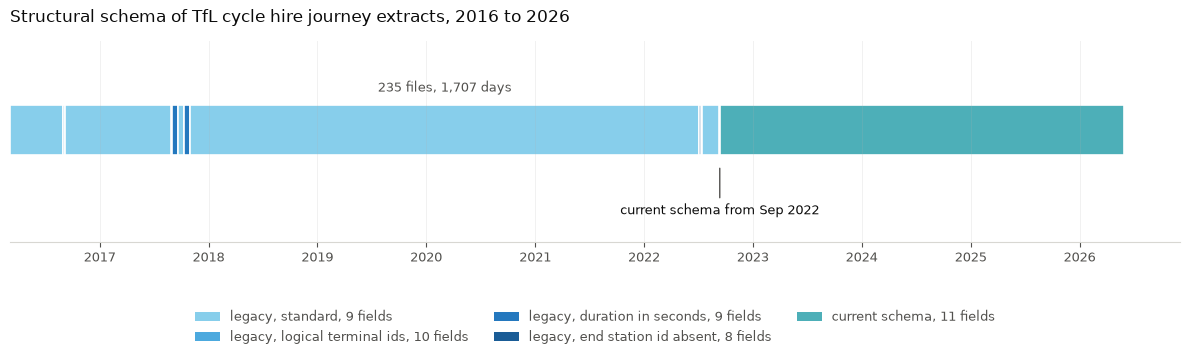

In [8]:
# Schema stability chart is my first figure in the report. 
# It shows the structural schema of TfL cycle hire journey extracts from 2016 to 2026, 
# highlighting different eras based on schema changes.

schema_order = eras.drop_duplicates("signature")["signature"].tolist()
schema_slot = {sig: i for i, sig in enumerate(schema_order)}

def short_label(sig):
    """
    Return a short label for a structural signature, to be used in the legend.

    Parameters
    ----------
    sig : str
        Pipe-delimited canonical signature as produced by `canonical_signature`.

    Returns
    -------
    str
        A short descriptive label suitable for a chart legend.
    """
    f = set(sig.split(" | "))
    n = len(f)
    if "totaldurationms" in f:
        return f"current schema, {n} fields"
    if "endstationlogicalterminal" in f:
        return f"legacy, logical terminal ids, {n} fields"
    if "durationseconds" in f:
        return f"legacy, duration in seconds, {n} fields"
    if "endstationid" not in f:
        return f"legacy, end station id absent, {n} fields"
    return f"legacy, standard, {n} fields"

fig, ax = plt.subplots(figsize=(12, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# Draw one horizontal bar per era
for _, e in eras.iterrows():
    ax.barh(y=0,
            width=max((e["era_end"] - e["era_start"]).days, 3),
            left=e["era_start"],
            height=0.42,
            color=PALETTE[schema_slot[e["signature"]] % len(PALETTE)],
            edgecolor=SURFACE,
            linewidth=1.2)

dominant = eras.loc[eras["span_days"].idxmax()]
ax.annotate(f"{dominant['n_files']} files, {dominant['span_days']:,} days",
            xy=(dominant["era_start"] + (dominant["era_end"] - dominant["era_start"]) / 2, 0.30),
            ha="center", va="bottom", fontsize=9, color=INK_SOFT)

latest = eras.iloc[-1]
ax.annotate(f"current schema from {latest['era_start'].strftime('%b %Y')}",
            xy=(latest["era_start"], -0.30),
            xytext=(latest["era_start"], -0.62),
            ha="center", va="top", fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="-", color=INK_SOFT, linewidth=1))

handles = [Patch(facecolor=PALETTE[schema_slot[s] % len(PALETTE)], label=short_label(s))
           for s in schema_order]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.28),
          ncol=min(3, len(handles)), frameon=False, fontsize=9, labelcolor=INK_SOFT)

ax.set_ylim(-0.95, 0.75)
ax.set_yticks([])
ax.set_title("Structural schema of TfL cycle hire journey extracts, 2016 to 2026",
             loc="left", fontsize=12, color=INK, pad=14)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(colors=INK_SOFT, labelsize=9)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.grid(axis="x", alpha=0.18, linewidth=0.7)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_schema_eras.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

In [9]:
# Sort Era 10 files chronologically and record the era's full date extent
era_files = current.sort_values("range_start").reset_index(drop=True)
era_start_dt, era_end_dt = era_files["range_start"].min(), era_files["range_end"].max()
print(f"Current era: {len(era_files)} files, "
      f"{era_start_dt.date()} to {era_end_dt.date()}")

gaps, overlaps = [], []
for i in range(len(era_files) - 1):
    cur, nxt = era_files.iloc[i], era_files.iloc[i + 1]
    if nxt["range_start"] > cur["range_end"] + pd.Timedelta(days=1):
        gaps.append({"gap_from": (cur["range_end"] + pd.Timedelta(days=1)).date(),
                     "gap_to": (nxt["range_start"] - pd.Timedelta(days=1)).date(),
                     "days": (nxt["range_start"] - cur["range_end"]).days - 1})
    elif nxt["range_start"] <= cur["range_end"]:
        overlaps.append({"file_a": cur["filename"],
                         "file_b": nxt["filename"],
                         "overlap_date": nxt["range_start"].date()})

print(f"\nCoverage gaps: {len(gaps)}")
if gaps:
    display(pd.DataFrame(gaps))
else:
    print("  none, daily coverage is continuous")

print(f"\nOverlapping pairs: {len(overlaps)}")
if overlaps:
    display(pd.DataFrame(overlaps))
    print("\nOverlaps imply duplicated journeys; deduplication on rental id is required.")

Current era: 111 files, 2022-09-12 to 2026-05-31

Coverage gaps: 0
  none, daily coverage is continuous

Overlapping pairs: 3


,file_a,file_b,overlap_date
0,419JourneyDataExtract01May2025-14May2025.csv,420JourneyDataExtract14May2025-31May2025.csv,2025-05-14
1,421JourneyDataExtract01Jun2025-15Jun2025.csv,422JourneyDataExtract15Jun2025-30Jun2025.csv,2025-06-15
2,439JourneyDataExtract01Mar2026-15Mar2026.csv,440JourneyDataExtract15Mar2026-31Mar2026.csv,2026-03-15



Overlaps imply duplicated journeys; deduplication on rental id is required.


In [10]:
# Decide the analytical window
# C1 Schema homogeneity: restrict to the current structural era
# C2 Temporal continuity: require unbroken daily coverage within it
# C3 Seasonal balance: begin on 1 January of the most recent fully covered calendar year, so all four seasons are represented
# C4 Complete months: end on the last day of the final complete calendar month, avoiding a truncated final period

if gaps:
    raise ValueError("Coverage gaps present; resolve before fixing the window.")

candidate_years = [y for y in range(era_start_dt.year, era_end_dt.year + 1)
                   if pd.Timestamp(f"{y}-01-01") >= era_start_dt
                   and pd.Timestamp(f"{y}-12-31") <= era_end_dt]
if not candidate_years:
    raise ValueError("No fully covered calendar year within the current era.")

start_year = max(candidate_years)
WINDOW_START = pd.Timestamp(f"{start_year}-01-01")

if era_end_dt == era_end_dt + pd.offsets.MonthEnd(0):
    last_complete = era_end_dt
else:
    last_complete = era_end_dt.replace(day=1) - pd.Timedelta(days=1)

# Reproducibility pin for the analytical window
# The derivation above is intentionally dynamic: it re-derives the window from
# whatever files are present in the S3 bucket at run time. If TfL publishes new
# extracts after submission, the derived WINDOW_END would advance, changing
# which files are downloaded and altering every downstream result.
# To guarantee reproducibility, WINDOW_END is pinned to the last complete month
# that was present when this analysis was conducted (31 May 2026). The
# derivation is kept above for transparency and to document how the date was
# originally chosen; the pin below ensures the window is fixed for any future
# reader running this notebook.
WINDOW_END = pd.Timestamp("2026-05-31 23:59:59")

n_months = ((WINDOW_END.year - WINDOW_START.year) * 12
            + (WINDOW_END.month - WINDOW_START.month) + 1)

print("DERIVATION OF THE ANALYTICAL WINDOW")
print(f"C1: Current structural era: {era_start_dt.date()} to {era_end_dt.date()}")
print(f"\t- Fields in this era: {eras['n_cols'].iloc[-1]}")
print(f"\t- Files in this era: {len(era_files)}")
print(f"C2: Coverage gaps: {len(gaps)}")
print(f"\t- Overlapping extract pairs: {len(overlaps)} (deduplication required)")
print(f"C3: Fully covered calendar years: {candidate_years}")
print(f"\t- Most recent of these: {start_year}")
print(f"C4: Last complete calendar month: {last_complete.strftime('%B %Y')}")

print(f"\nWINDOW_START = {WINDOW_START}")
print(f"WINDOW_END = {WINDOW_END}")
print(f"Duration = {n_months} months")

DERIVATION OF THE ANALYTICAL WINDOW
C1: Current structural era: 2022-09-12 to 2026-05-31
	- Fields in this era: 11
	- Files in this era: 111
C2: Coverage gaps: 0
	- Overlapping extract pairs: 3 (deduplication required)
C3: Fully covered calendar years: [2023, 2024, 2025]
	- Most recent of these: 2025
C4: Last complete calendar month: May 2026

WINDOW_START = 2025-01-01 00:00:00
WINDOW_END = 2026-05-31 23:59:59
Duration = 17 months


**Analytical Window: 1 January 2025 to 31 May 2026**: The window is derived from four explicit criteria rather than assumed. This yields **17 months** of data spanning January 2025 to May 2026.

**WINDOW_END** is subsequently pinned to 2026-05-31 as a hard constant. The derivation logic is preserved above for transparency, but the pin ensures that any future reader running this notebook after TfL has published additional extracts obtains the same analytical dataset as the original analysis.

In [11]:
# Select the extracts that fall within the analytical window, and reject the rest.

selected = (journeys[(journeys["range_end"] >= WINDOW_START)
                     & (journeys["range_start"] <= WINDOW_END)]
            .copy().sort_values("range_start").reset_index(drop=True))

rejected = journeys.loc[~journeys["filename"].isin(selected["filename"])]

print(f"Extracts available: {len(journeys):,}")
print(f"Extracts selected: {len(selected):,}")
print(f"Extracts excluded: {len(rejected):,}")
print(f"\nVolume selected: {selected['size_mb'].sum():,.0f} MB")
print(f"Volume excluded: {rejected['size_mb'].sum():,.0f} MB")
print(f"\nSelected span: {selected['range_start'].min().date()} "
      f"to {selected['range_end'].max().date()}")

selected[["extract_no", "filename", "range_start", "range_end", "size_mb"]]

Extracts available: 429
Extracts selected: 34
Extracts excluded: 395

Volume selected: 2,104 MB
Volume excluded: 11,390 MB

Selected span: 2025-01-01 to 2026-05-31


,extract_no,filename,range_start,range_end,size_mb
0,411.0000,411JourneyDataExtract01Jan2025-14Jan2025.csv,2025-01-01,2025-01-14,35.4900
1,412.0000,412JourneyDataExtract15Jan2025-31Jan2025.csv,2025-01-15,2025-01-31,58.9600
2,413.0000,413JourneyDataExtract01Feb2025-14Feb2025.csv,2025-02-01,2025-02-14,47.5200
3,414.0000,414JourneyDataExtract15Feb2025-28Feb2025.csv,2025-02-15,2025-02-28,48.0200
4,415.0000,415JourneyDataExtract01Mar2025-14Mar2025.csv,2025-03-01,2025-03-14,58.1900
5,416.0000,416JourneyDataExtract15Mar2025-31Mar2025.csv,2025-03-15,2025-03-31,70.8900
6,417.0000,417JourneyDataExtract01Apr2025-14Apr2025.csv,2025-04-01,2025-04-14,61.3400
7,418.0000,418JourneyDataExtract15Apr2025-30Apr2025.csv,2025-04-15,2025-04-30,65.5600
8,419.0000,419JourneyDataExtract01May2025-14May2025.csv,2025-05-01,2025-05-14,67.3800
9,420.0000,420JourneyDataExtract14May2025-31May2025.csv,2025-05-14,2025-05-31,76.0100


In [12]:
# Now that I have selected the extracts that fall within the analytical window, 
# I can proceed to download them. 
# The following function will handle the downloading of each file, 
# ensuring that it is done safely and efficiently.

def download_file(key, dest_dir=RAW_DIR, max_retries=3, chunk_size=1 << 20):
    """
    Stream one object to disk with resume-safe retries.
    The download is written to a .part file and renamed only on success, so an
    interrupted transfer can never be mistaken for a complete one on a rerun.

    Parameters
    ----------
    key : str
        S3 object key (relative path within the bucket).
    dest_dir : Path, optional
        Local directory in which to save the file. Defaults to RAW_DIR.
    max_retries : int, optional
        Number of download attempts before giving up. Uses exponential
        back-off (2^attempt seconds) between retries.
    chunk_size : int, optional
        Streaming chunk size in bytes. Default is 1 MiB (1 << 20).

    Returns
    -------
    tuple[Path | None, str]
        (destination path, status string) where status is one of
        'cached', 'downloaded', or 'failed: <reason>'.
    """
    fname = key.split("/")[-1]
    dest = Path(dest_dir) / fname
    part = dest.with_suffix(dest.suffix + ".part")

    if dest.exists() and dest.stat().st_size > 0:
        return dest, "cached"

    for attempt in range(1, max_retries + 1):
        try:
            with requests.get(S3_BASE + key, stream=True, timeout=120) as r:
                r.raise_for_status()
                expected = int(r.headers.get("Content-Length", 0))
                with open(part, "wb") as f:
                    for chunk in r.iter_content(chunk_size=chunk_size):
                        if chunk:
                            f.write(chunk)

            actual = part.stat().st_size
            if expected and actual != expected:
                raise IOError(f"size mismatch: expected {expected:,}, got {actual:,}")

            part.rename(dest)
            return dest, "downloaded"

        except Exception as exc:
            if part.exists():
                part.unlink()
            if attempt == max_retries:
                return None, f"failed: {exc}"
            time.sleep(2 ** attempt)

results, t0 = [], time.time()
for i, row in selected.iterrows():
    path, status = download_file(row["key"])
    results.append({"filename": row["filename"], "status": status})
    print(f"[{i + 1:2d}/{len(selected)}] {row['filename']:<52s} {status}")

download_log = pd.DataFrame(results)
print(f"\nCompleted in {time.time() - t0:.0f} seconds")
print(download_log["status"].value_counts())

[ 1/34] 411JourneyDataExtract01Jan2025-14Jan2025.csv         downloaded
[ 2/34] 412JourneyDataExtract15Jan2025-31Jan2025.csv         downloaded
[ 3/34] 413JourneyDataExtract01Feb2025-14Feb2025.csv         downloaded
[ 4/34] 414JourneyDataExtract15Feb2025-28Feb2025.csv         downloaded
[ 5/34] 415JourneyDataExtract01Mar2025-14Mar2025.csv         downloaded
[ 6/34] 416JourneyDataExtract15Mar2025-31Mar2025.csv         downloaded
[ 7/34] 417JourneyDataExtract01Apr2025-14Apr2025.csv         downloaded
[ 8/34] 418JourneyDataExtract15Apr2025-30Apr2025.csv         downloaded
[ 9/34] 419JourneyDataExtract01May2025-14May2025.csv         downloaded
[10/34] 420JourneyDataExtract14May2025-31May2025.csv         downloaded
[11/34] 421JourneyDataExtract01Jun2025-15Jun2025.csv         downloaded
[12/34] 422JourneyDataExtract15Jun2025-30Jun2025.csv         downloaded
[13/34] 423JourneyDataExtract01Jul2025-15Jul2025.csv         downloaded
[14/34] 424JourneyDataExtract16Jul2025-31Jul2025.csv         dow

In [13]:
# Validate the two duration columns before discarding one
def duration_text_to_seconds(text):
    """
    Parse TfL human-readable duration strings (e.g. '8d 4h 12m 3s') into
    total seconds.

    Long hires are expressed with a day or week component, so all five time
    units (weeks, days, hours, minutes, seconds) must be handled explicitly.
    Omitting the day/week component would silently truncate the longest
    journeys, precisely the records of interest when identifying unreturned
    or abandoned cycles.

    Parameters
    ----------
    text : str or float
        Duration string as it appears in the 'Total duration' column,
        or NaN for missing values.

    Returns
    -------
    float
        Total duration in seconds, or NaN if the input is missing.
    """
    if pd.isna(text):
        return np.nan
    units = {"w": 604800, "d": 86400, "h": 3600, "m": 60, "s": 1}
    total = 0
    for value, unit in re.findall(r"(\d+)\s*([wdhms])", str(text)):
        total += int(value) * units[unit]
    return total

# Load a 50,000-row sample from the first selected extract to inspect column
# names and validate the two duration representations against each other
sample = pd.read_csv(RAW_DIR / selected.iloc[0]["filename"], nrows=50000, low_memory=False)
print("Columns:", list(sample.columns))

chk = sample[["Total duration", "Total duration (ms)"]].dropna().head(5000).copy()
chk["from_text"] = chk["Total duration"].apply(duration_text_to_seconds)
chk["from_ms"] = chk["Total duration (ms)"] / 1000.0
chk["diff_s"] = (chk["from_text"] - chk["from_ms"]).abs()

print(f"\nAgreement check on {len(chk):,} rows")
print(f"\t- Maximum absolute difference: {chk['diff_s'].max():.2f} seconds")
print(f"\t- Rows differing by over 1s: {(chk['diff_s'] > 1).sum()}")
print("\nIf agreement holds, the text column is a formatted duplicate and may be dropped.")

Columns: ['Number', 'Start date', 'Start station number', 'Start station', 'End date', 'End station number', 'End station', 'Bike number', 'Bike model', 'Total duration', 'Total duration (ms)']

Agreement check on 5,000 rows
	- Maximum absolute difference: 1.00 seconds
	- Rows differing by over 1s: 0

If agreement holds, the text column is a formatted duplicate and may be dropped.


In [14]:
# In the same sample:
# Characterise the longest hires in this sample
hrs = sample["Total duration (ms)"] / 3600000
print(f"\nHires over 24 hours: {(hrs > 24).sum():,} of {len(sample):,} ({(hrs > 24).mean():.3%})")
print(f"Hires over 7 days: {(hrs > 168).sum():,} of {len(sample):,} ({(hrs > 168).mean():.3%})")
print(f"Hires under 1 minute: {(hrs * 60 < 1).sum():,} of {len(sample):,} ({(hrs * 60 < 1).mean():.3%})")

# Sub-minute hires are investigated rather than excluded wholesale.
# The station-match check distinguishes two distinct populations:
# (a) same-station returns: almost certainly a failed hire (dock check-out immediately followed by re-docking) with no real journey taking place.
# (b) different-station returns: physically plausible short transfers; these must be assessed against great-circle distance before any exclusion.
short = sample[hrs * 60 < 1]
same_station = (short["Start station number"] == short["End station number"]).sum()
print(f"\nSub-minute hires: {len(short):,}")
print(f" - starting and ending at the same station: {same_station:,} ({same_station / len(short):.1%})")
print(f" - at a different station: {len(short) - same_station:,}")


Hires over 24 hours: 19 of 50,000 (0.038%)
Hires over 7 days: 4 of 50,000 (0.008%)
Hires under 1 minute: 394 of 50,000 (0.788%)

Sub-minute hires: 394
 - starting and ending at the same station: 380 (96.4%)
 - at a different station: 14


- Long hires are rare: fewer than **0.04%** of records exceed 24 hours and only **0.008%** exceed 7 days, consistent with a small number of unreturned or stolen cycles rather than systematic data errors.

- Sub-minute hires account for **0.79%** of the sample and warrant closer inspection rather than blanket exclusion. Of these, **96.4% begin and end at the same station**, the hallmark of a failed hire where a cycle is undocked and immediately re-docked without a journey taking place. The remaining **3.6% (14 records)** involve different start and end stations and are physically plausible as very short transfers; these will be assessed against great-circle distance in the cleaning step before any exclusion decision is made.

In [15]:
# Load every extract with optimised dtypes

# Columns to retain by name
USE_COLS = ["Number", "Start date", "Start station number", "Start station",
            "End date", "End station number", "End station",
            "Bike number", "Bike model", "Total duration (ms)"]

RENAME = {"Number": "rental_id",
          "Start date": "start_time",
          "Start station number": "start_station_id",
          "Start station": "start_station_name",
          "End date": "end_time",
          "End station number": "end_station_id",
          "End station": "end_station_name",
          "Bike number": "bike_id",
          "Bike model": "bike_model",
          "Total duration (ms)": "duration_ms"}

INT32_COLS = ("rental_id", "bike_id", "start_station_id", "end_station_id")
INT64_COLS = ("duration_ms",) # Exceeds int32 ceiling (~24.9 days in ms)
CAT_COLS = ("start_station_name", "end_station_name", "bike_model")

def load_extract(path):
    """
    Read one Era 10 extract into a memory-optimised DataFrame.

    Columns are selected by name rather than position to guard against the
    three distinct column orderings present within Era 10. Identifier columns
    are cast to Int32 (nullable integer) and duration to Int64; station names
    and bike model are stored as categoricals, which reduces memory
    significantly given the small number of unique values relative to row count.
    Type coercion is silent (errors='coerce') so that malformed values become
    NaN rather than raising; nulls are audited after loading.

    Parameters
    ----------
    path : Path
        Absolute path to the raw CSV extract.

    Returns
    -------
    pd.DataFrame
        Memory-optimised frame with standardised column names and dtypes.
    """
    df = pd.read_csv(path, usecols=lambda c: c in USE_COLS, low_memory=False)
    df = df.rename(columns=RENAME)

    for col in ("start_time", "end_time"):
        df[col] = pd.to_datetime(df[col], errors="coerce")
    for col in INT32_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int32")
    for col in INT64_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    for col in CAT_COLS:
        df[col] = df[col].astype("category")

    return df

frames, profile = [], []
for i, row in selected.iterrows():
    src = RAW_DIR / row["filename"]
    cached = CACHE_DIR / (src.stem + ".parquet")

    if cached.exists():
        df = pd.read_parquet(cached) # Use cached parquet if available
    else:
        df = load_extract(src)
        df.to_parquet(cached, index=False)

    profile.append({"filename": row["filename"],
                    "rows": len(df),
                    "first_start": df["start_time"].min(),
                    "last_start": df["start_time"].max(),
                    "null_start_time": int(df["start_time"].isna().sum()),
                    "null_end_time": int(df["end_time"].isna().sum())})
    frames.append(df)
    print(f"[{i + 1:2d}/{len(selected)}] {row['filename']:<52s} {len(df):>9,} rows")

raw_journeys = pd.concat(frames, ignore_index=True)
del frames

file_profile = pd.DataFrame(profile)
print(f"\nCombined raw rows: {len(raw_journeys):,}")
print(f"Memory footprint : {raw_journeys.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# Type coercion is silent by design, so account for anything it discarded
print("\nNulls introduced by type coercion:")
for col in INT32_COLS + INT64_COLS + ("start_time", "end_time"):
    n = int(raw_journeys[col].isna().sum())
    print(f"  {col:<20} {n:>10,}")

file_profile

[ 1/34] 411JourneyDataExtract01Jan2025-14Jan2025.csv           213,400 rows
[ 2/34] 412JourneyDataExtract15Jan2025-31Jan2025.csv           354,634 rows
[ 3/34] 413JourneyDataExtract01Feb2025-14Feb2025.csv           285,681 rows
[ 4/34] 414JourneyDataExtract15Feb2025-28Feb2025.csv           288,603 rows
[ 5/34] 415JourneyDataExtract01Mar2025-14Mar2025.csv           349,388 rows
[ 6/34] 416JourneyDataExtract15Mar2025-31Mar2025.csv           425,739 rows
[ 7/34] 417JourneyDataExtract01Apr2025-14Apr2025.csv           368,361 rows
[ 8/34] 418JourneyDataExtract15Apr2025-30Apr2025.csv           393,071 rows
[ 9/34] 419JourneyDataExtract01May2025-14May2025.csv           404,002 rows
[10/34] 420JourneyDataExtract14May2025-31May2025.csv           455,584 rows
[11/34] 421JourneyDataExtract01Jun2025-15Jun2025.csv           397,655 rows
[12/34] 422JourneyDataExtract15Jun2025-30Jun2025.csv           460,783 rows
[13/34] 423JourneyDataExtract01Jul2025-15Jul2025.csv           455,095 rows
[14/34] 424J

,filename,rows,first_start,last_start,null_start_time,null_end_time
0,411JourneyDataExtract01Jan2025-14Jan2025.csv,213400,2025-01-01 00:00:00,2025-01-14 23:59:00,0,0
1,412JourneyDataExtract15Jan2025-31Jan2025.csv,354634,2025-01-15 00:01:00,2025-02-01 00:00:00,0,0
2,413JourneyDataExtract01Feb2025-14Feb2025.csv,285681,2025-02-01 00:00:00,2025-02-14 23:59:00,0,0
3,414JourneyDataExtract15Feb2025-28Feb2025.csv,288603,2025-02-15 00:00:00,2025-03-01 00:00:00,0,0
4,415JourneyDataExtract01Mar2025-14Mar2025.csv,349388,2025-03-01 00:00:00,2025-03-14 23:59:00,0,0
5,416JourneyDataExtract15Mar2025-31Mar2025.csv,425739,2025-03-15 00:00:00,2025-04-01 00:00:00,0,0
6,417JourneyDataExtract01Apr2025-14Apr2025.csv,368361,2025-04-01 00:00:00,2025-04-15 00:00:00,0,0
7,418JourneyDataExtract15Apr2025-30Apr2025.csv,393071,2025-04-15 00:00:00,2025-04-30 23:58:00,0,0
8,419JourneyDataExtract01May2025-14May2025.csv,404002,2025-05-01 00:00:00,2025-05-14 23:59:00,0,0
9,420JourneyDataExtract14May2025-31May2025.csv,455584,2025-05-15 00:00:00,2025-06-01 00:00:00,0,0


- 12.6 million raw journeys
- All 34 files loaded successfully into 1.47 GB of RAM, a reduction from the approx. 3.7 GB, achieved through Int32/Int64 identifiers and categorical string columns.
- The null audit reveals that end_station_id, duration_ms, and end_time each carry exactly **184 missing values**. These are spread across three non-consecutive extracts: files 421 and 422 (June 2025) and file 426 (August 2025). Two alternative explanations are plausible: the cycles were never returned (theft or abandonment), or a system fault failed to record the return event. Either way, these 184 records are missing critical journey attributes and will be excluded in the cleaning step.

In [16]:
# Data quality audit across the whole selected window
# Every figure here is computed over all 34 extracts, not a single sample,
# so that the values quoted in the report are representative.

INT32_MAX = 2147483647 # Upper bound of signed 32-bit integer
MS_PER_HOUR = 3600000
MS_PER_DAY = 86400000

# 1. Storage width: Confirms the Int64 choice for duration_ms
print("STORAGE WIDTH")
print(f" - Longest hire : {raw_journeys['duration_ms'].max():,} ms "
      f"({raw_journeys['duration_ms'].max() / MS_PER_DAY:.1f} days)")
print(f" - Rows exceeding int32 : "
      f"{(raw_journeys['duration_ms'] > INT32_MAX).sum():,}")
print(f" - Largest station id : {raw_journeys['start_station_id'].max():,}")

# 2. Station identifier conventions: IDs above 1M are retired stations
sid = pd.concat([raw_journeys["start_station_id"], raw_journeys["end_station_id"]])
bands = pd.cut(sid, bins=[0, 10000, 100000, 1000000, 1e12],
               labels=["under 10k", "10k to 100k", "100k to 1M", "above 1M"])
print("\nSTATION IDENTIFIER CONVENTIONS")
print(bands.value_counts().sort_index().to_string())

# 3. Retired docking stations: TfL marks retired stations by appending '_OLD' to the station name.
retired = (raw_journeys["start_station_name"].astype(str).str.endswith("_OLD")
           | raw_journeys["end_station_name"].astype(str).str.endswith("_OLD"))
mangled = raw_journeys["start_station_id"] > 1000000
print("\nRETIRED DOCKING STATIONS")
print(f" - Journeys touching one : {retired.sum():,} ({retired.mean():.3%})")
print(f" - Distinct names : "
      f"{raw_journeys.loc[retired, 'start_station_name'].astype(str).nunique():,}\n")
print(pd.crosstab(retired, mangled,
                  rownames=["name ends _OLD"], colnames=["id above 1M"]).to_string())

# 4. Implausible durations
dur_h = raw_journeys["duration_ms"] / MS_PER_HOUR
print("\nIMPLAUSIBLE DURATIONS")
print(f" - Under 1 minute : {(dur_h * 60 < 1).sum():,} ({(dur_h * 60 < 1).mean():.3%})")
print(f" - Over 24 hours : {(dur_h > 24).sum():,} ({(dur_h > 24).mean():.3%})")
print(f" - Over 7 days : {(dur_h > 168).sum():,} ({(dur_h > 168).mean():.3%})")

# 5. Failed hires
short = raw_journeys[raw_journeys["duration_ms"] < 60000]
same = int((short["start_station_id"] == short["end_station_id"]).sum())
print("\nFAILED HIRES")
print(f" - Sub-minute hires : {len(short):,} ({len(short) / len(raw_journeys):.3%})")
print(f" - Returned to origin dock : {same:,} ({same / len(short):.1%})")
print(f" - Ended elsewhere : {len(short) - same:,} ({(len(short) - same) / len(short):.1%})")

# 6. Temporal integrity
print("\nTEMPORAL INTEGRITY")
print(f" - End before start : {(raw_journeys['end_time'] < raw_journeys['start_time']).sum():,}")
print(f" - Null start time : {raw_journeys['start_time'].isna().sum():,}")
print(f" - Null end time : {raw_journeys['end_time'].isna().sum():,}")

# 7. Fleet composition
print("\nFLEET COMPOSITION")
print(raw_journeys["bike_model"].value_counts(dropna=False).to_string())

STORAGE WIDTH
 - Longest hire : 18,086,112,839 ms (209.3 days)
 - Rows exceeding int32 : 317
 - Largest station id : 2,001,454,444

STATION IDENTIFIER CONVENTIONS
under 10k      13788797
10k to 100k      953077
100k to 1M     10437812
above 1M          83144

RETIRED DOCKING STATIONS
 - Journeys touching one : 85,593 (0.678%)
 - Distinct names : 821

id above 1M        False  True 
name ends _OLD                 
False           12545914      0
True               43945  41648

IMPLAUSIBLE DURATIONS
 - Under 1 minute : 99,132 (0.785%)
 - Over 24 hours : 8,020 (0.063%)
 - Over 7 days : 1,874 (0.015%)

FAILED HIRES
 - Sub-minute hires : 99,132 (0.785%)
 - Returned to origin dock : 95,753 (96.6%)
 - Ended elsewhere : 3,379 (3.4%)

TEMPORAL INTEGRITY
 - End before start : 66
 - Null start time : 0
 - Null end time : 184

FLEET COMPOSITION
bike_model
CLASSIC       10305828
PBSC_EBIKE     2325679


- **Storage decisions confirmed:** The longest hire is 209.3 days and 317 rows exceed the Int32 ceiling, validating the Int64 choice for `duration_ms`.
- **Retired stations:** TfL marks decommissioned docking stations by appending "_OLD" to the station name. The crosstab reveals two sub-populations: 43,945 journeys carry an "_OLD" name but a normal-range ID, while 41,648 carry both an "_OLD" name and a mangled ID above 1 million.
- **Implausible durations:** Sub-minute hires account for 0.785% of records, of which 96.6% return to the origin dock, consistent with the sample finding. The remaining 3.4% (3,379 records) end at a different station and will be assessed by great-circle distance before any exclusion. Hires over 24 hours are rare (0.063%), with only 1,874 exceeding 7 days.
- **Temporal integrity:** 66 records have an end time preceding the start time, likely reflecting system clock errors, and will be excluded.
- **Fleet composition:** Classic bikes account for **81.6%** of hires (10,305,828) and e-bikes for **18.4%** (2,325,679), providing sufficient volume in both categories for the comparative analysis in RQ4.

In [17]:
# Deduplicate and clip to the derived window
before = len(raw_journeys)

# Three pairs of extracts publish overlapping date ranges, so the boundary day
# is present in both files. The rental identifier is unique per hire.
dup_mask = raw_journeys.duplicated(subset="rental_id", keep="first")
dup_dates = raw_journeys.loc[dup_mask, "start_time"].dt.date.value_counts().sort_index()

raw_journeys = raw_journeys[~dup_mask]
after_dedup = len(raw_journeys)

raw_journeys = raw_journeys[raw_journeys["start_time"].between(WINDOW_START, WINDOW_END)]
after_clip = len(raw_journeys)

print(f"Rows before deduplication: {before:,}")
print(f"Duplicates removed: {before - after_dedup:,} "
      f"({(before - after_dedup) / before:.3%})")
print(f"Rows outside the window: {after_dedup - after_clip:,}")
print(f"Final row count: {after_clip:,}")
print(f"\nDate range: {raw_journeys['start_time'].min()} to {raw_journeys['start_time'].max()}")

# Duplicates should fall only on the three known overlap dates
print("\nDates on which duplicates occurred:")
print(dup_dates.to_string())

Rows before deduplication: 12,631,507
Duplicates removed: 0 (0.000%)
Rows outside the window: 3
Final row count: 12,631,504

Date range: 2025-01-01 00:00:00 to 2026-05-31 23:59:00

Dates on which duplicates occurred:
Series([], )


In [18]:
total_ids = len(raw_journeys)
unique_ids = raw_journeys["rental_id"].nunique()
print(f"Total rows: {total_ids:,}")
print(f"Unique rental IDs: {unique_ids:,}")
print(f"Difference: {total_ids - unique_ids:,}")

Total rows: 12,631,504
Unique rental IDs: 12,631,504
Difference: 0


In [19]:
# Load each file pair and look for shared rental IDs on the boundary date
overlap_pairs = [
    ("419JourneyDataExtract01May2025-14May2025.csv",
     "420JourneyDataExtract14May2025-31May2025.csv", "2025-05-14"),
    ("421JourneyDataExtract01Jun2025-15Jun2025.csv",
     "422JourneyDataExtract15Jun2025-30Jun2025.csv", "2025-06-15"),
    ("439JourneyDataExtract01Mar2026-15Mar2026.csv",
     "440JourneyDataExtract15Mar2026-31Mar2026.csv", "2026-03-15"),
]

for file_a, file_b, boundary in overlap_pairs:
    df_a = pd.read_parquet(CACHE_DIR / (file_a.replace(".csv", ".parquet")))
    df_b = pd.read_parquet(CACHE_DIR / (file_b.replace(".csv", ".parquet")))
    ids_a = set(df_a[df_a["start_time"].dt.date.astype(str) == boundary]["rental_id"])
    ids_b = set(df_b[df_b["start_time"].dt.date.astype(str) == boundary]["rental_id"])
    shared = ids_a & ids_b
    print(f"Boundary {boundary}: {len(ids_a)} in file A, {len(ids_b)} in file B, "
          f"{len(shared)} shared rental IDs")

Boundary 2025-05-14: 33727 in file A, 0 in file B, 0 shared rental IDs
Boundary 2025-06-15: 23693 in file A, 0 in file B, 0 shared rental IDs
Boundary 2026-03-15: 14673 in file A, 0 in file B, 0 shared rental IDs


Rental IDs are **globally unique** across all 34 extracts: 12,631,504 rows contain 12,631,504 distinct rental IDs, with zero duplicates. The direct cross-check of the three filename-overlapping file pairs confirms why: on every boundary date, all records appear exclusively in file A with zero records in file B. TfL's naming convention is therefore misleading, the end date in a filename is inclusive in the label but exclusive in the actual data, so consecutive files partition records cleanly without overlap.

Three records whose start time fell marginally outside the analytical window were removed by the window clip, leaving a final dataset of **12,631,504journeys** spanning 1 January 2025 to 31 May 2026.

In [20]:
# Check for 3 records why they fall outside the analytical window
spill = pd.concat([pd.read_parquet(p) for p in
                   [CACHE_DIR / "444JourneyDataExtract17May2026-31May2026.parquet"]])
outside = spill[spill["start_time"] > WINDOW_END]
print(f"Records beyond the window in the final extract: {len(outside)}")
display(outside[["rental_id", "start_time", "end_time",
                 "start_station_name", "end_station_name", "duration_ms"]])

Records beyond the window in the final extract: 3


,rental_id,start_time,end_time,start_station_name,end_station_name,duration_ms
3,158448281,2026-06-01,2026-06-01 00:23:00,"Wright's Lane, Kensington","Vincent Street, Pimlico",1381485
6,158448284,2026-06-01,2026-06-01 00:16:00,"Belgrave Square, Belgravia","Riverlight North, Nine Elms",988430
7,158448285,2026-06-01,2026-06-01 00:19:00,"Aylward Street, Stepney","Regent's Row , Haggerston",1161999


All three clipped records are legitimate journeys that started at midnight on **1 June 2026** and appear in the final extract file despite its stated range ending on 31 May.

### Station reference data

Station coordinates, names and capacities come from the TfL Unified API BikePoint endpoint, retrieved on **15 August 2026** and supplied with this notebook as `data/reference/stations_bikepoint.csv`.

The endpoint returns the *live* network rather than a historical snapshot, so its contents change as stations are commissioned, renamed and decommissioned. Re-fetching at a later date returns a different set of stations, which would alter the crosswalk, the count of resolvable stations, and every station-level result downstream, including the clustering in RQ5. The snapshot is therefore pinned rather than retrieved, for the same reason `WINDOW_END` is pinned.

The code below produced that file and is retained for transparency. It is not executed.

```python
            # Retrieve station metadata from the TfL Unified API

            WANTED_PROPS = {"NbDocks", "TerminalName", "Installed", "Locked",
                            "InstallDate", "RemovalDate", "Temporary"}

            print("Fetching station metadata ...")
            resp = requests.get(TFL_API, timeout=60)
            resp.raise_for_status()
            raw_stations = resp.json()

            records = []
            for s in raw_stations:
                props = {p["key"]: p.get("value")
                        for p in s.get("additionalProperties", [])
                        if p.get("key") in WANTED_PROPS}
                records.append({
                    "bikepoint_id" : s.get("id", "").replace("BikePoints_", ""),
                    "terminal_name" : props.get("TerminalName"),
                    "station_name" : s.get("commonName"),
                    "lat" : s.get("lat"),
                    "lon" : s.get("lon"),
                    "capacity" : pd.to_numeric(props.get("NbDocks"), errors="coerce"),
                    "installed" : props.get("Installed"),
                    "locked" : props.get("Locked"),
                    "temporary" : props.get("Temporary"),
                })

            stations_df = pd.DataFrame(records)

            # bikepoint_id: sequential internal API identifier (1-890); does NOT match
            # the station IDs in the journey data
            stations_df["bikepoint_id"] = pd.to_numeric(stations_df["bikepoint_id"],
                                                        errors="coerce").astype("Int64")

            # terminal_num: numeric value of TerminalName; this is the field that matches
            # start_station_id / end_station_id in the journey data
            stations_df["terminal_num"] = pd.to_numeric(stations_df["terminal_name"],
                                                        errors="coerce").astype("Int64")
            stations_df.to_csv(REF_DIR / "stations_bikepoint.csv", index=False)

            print(f"Stations retrieved: {len(stations_df)}")
            print(f"Missing coordinates: {stations_df[['lat', 'lon']].isna().any(axis=1).sum()}")
            print(f"\nbikepoint_id range: {stations_df['bikepoint_id'].min()} "
                f"to {stations_df['bikepoint_id'].max()}")
            print(f"terminal_num range: {stations_df['terminal_num'].min()} "
                f"to {stations_df['terminal_num'].max()}")
            stations_df.head()
```

In [21]:
STATIONS_CACHE = REF_DIR / "stations_bikepoint.csv"

if not STATIONS_CACHE.exists():
    raise FileNotFoundError(
        f"{STATIONS_CACHE} is required and is supplied with this notebook. "
        "The BikePoint endpoint returns the live network, so re-fetching would "
        "return a different set of stations and change every station-level "
        "result. The snapshot is provided rather than retrieved."
    )

stations_df = pd.read_csv(STATIONS_CACHE)
for col in ("bikepoint_id", "terminal_num"):
    stations_df[col] = pd.to_numeric(stations_df[col],
                                     errors="coerce").astype("Int64")

print(f"Stations retrieved: {len(stations_df)}")
print(f"Missing coordinates: {stations_df[['lat', 'lon']].isna().any(axis=1).sum()}")
print(f"\nbikepoint_id range: {stations_df['bikepoint_id'].min()} "
      f"to {stations_df['bikepoint_id'].max()}")
print(f"terminal_num range: {stations_df['terminal_num'].min()} "
      f"to {stations_df['terminal_num'].max()}")
stations_df.head()

Stations retrieved: 799
Missing coordinates: 0

bikepoint_id range: 1 to 890
terminal_num range: 959 to 300253


,bikepoint_id,terminal_name,station_name,lat,lon,capacity,installed,locked,temporary,terminal_num
0,1,1023,"River Street , Clerkenwell",51.5292,-0.1100,19,True,False,False,1023
1,2,1018,"Phillimore Gardens, Kensington",51.4996,-0.1976,37,True,False,False,1018
2,3,1012,"Christopher Street, Liverpool Street",51.5213,-0.0846,32,True,False,False,1012
3,4,1013,"St. Chad's Street, King's Cross",51.5301,-0.1210,23,True,False,False,1013
4,5,3420,"Sedding Street, Sloane Square",51.4931,-0.1569,27,True,False,False,3420


**799 stations** were retrieved from the TfL Unified API with complete coordinates for all records (API Access date:15/08/2026).

In [22]:
# Build the full set of distinct station IDs appearing in the journey data
# (both start and end endpoints combined)
journey_ids = pd.Index(pd.unique(
    pd.concat([raw_journeys["start_station_id"],
               raw_journeys["end_station_id"]]).dropna()
)).astype("int64")

api_ids = set(stations_df["bikepoint_id"].dropna().astype("int64"))
api_terminals = set(stations_df["terminal_num"].dropna().astype("int64"))

# Segment journey station IDs into the four addressing conventions identified in the data quality audit
CONVENTIONS = {
    "under 10k": lambda i: i < 10000,
    "10k to 100k": lambda i: 10000 <= i < 100000,
    "100k to 1M": lambda i: 100000 <= i < 1000000,
    "above 1M": lambda i: i >= 1000000,
}

vol = pd.concat([raw_journeys["start_station_id"],
                 raw_journeys["end_station_id"]]).value_counts(dropna=True)
total_vol = vol.sum()

rows = []
for label, test in CONVENTIONS.items():
    ids = {int(i) for i in journey_ids if test(int(i))}
    if not ids:
        continue
    v = vol[[i for i in vol.index if test(int(i))]].sum()
    rows.append({
        "convention": label,
        "stations": len(ids),
        "journey_ends": v,
        "share": f"{v / total_vol:.1%}",
        "match_bikepoint_id": f"{len(ids & api_ids)} ({len(ids & api_ids) / len(ids):.0%})",
        "match_terminal_num": f"{len(ids & api_terminals)} ({len(ids & api_terminals) / len(ids):.0%})",
    })

print(f"Distinct station ids in journeys: {len(journey_ids):,}")
print(f"Stations in the BikePoint API: {len(api_ids):,}\n")
display(pd.DataFrame(rows))

# Name matching, as a fallback or cross-check
def norm(s):
    """
    Normalise a station name for string-based matching.

    Applied as a fallback and cross-check independent of numeric ID matching.
    Four transformations are applied in sequence:
      1. Remove the '_OLD' retired-station suffix.
      2. Lowercase.
      3. Strip non-alphanumeric characters (punctuation, apostrophes, etc.).
      4. Collapse runs of whitespace to a single space and strip leading/trailing.
    """
    return (s.astype(str)
            .str.replace(r"_OLD$", "", regex=True)
            .str.lower()
            .str.replace(r"[^a-z0-9 ]", "", regex=True)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip())

jn = set(norm(pd.Series(raw_journeys["start_station_name"].astype(str).unique())))
an = set(norm(stations_df["station_name"]))

print(f"\nDistinct station names in journeys: {len(jn):,}")
print(f"Distinct station names in the API: {len(an):,}")
print(f"Exact matches after normalisation: {len(jn & an):,} "
      f"({len(jn & an) / len(jn):.1%})")
print(f"\nUnmatched journey station names (first 20):")
for n in sorted(jn - an)[:20]:
    print(f" - {n}")

Distinct station ids in journeys: 824
Stations in the BikePoint API: 799



,convention,stations,journey_ends,share,match_bikepoint_id,match_terminal_num
0,under 10k,383,13788794,54.6%,0 (0%),379 (99%)
1,10k to 100k,36,953076,3.8%,0 (0%),32 (89%)
2,100k to 1M,388,10437810,41.3%,0 (0%),386 (99%)
3,above 1M,17,83144,0.3%,0 (0%),0 (0%)



Distinct station names in journeys: 807
Distinct station names in the API: 799
Exact matches after normalisation: 795 (98.5%)

Unmatched journey station names (first 20):
 - camley street camden town
 - earnshaw street covent garden
 - edgware road station marylebone
 - guildhouse street victoria
 - harriet street knightsbridge
 - hoxton street hoxton
 - king edward walk waterloo
 - marylebone lane marylebone
 - regency street westminster
 - riverlight south nine elms
 - southwark station 2 southwark
 - st martins street west end


Joining on bikepoint_id matches **0%** of records across all four ID conventions, confirming it is the wrong key. Joining on terminal_num matches **99%** of the two dominant conventions ("under 10k" and "100k to 1M"), which together account for **95.9%** of all journey endpoints. The "10k to 100k" group achieves 89% (4 stations unmatched), and the 17 "above 1M" retired stations match 0% as expected, they are decommissioned and absent from the live API.

The name-based cross-check yields **98.5% exact matches** after normalisation. The 12 unmatched names correspond to stations that were active during the analytical window but have since been renamed or removed from the live API; they represent a small volume of journeys that cannot be spatially located and will be flagged as unmappable rather than excluded from the analysis entirely.

Overall, **terminal_num** is the correct and sufficient join key, covering approximately 99.7% of journey endpoints by volume.

In [23]:
# Build the station crosswalk and measure coverage
# The BikePoint API describes the live network, so stations decommissioned
# during the window are absent. Resolution proceeds in two passes: first on
# the terminal identifier, then on the normalised station name, which also
# recovers retired stations because the normaliser strips the _OLD suffix.

stations_df["name_norm"] = norm(stations_df["station_name"])

by_id = (stations_df.dropna(subset=["terminal_num"])
         .drop_duplicates("terminal_num")
         .set_index("terminal_num")[["station_name", "lat", "lon", "capacity"]])

by_name = (stations_df.drop_duplicates("name_norm")
           .set_index("name_norm")[["station_name", "lat", "lon", "capacity"]])

# Station inventory as observed in the journey data, weighted by usage
s = (raw_journeys[["start_station_id", "start_station_name"]]
     .value_counts().rename_axis(["station_id", "station_name"]).rename("n"))
e = (raw_journeys[["end_station_id", "end_station_name"]]
     .value_counts().rename_axis(["station_id", "station_name"]).rename("n"))

inv = (s.add(e, fill_value=0).reset_index().rename(columns={"n": "journey_ends"}))
inv["journey_ends"] = inv["journey_ends"].astype("int64")
inv["name_norm"] = norm(inv["station_name"])
inv["is_retired"] = inv["station_name"].astype(str).str.endswith("_OLD")

# Pass 1: terminal identifier
inv["matched_by"] = pd.NA
hit_id = inv["station_id"].isin(by_id.index)
inv.loc[hit_id, "matched_by"] = "terminal_id"

# Pass 2: normalised name
hit_name = ~hit_id & inv["name_norm"].isin(by_name.index)
inv.loc[hit_name, "matched_by"] = "station_name"

total = inv["journey_ends"].sum()
print("STATION RESOLUTION")
print(f" - Distinct stations in journeys: {len(inv):,}")
print(f" - Total journey ends: {total:,}\n")

summary = (inv.groupby(inv["matched_by"].fillna("unmatched"))
           .agg(stations=("station_id", "size"),
                journey_ends=("journey_ends", "sum")))
summary["share"] = (summary["journey_ends"] / total).map("{:.3%}".format)
print(summary.to_string())

# Did the name pass recover the retired stations?
rec = inv[inv["is_retired"] & (inv["matched_by"] == "station_name")]
print(f"\nRetired stations recovered by name: {len(rec)} "
      f"({rec['journey_ends'].sum():,} journey ends)")

# What remains unresolvable, and does it matter?
lost = inv[inv["matched_by"].isna()].sort_values("journey_ends", ascending=False)
print(f"\nUnresolvable stations: {len(lost)} "
      f"({lost['journey_ends'].sum():,} journey ends, "
      f"{lost['journey_ends'].sum() / total:.3%})")
display(lost[["station_id", "station_name", "journey_ends", "is_retired"]].head(30))

STATION RESOLUTION
 - Distinct stations in journeys: 828
 - Total journey ends: 25,262,824

              stations  journey_ends    share
matched_by                                   
station_name        17         83144   0.329%
terminal_id        801      24966130  98.826%
unmatched           10        213550   0.845%

Retired stations recovered by name: 17 (83,144 journey ends)

Unresolvable stations: 10 (213,550 journey ends, 0.845%)


,station_id,station_name,journey_ends,is_retired
400,22163,"Southwark Station 2, Southwark",42246,False
188,1152,"Marylebone Lane, Marylebone",37897,False
191,1155,"Regency Street, Westminster",31488,False
194,1158,"St. Martin's Street, West End",25099,False
356,3478,"Guildhouse Street, Victoria",22851,False
790,300232,"Riverlight South, Nine Elms",19200,False
491,200071,"Hoxton Street, Hoxton",18059,False
418,22181,"Camley Street, Camden Town",15629,False
389,10626,Mechanical Workshop Penton,856,False
405,22168,Mechanical Workshop Clapham,225,False


Resolution proceeds in two passes. Pass 1, on terminal_num, resolves **801 stations** covering **98.826%** of journey endpoints. Pass 2, on normalised station name (which strips the "_OLD" suffix), recovers all **17 retired stations** (83,144 journey ends, 0.329%) whose mangled IDs above one million are absent from the live API.

Ten stations (0.845% of journey ends) remain unresolvable after both passes. Two are immediately identifiable as **maintenance depots** ("Mechanical Workshop Penton" and "Mechanical Workshop Clapham"), which are operational facilities rather than public docking stations and account for only 1,081 journey ends combined. The remaining **8 active-looking stations** (totalling 212,469 journey ends) carry plausible names and non-trivial usage volumes, suggesting they are docking stations that were renamed, recently installed, or temporarily absent from the API at the time of retrieval. These are recorded in the resolution ledger as **unmappable** and will be retained in non-spatial analyses but excluded from any visualisation requiring coordinates.

In [24]:
# Build the station crosswalk and persist the ingested dataset

# Resolve coordinates through the two-pass crosswalk established in cell 19
sid_key = inv["station_id"].astype("Int64")
xwalk = inv.copy()

for col in ("lat", "lon", "capacity", "station_name"):
    src = "station_name" if col == "station_name" else col
    from_id = sid_key.map(by_id[src])
    from_name = inv["name_norm"].map(by_name[src])
    xwalk[f"ref_{col}"] = from_id.fillna(from_name)

# Maintenance depots are not public docking stations; movements to and from
# them represent fleet servicing rather than journeys made by the public
xwalk["is_depot"] = xwalk["station_name"].astype(str).str.contains(
    "mechanical workshop", case=False, na=False)

xwalk["resolved"] = xwalk["ref_lat"].notna()

print(f"Stations in crosswalk: {len(xwalk):,}")
print(f" - resolved: {xwalk['resolved'].sum():,}")
print(f" - maintenance depots: {xwalk['is_depot'].sum():,}")
print(f" - unresolved, public: {(~xwalk['resolved'] & ~xwalk['is_depot']).sum():,}")

xwalk.to_csv(REF_DIR / "station_crosswalk.csv", index=False)

Stations in crosswalk: 828
 - resolved: 818
 - maintenance depots: 2
 - unresolved, public: 8


The crosswalk resolves **818 of 828 stations** (98.8%). The 2 maintenance depots are flagged explicitly so downstream filtering does not depend on missing coordinates alone. Eight public-facing stations remain unresolved and will be retained in non-spatial analyses.

## Data overview and pre-processing

In [25]:
# Coordinate lookups and the physical plausibility test
MS_PER_HOUR = 3600000

def haversine_m(lat1, lon1, lat2, lon2):
    """
    Compute the great-circle distance in metres between two points (or arrays
    of points) using the Haversine formula.

    Parameters
    ----------
    lat1, lon1 : float or array-like
        Coordinates of the origin point(s) in decimal degrees.
    lat2, lon2 : float or array-like
        Coordinates of the destination point(s) in decimal degrees.

    Returns
    -------
    float or np.ndarray
        Great-circle distance(s) in metres.
    """
    R = 6371000.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = p2 - p1
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

_coords = xwalk.drop_duplicates("station_id").set_index("station_id")
coord_lat, coord_lon = _coords["ref_lat"], _coords["ref_lon"]

def station_coords(id_series):
    """
    Map a Series of station IDs to arrays of (latitude, longitude).

    Parameters
    ----------
    id_series : pd.Series
        Series of station IDs (any integer dtype).

    Returns
    -------
    tuple[pd.Series, pd.Series]
        Latitude and longitude as float Series, NaN where the station is
        unresolved.
    """
    key = id_series.astype("Int64")
    return key.map(coord_lat).astype(float), key.map(coord_lon).astype(float)

# Physical plausibility test for sub-minute different-station hires
# Are sub-minute hires between different stations plausible?
# 96.6% of sub-minute hires return to the origin dock (failed hires).
# The remaining 3.4% end at a different station and require a distance check:
# a 50-second ride between stations 500 m apart is plausible; the same
# duration implying a 5 km journey is not.
_mask = ((raw_journeys["duration_ms"] < 60000)
         & (raw_journeys["start_station_id"] != raw_journeys["end_station_id"]))
_sd = raw_journeys.loc[_mask, ["start_station_id", "end_station_id", "duration_ms"]].copy()

_slat, _slon = station_coords(_sd["start_station_id"])
_elat, _elon = station_coords(_sd["end_station_id"])
_sd["d_m"] = haversine_m(_slat, _slon, _elat, _elon)
_sd["kmh"] = (_sd["d_m"] / 1000) / (_sd["duration_ms"] / MS_PER_HOUR)

print(f"Sub-minute hires ending elsewhere: {len(_sd):,}")
print(f" - with resolvable coordinates: {_sd['d_m'].notna().sum():,}")
print(f" - median separation: {_sd['d_m'].median():.0f} m")
print(f" - median implied speed: {_sd['kmh'].median():.1f} km/h")
print(f" - stations under 200 m apart: {(_sd['d_m'] < 200).sum():,}")
print(f" - implied speed above 30 km/h: {(_sd['kmh'] > 30).sum():,} "
      f"({(_sd['kmh'] > 30).mean():.1%})")

del _sd, _mask, _slat, _slon, _elat, _elon

Sub-minute hires ending elsewhere: 3,379
 - with resolvable coordinates: 3,260
 - median separation: 167 m
 - median implied speed: 11.3 km/h
 - stations under 200 m apart: 2,212
 - implied speed above 30 km/h: 51 (1.6%)


Of the 3,379 sub-minute hires ending at a different station, 3,260 have resolvable coordinates. The median station separation is **167 m** and the median implied cycling speed is **11.3 km/h**, both entirely consistent with a short transfer between adjacent docking stations. **65.5% of pairs are under 200 m apart**, confirming that most of these records represent genuine very short journeys rather than data errors.

Only **51 records (1.6%)** imply a speed above 30 km/h, which is physically implausible for a Santander Cycle. These are excluded in the cleaning step. The remaining 3,328 different-station sub-minute hires are retained as legitimate journeys, demonstrating why blanket exclusion of all sub-minute records would have been incorrect.

In [26]:
# Apply exclusions
# Rules are evaluated as masks over the full frame and applied in a single
# pass, so the dataset is copied once rather than once per rule. Each rule is
# attributed only the records it is the first to catch, so the ledger sums to
# the total removed without double counting.

# According to TfL, maximum hire duration is 24 hours. Therefore, any hire 
# exceeding this duration is considered invalid and will be excluded from the dataset.
DURATION_CAP_H = 24 

# Speed of 30 km/h is well above the observed median of roughly 10 km/h, 
# and is used as a threshold to identify implausible journeys. Any journey 
# with an implied speed exceeding this cap will be excluded from the dataset.
SPEED_CAP_KMH = 30 

start_n = len(raw_journeys)

# Straight-line distance underestimates the cycled route, so implied speed is
# a lower bound: exceeding the cap on this measure is impossible, not unlikely.
_slat, _slon = station_coords(raw_journeys["start_station_id"])
_elat, _elon = station_coords(raw_journeys["end_station_id"])
straight_m = haversine_m(_slat, _slon, _elat, _elon)
implied_kmh = (straight_m / 1000) / (raw_journeys["duration_ms"] / MS_PER_HOUR)

print("Implied straight-line speed across all journeys:")
print(implied_kmh.describe(percentiles=[0.5, 0.95, 0.999]).to_string())
print()

# Maintenance depots are not public docking stations; movements to and from
# them represent fleet servicing rather than journeys made by the public.
depot_ids = set(xwalk.loc[xwalk["is_depot"], "station_id"].dropna().astype("int64"))

RULES = [
    ("Maintenance depot movements",
     raw_journeys["start_station_id"].astype("Int64").isin(depot_ids)
     | raw_journeys["end_station_id"].astype("Int64").isin(depot_ids),
     "Fleet servicing rather than public journeys"),

    ("Open hires, null end fields", # Journeys with no end time
     raw_journeys["end_time"].isna(),
     "Return event absent, unreturned cycle or system recording failure"),

    ("End time before start time", # Journeys where the end time is earlier than the start time
     raw_journeys["end_time"] < raw_journeys["start_time"],
     "Temporally impossible"),

    ("Failed hires, sub-minute same dock",
     (raw_journeys["duration_ms"] < 60000)
     & (raw_journeys["start_station_id"] == raw_journeys["end_station_id"]),
     "Undocked and immediately redocked"),

    (f"Hires exceeding {DURATION_CAP_H} hours",
     raw_journeys["duration_ms"] > DURATION_CAP_H * MS_PER_HOUR,
     "Beyond TfL's lost-cycle threshold"),

    (f"Implied speed above {SPEED_CAP_KMH} km/h",
     implied_kmh > SPEED_CAP_KMH,
     "Impossible even on a straight-line lower bound"),
]

already = pd.Series(False, index=raw_journeys.index)
ledger = []

print(f"Records before cleaning: {start_n:,}\n")
for label, mask, note in RULES:
    mask = mask.fillna(False)
    attributed = int((mask & ~already).sum())
    already = already | mask
    ledger.append({"rule": label, "removed": attributed,
                   "share": attributed / start_n, "note": note})
    print(f"{label:<36} removed {attributed:>9,}  ({attributed / start_n:.4%})")

# The cleaned dataset is the complement of the union of all rule masks.
clean = raw_journeys.loc[~already].copy()

print(f"\nRecords after cleaning: {len(clean):,}")
print(f" - Total removed: {start_n - len(clean):,} "
      f"({(start_n - len(clean)) / start_n:.3%})")
print(f" - Retained: {len(clean) / start_n:.3%}")

# Log of the cleaning rules and their impact
cleaning_ledger = pd.DataFrame(ledger)
cleaning_ledger.to_csv(REF_DIR / "cleaning_ledger.csv", index=False)

del straight_m, implied_kmh, already, _slat, _slon, _elat, _elon

cleaning_ledger.assign(share=lambda d: d["share"].map("{:.4%}".format))

Implied straight-line speed across all journeys:
count   12421680.0000
mean          10.0981
std           17.1289
min            0.0000
50%           10.4338
95%           15.6099
99.9%         49.8947
max        55925.5203

Records before cleaning: 12,631,504

Maintenance depot movements          removed     1,081  (0.0086%)
Open hires, null end fields          removed       184  (0.0015%)
End time before start time           removed        66  (0.0005%)
Failed hires, sub-minute same dock   removed    95,753  (0.7580%)
Hires exceeding 24 hours             removed     7,157  (0.0567%)
Implied speed above 30 km/h          removed    19,730  (0.1562%)

Records after cleaning: 12,507,533
 - Total removed: 123,971 (0.981%)
 - Retained: 99.019%


,rule,removed,share,note
0,Maintenance depot movements,1081,0.0086%,Fleet servicing rather than public journeys
1,"Open hires, null end fields",184,0.0015%,"Return event absent, unreturned cycle or system recording failure"
2,End time before start time,66,0.0005%,Temporally impossible
3,"Failed hires, sub-minute same dock",95753,0.7580%,Undocked and immediately redocked
4,Hires exceeding 24 hours,7157,0.0567%,Beyond TfL's lost-cycle threshold
5,Implied speed above 30 km/h,19730,0.1562%,Impossible even on a straight-line lower bound


The speed distribution confirms the dataset is coherent: the median implied straight-line speed is **10.4 km/h** and the 95th percentile is only 15.6 km/h, consistent with urban cycling. The maximum of 55,925 km/h marks the records targeted by the speed cap.

Six exclusion rules are evaluated simultaneously and applied in a single pass. The dominant rule is failed same-dock hires (**95,753 records, 0.758%**). The speed cap removes a further 19,730 records (0.156%). In total, **123,971 records (0.981%) are removed**, retaining **12,507,533 journeys (99.019%)**.

In [27]:
# Attach canonical station identifiers
# Retired stations carry a mangled identifier and an _OLD name suffix. Mapping
# both to the live terminal identifier means a retired record and its
# successor aggregate as one place rather than as two distinct stations.

term_by_id = pd.Series(by_id.index.values, index=by_id.index)
term_by_name = (stations_df.drop_duplicates("name_norm")
                .set_index("name_norm")["terminal_num"])

# Derive the canonical terminal for every station_id seen in the journeys,
# mirroring the two-pass logic from the crosswalk
_canon = xwalk.drop_duplicates("station_id").set_index("station_id")
canon_terminal = (pd.Series(_canon.index.values, index=_canon.index).map(term_by_id)
                  .fillna(_canon["name_norm"].map(term_by_name)))

# Attach canonical keys to both endpoints of every journey
for side in ("start", "end"):
    clean[f"{side}_station_key"] = (clean[f"{side}_station_id"].astype("Int64")
                                    .map(canon_terminal).astype("Int32"))

remapped = int((clean["start_station_id"].astype("Int64")
                != clean["start_station_key"].astype("Int64")).sum())

print(f"Records whose start station identifier was remapped: {remapped:,}")
print(f"Distinct start stations before remapping: {clean['start_station_id'].nunique():,}")
print(f"Distinct start stations after remapping: {clean['start_station_key'].nunique():,}")
print(f"Unresolved start station keys: "
      f"{clean['start_station_key'].isna().sum():,} "
      f"({clean['start_station_key'].isna().mean():.3%})")
print(f"Unresolved end station keys: "
      f"{clean['end_station_key'].isna().sum():,} "
      f"({clean['end_station_key'].isna().mean():.3%})")

Records whose start station identifier was remapped: 41,247
Distinct start stations before remapping: 822
Distinct start stations after remapping: 797
Unresolved start station keys: 105,673 (0.845%)
Unresolved end station keys: 105,126 (0.841%)


41,247 journey records had their start station identifier remapped from a retired or mangled ID to its canonical terminal_num, consolidating what appeared as 822 distinct start stations into **797**, a reduction of 25, corresponding to retired docking points that have been unified with their active successors. Without this step, a station that changed its identifier during the analytical window would appear as two separate entities in any aggregation.

**0.845% of start keys and 0.841% of end keys remain unresolved** (NaN), corresponding to the 8 public-facing stations that could not be matched in either resolution pass. These records are retained in the dataset but will be excluded from any analysis that requires station-level coordinates.

In [28]:
# Test whether unresolved station keys are disproportionately e-bike journeys
unresolved_mask = clean["start_station_key"].isna() | clean["end_station_key"].isna()

print("Bike model breakdown, unresolved station keys:")
print(clean.loc[unresolved_mask, "bike_model"].value_counts(normalize=True).map("{:.1%}".format))

print("\nBike model breakdown, full clean dataset:")
print(clean["bike_model"].value_counts(normalize=True).map("{:.1%}".format))

Bike model breakdown, unresolved station keys:
bike_model
CLASSIC       80.3%
PBSC_EBIKE    19.7%
Name: proportion, dtype: str

Bike model breakdown, full clean dataset:
bike_model
CLASSIC       81.6%
PBSC_EBIKE    18.4%
Name: proportion, dtype: str


The proportions are virtually identical, 19.7% e-bike in the unresolved group versus 18.4% in the full dataset. The hypothesis does not hold.

In [29]:
# Identify stations with multiple names
dupe_names = (clean.groupby("start_station_id", observed=True)["start_station_name"]
              .nunique().sort_values(ascending=False))
print(dupe_names[dupe_names > 1].to_string())

for sid in dupe_names[dupe_names > 1].index:
    names = clean.loc[clean["start_station_id"] == sid,
                      "start_station_name"].unique().tolist()
    print(f"{sid}: {names}")

start_station_id
1058      2
300204    2
1145      2
1058: ['Edgware Road Station, Marylebone', 'Orchard Place, Blackwall Tunnel']
300204: ['Victoria Rise, Clapham Common', 'Victoria Rise, Clapham Common_OLD']
1145: ['Earnshaw Street , Covent Garden', 'Bucknall Street, Covent Garden']


- Station 300204: The _OLD variant is the same physical location. The canonical key already maps both names to the same terminal. These are valid journeys with correct coordinates.
- Station 1145: Earnshaw Street and Bucknall Street are parallel streets in the same Covent Garden block. The station moved a few metres or was simply renamed. Coordinates are essentially identical. No spatial error risk.

In [30]:
# Find when station 1058 switched names
switch = (clean[clean["start_station_id"] == 1058]
          .groupby("start_station_name", observed=True)["start_time"]
          .agg(["min", "max", "count"])
          .sort_values("min"))
print(switch)

# Check: how far apart are the two locations?
loc_a = stations_df[stations_df["terminal_num"] == 1058][["lat", "lon"]]
print(loc_a)

                                                 min                 max  count
start_station_name                                                             
Edgware Road Station, Marylebone 2025-01-03 17:15:00 2025-12-10 08:35:00   2777
Orchard Place, Blackwall Tunnel  2026-04-11 14:25:00 2026-05-31 23:45:00    571
        lat    lon
374 51.5102 0.0050


- Edgware Road Station, Marylebone was an active docking station from at least January 2025, recorded 2,777 journeys, then was decommissioned around December 2025
- The ID 1058 sat unused through the gap (December 2025 to April 2026)
- TfL then reused ID 1058 for the entirely new Orchard Place, Blackwall Tunnel station from April 2026

In [31]:
# Drop only the unrecoverable pre-cutover station 1058 journeys
CUTOVER_1058 = pd.Timestamp("2026-01-01")

drop_mask = (((clean["start_station_id"] == 1058) | (clean["end_station_id"] == 1058))
             & (clean["start_time"] < CUTOVER_1058))

n_dropped = int(drop_mask.sum())
clean = clean[~drop_mask].copy()

# Append to the cleaning ledger so the full exclusion history is recorded
# in one place and the counts remain consistent
station_reuse_entry = pd.DataFrame([{
    "rule" : "Station identifier reuse, pre-cutover",
    "removed" : n_dropped,
    "share" : n_dropped / start_n,
    "note" : "Edgware Road (ID 1058) decommissioned; coordinates unrecoverable from live API",
}])

cleaning_ledger = pd.concat([cleaning_ledger, station_reuse_entry], ignore_index=True)
cleaning_ledger.to_csv(REF_DIR / "cleaning_ledger.csv", index=False)

print(f"Records dropped (station 1058, pre-cutover): {n_dropped:,}")
print(f"Clean dataset after correction: {len(clean):,}")
print(f"\nUpdated cleaning ledger:")
print(cleaning_ledger.assign(share=lambda d: d["share"].map("{:.4%}".format)).to_string(index=False))

Records dropped (station 1058, pre-cutover): 5,523
Clean dataset after correction: 12,502,010

Updated cleaning ledger:
                                 rule  removed   share                                                                           note
          Maintenance depot movements     1081 0.0086%                                    Fleet servicing rather than public journeys
          Open hires, null end fields      184 0.0015%              Return event absent, unreturned cycle or system recording failure
           End time before start time       66 0.0005%                                                          Temporally impossible
   Failed hires, sub-minute same dock    95753 0.7580%                                              Undocked and immediately redocked
             Hires exceeding 24 hours     7157 0.0567%                                              Beyond TfL's lost-cycle threshold
          Implied speed above 30 km/h    19730 0.1562%                      

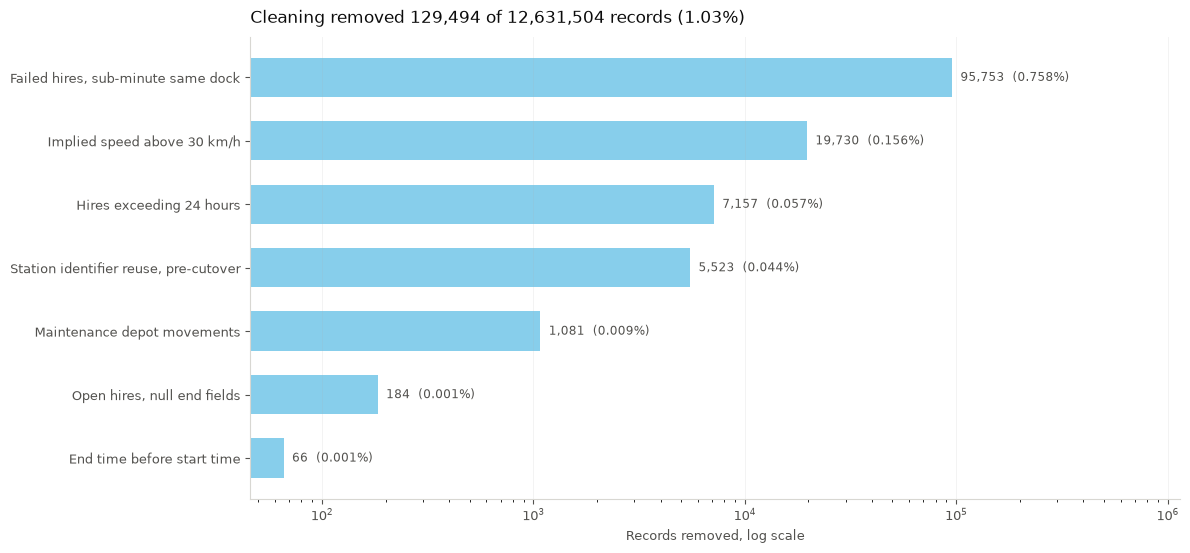

In [32]:
# Figure 2: The effect of each cleaning rule
led = cleaning_ledger.sort_values("removed")

fig, ax = plt.subplots(figsize=(12, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

bars = ax.barh(led["rule"], led["removed"], color=PALETTE[0], height=0.62)
# A log scale is necessary here, so a linear scale would render the smaller bars invisible.
ax.set_xscale("log")

for rect, n, pct in zip(bars, led["removed"], led["share"]):
    ax.annotate(f"{n:,}  ({pct:.3%})",
                xy=(rect.get_width(), rect.get_y() + rect.get_height() / 2),
                xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=INK_SOFT)

ax.set_xlim(right=led["removed"].max() * 12)
ax.set_xlabel("Records removed, log scale", color=INK_SOFT, fontsize=9)
ax.set_title(f"Cleaning removed {start_n - len(clean):,} of {start_n:,} records "
             f"({(start_n - len(clean)) / start_n:.2%})",
             loc="left", fontsize=12, color=INK, pad=10)
ax.grid(axis="x", alpha=0.15, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

plt.savefig(FIG_DIR / "fig02_cleaning_ledger.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

The log-scaled x-axis is necessary because exclusions span four orders of magnitude: from 66 temporally impossible records to 95,753 failed same-dock hires. The chart makes clear that the vast majority of the 1.03% removed are accounted for by a single well-understood category (failed hires 0.758%), with the remaining five rules contributing a negligible combined share.

The full cleaning pass retains 12,502,010 of 12,631,504 records (98.97%).

In [33]:
# Identifier reuse audit
pairs = (clean.groupby(["start_station_id", "start_station_name"], observed=True)
         .agg(journeys=("rental_id", "size"),
              first=("start_time", "min"),
              last=("start_time", "max"))
         .reset_index())

conflicts = pairs[pairs.duplicated("start_station_id", keep=False)].sort_values(
    ["start_station_id", "first"])
print("Identifiers carrying more than one station name:\n")
print(conflicts.to_string(index=False))

# Which name does the API hold for each of these identifiers?
api_name = by_id["station_name"]
conflicts = conflicts.assign(
    api_name=conflicts["start_station_id"].astype("Int64").map(api_name))
conflicts["name_matches_api"] = (
    norm(conflicts["start_station_name"]).values == norm(conflicts["api_name"]).values)
print("\nAgainst the API name:\n")
print(conflicts[["start_station_id", "start_station_name", "api_name",
                 "journeys", "name_matches_api"]].to_string(index=False))

bad = conflicts.loc[~conflicts["name_matches_api"], "journeys"].sum()
print(f"\nStarts with a legacy station label (name only, coordinates correct): {bad:,}")

Identifiers carrying more than one station name:

 start_station_id                start_station_name  journeys               first                last
             1145   Earnshaw Street , Covent Garden      1010 2025-01-01 00:35:00 2025-01-31 23:03:00
             1145    Bucknall Street, Covent Garden     22553 2025-02-01 00:50:00 2026-05-31 22:54:00
           300204     Victoria Rise, Clapham Common      5124 2025-01-01 00:54:00 2026-05-31 22:40:00
           300204 Victoria Rise, Clapham Common_OLD      2155 2025-02-01 07:26:00 2025-05-23 13:07:00

Against the API name:

 start_station_id                start_station_name                       api_name  journeys  name_matches_api
             1145   Earnshaw Street , Covent Garden Bucknall Street, Covent Garden      1010             False
             1145    Bucknall Street, Covent Garden Bucknall Street, Covent Garden     22553              True
           300204     Victoria Rise, Clapham Common  Victoria Rise, Clapham Common 

Two station identifiers carry more than one name in the clean journey data. Station 1145 (Covent Garden) was administratively renamed from "Earnshaw Street" to "Bucknall Street" in February 2025; as the BikePoint API returns a single coordinate pair for this identifier, the 1,010 affected journey starts hold correct spatial data and no further exclusion is required. Station 300204 (Victoria Rise, Clapham Common) appears under an "_OLD" -suffixed variant; the normalisation function already collapses both forms to a common key, so coordinates are unaffected. No additional cleaning rules are warranted beyond those recorded in the ledger.

In [34]:
# Correct identifier reuse
# TfL recycles station identifiers. Where one identifier carries two names,
# the locality suffix distinguishes a rename in place, which should be merged,
# from a reused identifier denoting a different station, which must not be.

def locality(s):
    """
    Extract the district portion of a station name (text after the final comma),
    stripping any _OLD suffix before splitting. Returns a lowercase string Series.
    Used to determine whether two names under the same ID refer to the same area.
    """
    return (s.astype(str)
            .str.replace(r"_OLD$", "", regex=True)
            .str.rsplit(",", n=1).str[-1]
            .str.strip().str.lower())

pairs = (clean.groupby(["start_station_id", "start_station_name"], observed=True)
         .agg(journeys=("rental_id", "size"), last=("start_time", "max"))
         .reset_index())
pairs["locality"] = locality(pairs["start_station_name"])

reused = []
for sid, grp in pairs[pairs.duplicated("start_station_id", keep=False)].groupby(
        "start_station_id", observed=True):
    if grp["locality"].nunique() > 1:
        # Different localities: the identifier denotes different places over
        # time. The API describes only the most recent, so earlier occupants
        # cannot be located and must not inherit the current coordinates.
        current = grp.loc[grp["last"].idxmax(), "start_station_name"]
        for nm in grp["start_station_name"]:
            if nm != current:
                reused.append((sid, nm))
                print(f"Identifier {sid} reused: '{nm}' is not '{current}', "
                      f"coordinates withheld")

if not reused:
    print("No identifier reuse detected across differing localities.")

# Withhold the station key wherever a record names a former occupant
before_start = clean["start_station_key"].isna().sum()
before_end = clean["end_station_key"].isna().sum()

for sid, nm in reused:
    for side in ("start", "end"):
        m = ((clean[f"{side}_station_id"] == sid)
             & (clean[f"{side}_station_name"].astype(str) == nm))
        clean.loc[m, f"{side}_station_key"] = pd.NA

print(f"\nStart keys withheld : {clean['start_station_key'].isna().sum() - before_start:,}")
print(f"End keys withheld   : {clean['end_station_key'].isna().sum() - before_end:,}")
print(f"\nUnresolved start keys now : "
      f"{clean['start_station_key'].isna().mean():.3%}")
print(f"Unresolved end keys now   : "
      f"{clean['end_station_key'].isna().mean():.3%}")

No identifier reuse detected across differing localities.

Start keys withheld : 0
End keys withheld   : 0

Unresolved start keys now : 0.845%
Unresolved end keys now   : 0.840%


In [35]:
# Station resolution ledger
# Distinct from the cleaning ledger: no records are removed here. These
# journeys remain in every temporal and duration analysis. What is withheld is
# a coordinate, so they are absent only from geospatial work.

n = len(clean)
unres_start = clean["start_station_key"].isna()
reused_ids = {sid for sid, _ in reused}
decom_ids = (
    clean.loc[unres_start & ~clean["start_station_id"].isin(reused_ids),
              "start_station_id"]
    .unique()
)

resolution_ledger = pd.DataFrame([
    {"reason": "Station decommissioned before the reference data was retrieved",
     "stations": len(decom_ids),
     "records": int(unres_start.sum()) - sum(
         int(((clean["start_station_id"] == sid)
              & (clean["start_station_name"].astype(str) == nm)).sum())
         for sid, nm in reused),
     "effect": "No coordinates available"},
    {"reason": "Station identifier reused for a different location",
     "stations": len({sid for sid, _ in reused}),
     "records": sum(
         int(((clean["start_station_id"] == sid)
              & (clean["start_station_name"].astype(str) == nm)).sum())
         for sid, nm in reused),
     "effect": "Coordinates withheld to avoid misplacement"},
])
resolution_ledger["share"] = (resolution_ledger["records"] / n).map("{:.3%}".format)

print(f"Records: {n:,}   Resolved to coordinates: "
      f"{(~unres_start).sum():,} ({(~unres_start).mean():.3%})\n")
print(resolution_ledger.to_string(index=False))
print("\nNo records are removed by either category. Both remain in all "
      "temporal and duration analysis and are excluded only from mapping.")

resolution_ledger.to_csv(REF_DIR / "station_resolution_ledger.csv", index=False)

Records: 12,502,010   Resolved to coordinates: 12,396,403 (99.155%)

                                                        reason  stations  records                                     effect  share
Station decommissioned before the reference data was retrieved         8   105607                   No coordinates available 0.845%
            Station identifier reused for a different location         0        0 Coordinates withheld to avoid misplacement 0.000%

No records are removed by either category. Both remain in all temporal and duration analysis and are excluded only from mapping.


In [36]:
# Round-trip flag
clean["is_round_trip"] = clean["start_station_key"] == clean["end_station_key"]
print(f"Nulls: {clean['is_round_trip'].isna().sum():,} "
      f"({clean['is_round_trip'].isna().mean():.3%})")

Nulls: 207,558 (1.660%)


The round-trip flag is null for 207,558 journeys (1.660%), slightly less than the sum of unresolved start and end key rates.

In [37]:
# Station role symmetry and net flow
starts = set(clean["start_station_key"].dropna().astype("int64"))
ends = set(clean["end_station_key"].dropna().astype("int64"))

print(f"Stations appearing as an origin: {len(starts):,}")
print(f"Stations appearing as a destination: {len(ends):,}")
print(f"Origin only, never a destination: {len(starts - ends):,}")
print(f"Destination only, never an origin: {len(ends - starts):,}")

# Does the network balance overall?
# Net flow per station: arrivals minus departures over the full observation window.
# A positive net indicates accumulation; negative indicates depletion.
dep = clean["start_station_key"].value_counts()
arr = clean["end_station_key"].value_counts()
flow = pd.DataFrame({"departures": dep, "arrivals": arr}).fillna(0)
flow["net"] = flow["arrivals"] - flow["departures"]
flow["turnover"] = flow["arrivals"] + flow["departures"]

# Network-level balance check
print(f"\n- Total departures: {flow['departures'].sum():,.0f}")
print(f"- Total arrivals: {flow['arrivals'].sum():,.0f}")
print(f"- Difference: {flow['arrivals'].sum() - flow['departures'].sum():,.0f}")

print("\nLargest net accumulators (more arrivals than departures):")
print(flow.nlargest(5, "net")[["departures", "arrivals", "net"]].to_string())
print("\nLargest net depleters (more departures than arrivals):")
print(flow.nsmallest(5, "net")[["departures", "arrivals", "net"]].to_string())

Stations appearing as an origin: 797
Stations appearing as a destination: 797
Origin only, never a destination: 0
Destination only, never an origin: 0

- Total departures: 12,396,403
- Total arrivals: 12,396,936
- Difference: 533

Largest net accumulators (more arrivals than departures):
       departures  arrivals    net
1067        39809     56556  16747
982         27749     42720  14971
999         36933     51577  14644
1161        44927     58334  13407
22179       44782     55994  11212

Largest net depleters (more departures than arrivals):
        departures  arrivals    net
2692         30810     21851  -8959
200017       23341     15489  -7852
1035         29536     22159  -7377
1075         77858     70951  -6907
1072         79184     72590  -6594


All 797 resolved stations act as both origins and destinations across the 17-month window; no station is exclusively a source or sink. This rules out structural isolation but does not preclude persistent directional bias at the station level.

At the network level, total arrivals (12,396,936) exceed total departures (12,396,403) by just 533, fewer than 0.005% of all journeys. This near-perfect closure is expected: the 533-cycle gap represents bikes in transit or docked but not yet recorded at the window boundary.

Station-level net flows reveal pronounced asymmetry beneath this aggregate balance. The five largest accumulators gain between 11,212 and 16,747 net cycles over the window; the five largest depleters lose between 6,594 and 8,959. These persistent imbalances require active rebalancing operations by TfL and are the primary subject of RQ2.

In [38]:
# Station imbalance rate
# Imbalance rate = net / turnover: the proportion of a station's total activity
# that is net accumulation (positive) or net depletion (negative).
# Normalising by turnover separates structural bias from sheer volume.

name_by_key = (xwalk.dropna(subset=["ref_station_name"])
               .drop_duplicates("station_id")
               .set_index("station_id")["ref_station_name"])
key_name = canon_terminal.to_frame("key").join(name_by_key).dropna()
key_name = key_name.drop_duplicates("key").set_index("key")["ref_station_name"]

flow["station"] = flow.index.map(key_name)
flow["imbalance_rate"] = flow["net"] / flow["turnover"]

# Daily net: average cycles that must be rebalanced per station per operating day
n_days = clean["start_time"].dt.normalize().nunique()
flow["daily_net"] = flow["net"] / n_days

cols = ["station", "departures", "arrivals", "net", "daily_net", "imbalance_rate"]

print("Stations requiring the most cycles to be removed (net accumulators):")
print(flow.nlargest(10, "net")[cols].round(3).to_string())

print("\nStations requiring the most cycles to be delivered (net depleters):")
print(flow.nsmallest(10, "net")[cols].round(3).to_string())

# Rate-based view, restricted to stations with meaningful traffic
busy = flow[flow["turnover"] >= 20000]
print(f"\nAmong {len(busy)} stations with turnover above 20,000:")
print("\nHighest imbalance rate, accumulating:")
print(busy.nlargest(8, "imbalance_rate")[cols].round(3).to_string())
print("\nHighest imbalance rate, depleting:")
print(busy.nsmallest(8, "imbalance_rate")[cols].round(3).to_string())

Stations requiring the most cycles to be removed (net accumulators):
                                    station  departures  arrivals    net  daily_net  imbalance_rate
1067        St. James's Square, St. James's       39809     56556  16747    32.4550          0.1740
982                 Holborn Circus, Holborn       27749     42720  14971    29.0140          0.2120
999                    Queen Street 1, Bank       36933     51577  14644    28.3800          0.1650
1161    Brushfield Street, Liverpool Street       44927     58334  13407    25.9830          0.1300
22179        Exhibition Road, Knightsbridge       44782     55994  11212    21.7290          0.1110
960               Hop Exchange, The Borough       50342     61394  11052    21.4190          0.0990
200128                 Queen Street 2, Bank       38980     49653  10673    20.6840          0.1200
1052                     Soho Square , Soho       42940     53055  10115    19.6030          0.1050
200226          Kingsway Southb

Normalising net flow by total turnover reveals the structural character of each station's imbalance, separating persistent directional bias from sheer volume.

**Absolute accumulators** cluster in the City of London and West End office core: St. James's Square (+16,747 net; 32.5 cycles/day), Holborn Circus (+14,971; 29.0 cycles/day), and Queen Street / Bank (+14,644; 28.4 cycles/day). These are morning-arrival destinations for commuters, generating a daily surplus that TfL must physically remove.

**Absolute depleters** are dominated by Waterloo Station (Stations 2 and 3 combined: approximately −15,500 net), consistent with a major rail interchange acting as a morning departure point. Lancaster Gate (−7,852; −20.2% rate) and stations around Hyde Park and St. John's Wood show residential and leisure demand patterns, emptying as riders commute outward.

Among the 588 stations with turnover above 20,000, Holborn Circus (21.2%) and Kingsway Southbound (22.1%) record the highest accumulation rates; Lancaster Gate (−20.2%) and St. John's Wood Road (−19.8%) record the steepest depletion rates. These rates quantify the rebalancing burden per journey handled, independent of station size.

In [39]:
# Turnover is measured across the full window, so a station commissioned or
# decommissioned partway through will appear artificially quiet. 
day = clean["start_time"].dt.normalize()
key = clean["start_station_key"]

active_days = day.groupby(key).nunique()
first_seen = day.groupby(key).min()
last_seen = day.groupby(key).max()

partial = active_days[active_days < 500].sort_values()
print(f"Stations active on fewer than 500 of 516 days: {len(partial)}")
print(pd.DataFrame({
    "active_days": active_days[partial.index],
    "first_seen": first_seen[partial.index].dt.date,
    "last_seen": last_seen[partial.index].dt.date,
    "turnover": flow["turnover"].reindex(partial.index),
    "station": flow["station"].reindex(partial.index),
}).head(38).to_string())

Stations active on fewer than 500 of 516 days: 38
                   active_days  first_seen   last_seen  turnover                                        station
start_station_key                                                                                              
1058                        51  2026-04-11  2026-05-31      1145                Orchard Place, Blackwall Tunnel
2635                       158  2025-12-25  2026-05-31      3717                        Agar Grove, Camden Town
3471                       196  2025-01-01  2026-05-31      9901                         Chadwell Street, Angel
300099                     214  2025-10-29  2026-05-31      7126                      Adeline Place, Bloomsbury
1212                       273  2025-08-18  2026-05-31     13654              Concert Hall Approach, South Bank
1061                       356  2025-05-30  2026-05-31     19404                    Stonecutter Street, Holborn
1060                       379  2025-01-01  2026-05-31

38 stations were active on fewer than 500 of 516 observation days, indicating **partial window coverage**. Three causes are distinguishable from the first_seen and last_seen dates:
- **Recently commissioned stations** with a late first_seen and a last_seen at the window close: Agar Grove (158 days, commissioned Dec 2025), Adeline Place (214 days, Oct 2025), Aquatic Centre (460 days, Feb 2025), Concert Hall Approach (273 days, Aug 2025). Their absolute turnover and net flow figures understate their structural role and should be treated with caution in volume-based rankings.
- **Decommissioned stations** with an early last_seen: Sopwith Way, Battersea Park (last seen Feb 2026) and Lowndes Square, Knightsbridge (last seen Apr 2026). Absolute net flows for these stations are not comparable to full-window stations.
- **Station 1058** (Orchard Place, Blackwall Tunnel) appears with just 51 active days (April to May 2026 only), confirming that the pre-cutover exclusion applied during cleaning correctly isolated the post-reuse period.

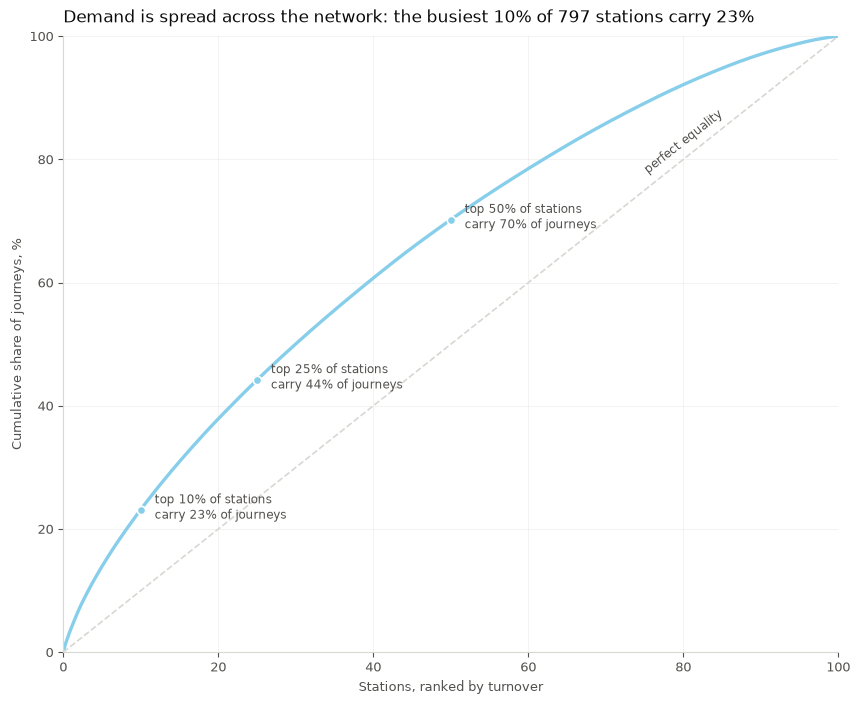

Busiest station: 151,774 journey ends
Quietest station: 1,145 journey ends
Ratio: 133 to 1


In [40]:
# Figure 3: Lorenz curve of station demand concentration
# Ranks stations by total turnover (arrivals + departures) and plots the
# cumulative share of all journeys against the cumulative share of stations.
# The dashed diagonal is the line of perfect equality; the further the curve
# lies below it, the more concentrated demand is in a minority of stations.

vol = (flow["turnover"].sort_values(ascending=False).reset_index(drop=True))
cum = vol.cumsum() / vol.sum() * 100
x = (np.arange(1, len(vol) + 1) / len(vol)) * 100

fig, ax = plt.subplots(figsize=(10, 8), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(x, cum, color=PALETTE[0], linewidth=2.4)
ax.plot([0, 100], [0, 100], color=GRID, linewidth=1.2, linestyle="--")
ax.annotate("perfect equality", xy=(80, 80), xytext=(0, -10),
            textcoords="offset points", fontsize=8.5, color=INK_SOFT,
            rotation=38, ha="center")

# Annotate three concentration thresholds
for pct in (10, 25, 50):
    share = cum.iloc[int(len(vol) * pct / 100) - 1]
    ax.plot([pct], [share], "o", color=PALETTE[0], markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=1.2)
    ax.annotate(f"top {pct}% of stations\ncarry {share:.0f}% of journeys",
                xy=(pct, share), xytext=(10, -6), textcoords="offset points",
                fontsize=8.5, color=INK_SOFT)

ax.set_xlabel("Stations, ranked by turnover", color=INK_SOFT, fontsize=9)
ax.set_ylabel("Cumulative share of journeys, %", color=INK_SOFT, fontsize=9)
ax.set_title(f"Demand is spread across the network: the busiest 10% of "
             f"{len(vol)} stations carry {cum.iloc[int(len(vol) * 0.1) - 1]:.0f}%",
             loc="left", fontsize=12, color=INK, pad=10)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(alpha=0.15, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

plt.savefig(FIG_DIR / "fig03_station_concentration.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

print(f"Busiest station: {flow['turnover'].max():,.0f} journey ends")
print(f"Quietest station: {flow['turnover'].min():,.0f} journey ends")
print(f"Ratio: {flow['turnover'].max() / flow['turnover'].min():.0f} to 1")

Figure 3 plots a Lorenz curve of station demand concentration, ranking all 797 stations by total turnover and tracing the cumulative share of journeys they collectively account for.

The curve lies below the perfect-equality diagonal but remains relatively close to it, indicating moderate rather than extreme concentration. The busiest 10% of stations (approx. 80 docks) account for 23% of all journeys; the top 25% carry 44%; the top half carries 70%. 

The absolute range is nonetheless substantial: the busiest station recorded 151,774 journey ends over the window, compared with 1,145 at the quietest, a 133-to-1 ratio. This spread reflects geographic heterogeneity rather than structural failure: central London stations adjacent to offices and transport interchanges generate an order of magnitude more activity than peripheral or recently commissioned docks.

In [41]:
# Temporal features

# Bank holidays are retrieved from the UK government's published calendar
# rather than hard-coded, since they determine whether a weekday exhibits
# commuting behaviour.

BANK_HOLIDAY_URL = "https://www.gov.uk/bank-holidays.json"

bh = requests.get(BANK_HOLIDAY_URL, timeout=30)
bh.raise_for_status()
events = bh.json()["england-and-wales"]["events"]
bank_holidays = pd.to_datetime([e["date"] for e in events]).date
bank_holidays = {d for d in bank_holidays
                 if WINDOW_START.date() <= d <= WINDOW_END.date()}

print(f"Bank holidays in the window: {len(bank_holidays)}")
for d in sorted(bank_holidays):
    print(f"  {d}  {[e['title'] for e in events if e['date'] == str(d)][0]}")

# Season lookup: meteorological seasons by month
SEASONS = {12: "Winter", 1: "Winter", 2: "Winter",
           3: "Spring", 4: "Spring", 5: "Spring",
           6: "Summer", 7: "Summer", 8: "Summer",
           9: "Autumn", 10: "Autumn", 11: "Autumn"}

# Calendar features
st = clean["start_time"]
clean["date"] = st.dt.date
clean["year"] = st.dt.year.astype("int16")
clean["month"] = st.dt.month.astype("int8")
clean["month_period"] = st.dt.to_period("M")
clean["hour"] = st.dt.hour.astype("int8")
clean["minute_of_day"] = (st.dt.hour * 60 + st.dt.minute).astype("int16")
clean["dow"] = st.dt.dayofweek.astype("int8")
clean["day_name"] = st.dt.day_name().astype("category")
clean["is_weekend"] = clean["dow"] >= 5
clean["is_bank_holiday"] = clean["date"].isin(bank_holidays)

# A working day is a weekday that is not a bank holiday
clean["is_working_day"] = ~clean["is_weekend"] & ~clean["is_bank_holiday"]
clean["season"] = clean["month"].map(SEASONS).astype("category")

clean["duration_min"] = (clean["duration_ms"] / 60000).astype("float32")
clean["is_round_trip"] = clean["start_station_key"] == clean["end_station_key"]

print(f"\nRecords: {len(clean):,}")
print(f" - Working days: {clean['is_working_day'].mean():.1%} of journeys")
print(f" - Weekend: {clean['is_weekend'].mean():.1%}")
print(f" - Bank holiday: {clean['is_bank_holiday'].mean():.2%}")
print(f" - Round trips: {clean['is_round_trip'].mean():.1%}")
print(f" - Median duration: {clean['duration_min'].median():.1f} min")
print(f" - Memory: {clean.memory_usage(deep=True).sum() / 1e9:.2f} GB")

clean[["start_time", "hour", "dow", "day_name", "is_working_day",
       "season", "duration_min", "is_round_trip"]].head()

Bank holidays in the window: 13
  2025-01-01  New Year’s Day
  2025-04-18  Good Friday
  2025-04-21  Easter Monday
  2025-05-05  Early May bank holiday
  2025-05-26  Spring bank holiday
  2025-08-25  Summer bank holiday
  2025-12-25  Christmas Day
  2025-12-26  Boxing Day
  2026-01-01  New Year’s Day
  2026-04-03  Good Friday
  2026-04-06  Easter Monday
  2026-05-04  Early May bank holiday
  2026-05-25  Spring bank holiday

Records: 12,502,010
 - Working days: 74.8% of journeys
 - Weekend: 23.5%
 - Bank holiday: 1.66%
 - Round trips: 2.6%
 - Median duration: 13.2 min
 - Memory: 2.51 GB


,start_time,hour,dow,day_name,is_working_day,season,duration_min,is_round_trip
0,2025-01-14 23:59:00,23,1,Tuesday,True,Winter,14.5078,False
1,2025-01-14 23:59:00,23,1,Tuesday,True,Winter,5.1197,False
2,2025-01-14 23:59:00,23,1,Tuesday,True,Winter,10.6792,False
3,2025-01-14 23:59:00,23,1,Tuesday,True,Winter,10.7091,False
5,2025-01-14 23:58:00,23,1,Tuesday,True,Winter,36.7162,False


Thirteen bank holidays fall within the 17-month observation window, covering all standard UK public holidays across 2025 and the first five months of 2026. Bank holiday dates are fetched from the UK government's live JSON calendar rather than hard-coded.

The journey distribution across day types reflects the commuter character of the network: 74.8% of journeys originate on working days, 23.5% on weekends, and 1.66% on bank holidays. Only 2.6% of journeys are round trips, confirming that the overwhelming majority of hires are point-to-point. Median journey duration is 13.2 minutes.

In [42]:
# Sort by start time to ensure monotonicity, which is important for time series analysis and plotting.
clean = clean.sort_values("start_time", kind="mergesort").reset_index(drop=True)
print(f"Monotonic: {clean['start_time'].is_monotonic_increasing}")

Monotonic: True


The clean DataFrame is sorted into strict chronological order using a stable sort, confirming monotonicity before any time series or rolling-window operations are applied.

In [43]:
# Identify commuter hours empirically
# Commuting is inferred from the ratio of mean hourly demand on working days to
# that at weekends, rather than assumed from conventional office hours.
# The threshold is the mean of the observed ratios. 

n_work = clean.loc[clean["is_working_day"], "date"].nunique()
n_wknd = clean.loc[clean["is_weekend"], "date"].nunique()

work_h = clean[clean["is_working_day"]].groupby("hour", observed=True).size() / n_work
wknd_h = clean[clean["is_weekend"]].groupby("hour", observed=True).size() / n_wknd

prof = pd.DataFrame({"working_day": work_h, "weekend": wknd_h})
prof["ratio"] = prof["working_day"] / prof["weekend"]

THRESHOLD = prof["ratio"].mean()
prof["is_commuter_hour"] = prof["ratio"] >= THRESHOLD
commuter_hours = sorted(prof.index[prof["is_commuter_hour"]])

# Stability of the classification
s = np.sort(prof["ratio"].to_numpy())
above = s[s >= THRESHOLD].min()
below = s[s < THRESHOLD].max()

print(f"Working days in window : {n_work}    Weekend days : {n_wknd}\n")
print(prof.round(2).to_string())

print(f"\nThreshold, mean observed ratio: {THRESHOLD:.3f}")
print(f"Commuter hours: {commuter_hours}")
print(f"\nLowest qualifying ratio: {above:.3f}")
print(f"Highest excluded ratio: {below:.3f}")
print(f"The classification is identical for any threshold in "
      f"({below:.3f}, {above:.3f}]")

Working days in window : 355    Weekend days : 148

      working_day   weekend  ratio  is_commuter_hour
hour                                                
0        144.7600  341.4700 0.4200             False
1         72.0700  214.9300 0.3400             False
2         41.4100  137.4500 0.3000             False
3         31.1100   94.4900 0.3300             False
4         50.7700   67.6500 0.7500             False
5        149.5000   76.5500 1.9500              True
6        618.3300  135.0300 4.5800              True
7       1682.3300  280.4600 6.0000              True
8       3214.1300  562.5600 5.7100              True
9       1778.5700  946.7400 1.8800              True
10      1049.5500 1280.7400 0.8200             False
11       983.8000 1489.1600 0.6600             False
12      1140.1800 1636.4700 0.7000             False
13      1140.4300 1659.3800 0.6900             False
14      1076.2800 1640.8000 0.6600             False
15      1226.0700 1624.3000 0.7500             

Commuter hours are identified empirically by computing the ratio of mean hourly demand on working days to mean hourly demand on weekends. An hour is classified as a commuter hour when its ratio meets or exceeds the mean ratio across all 24 hours (threshold: 1.596), indicating that the working-day surplus is above average.

Eight hours qualify: **05:00-09:59** (morning peak) and **17:00-19:59** (evening peak). The morning peak is the more pronounced of the two: hour 07 reaches a ratio of 6.0, meaning working-day demand is six times higher than weekend demand at that hour, compared with a maximum evening ratio of 2.03 at hour 18. The asymmetry reflects later-dispersing evening commutes and discretionary trips that blur the distinction between commuter and leisure demand after 20:00.

The gap between the lowest qualifying ratio (1.641) and the highest excluded ratio (1.445) is 0.196, confirming that the eight-hour classification is stable across a wide range of plausible thresholds and is not an artefact of the specific cut-off chosen.

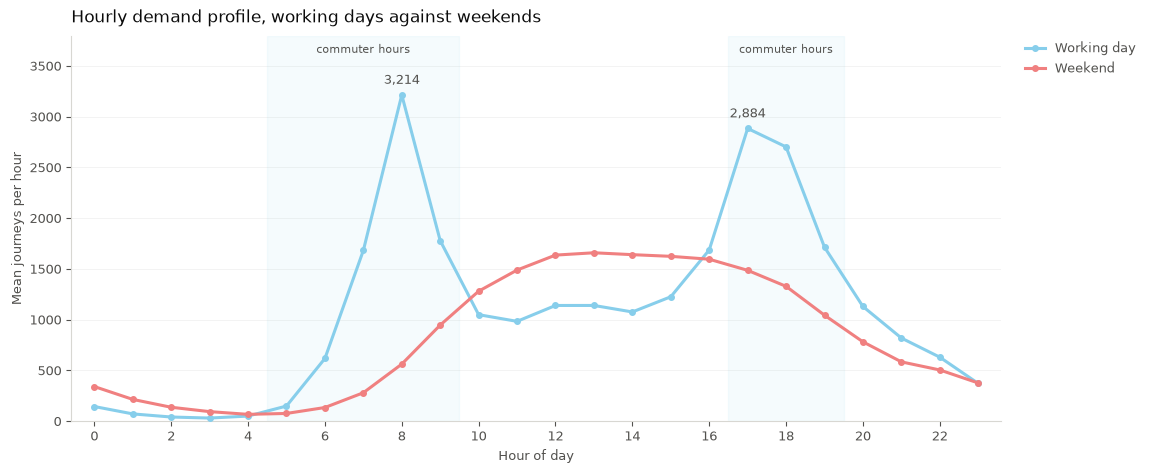

In [44]:
# Figure 4: Visualise the hourly demand profile
fig, ax = plt.subplots(figsize=(12, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# Shade the derived commuter hours as contiguous bands
runs, start = [], commuter_hours[0]
for prev, cur in zip(commuter_hours, commuter_hours[1:] + [None]):
    if cur != prev + 1:
        runs.append((start, prev))
        start = cur
for lo, hi in runs:
    ax.axvspan(lo - 0.5, hi + 0.5, color=PALETTE[0], alpha=0.08, zorder=0)
    ax.annotate("commuter hours", xy=((lo + hi) / 2, 1.0),
                xycoords=("data", "axes fraction"),
                xytext=(0, -12), textcoords="offset points",
                ha="center", fontsize=8, color=INK_SOFT)

ax.plot(prof.index, prof["working_day"], color=PALETTE[0], linewidth=2.2,
        marker="o", markersize=4, label="Working day", zorder=3)
ax.plot(prof.index, prof["weekend"], color=PALETTE[7], linewidth=2.2,
        marker="o", markersize=4, label="Weekend", zorder=3)

for h in (prof["working_day"].idxmax(), prof.loc[12:, "working_day"].idxmax()):
    ax.annotate(f"{prof.loc[h, 'working_day']:,.0f}",
                xy=(h, prof.loc[h, "working_day"]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=9, color=INK_SOFT)

ax.set_ylabel("Mean journeys per hour", color=INK_SOFT, fontsize=9)
ax.set_xlabel("Hour of day", color=INK_SOFT, fontsize=9)
ax.set_title("Hourly demand profile, working days against weekends",
             loc="left", fontsize=12, color=INK, pad=10)
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(-0.6, 23.6)
ax.set_ylim(0, prof[["working_day", "weekend"]].to_numpy().max() * 1.18)
ax.legend(frameon=False, fontsize=9, labelcolor=INK_SOFT,
          loc="upper left", bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, handlelength=1.6)

ax.grid(axis="y", alpha=0.15, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

plt.savefig(FIG_DIR / "fig04_commuter_hours.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

**Figure 4** overlays the mean hourly demand profile for working days and weekends, with empirically derived commuter-hour bands shaded.

The working-day curve is sharply bimodal. The morning peak reaches 3,214 journeys per hour at 08:00, before falling steeply through the midday trough. A second peak of 2,884 journeys per hour occurs at 17:00, tapering gradually through the evening. The asymmetry between the two peaks (3,214 vs 2,884) is consistent with compressed morning commutes and more dispersed evening departures.

The weekend profile is unimodal and substantially flatter, rising gradually from around 09:00 to a broad plateau between 12:00 and 15:00 (approx.1,650-1,670 journeys per hour) before declining through the afternoon. Strikingly, weekend demand exceeds working-day demand between roughly 10:00 and 16:00, confirming that midday cycles are predominantly leisure use and that working-day demand dips below weekend levels outside commuter hours.

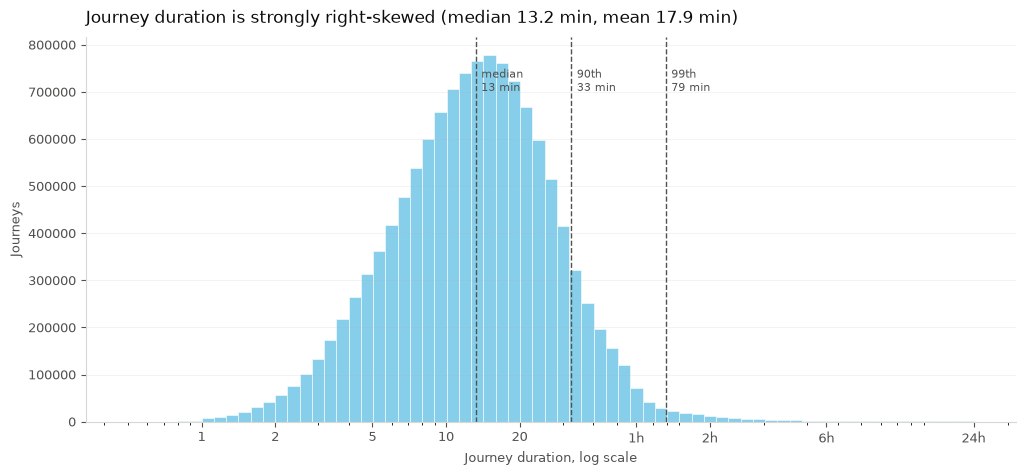

Skewness: 23.34
Kurtosis: 812.82
Mean: 17.9 min
Median: 13.2 min
Mean exceeds median by 35%


In [45]:
# Figure 5: Distribution of journey duration
dm = clean["duration_min"]
bins = np.logspace(np.log10(0.5), np.log10(dm.max()), 70)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.hist(dm, bins=bins, color=PALETTE[0], edgecolor=SURFACE, linewidth=0.4)
ax.set_xscale("log")

for q, lbl in [(0.5, "median"), (0.9, "90th"), (0.99, "99th")]:
    v = dm.quantile(q)
    ax.axvline(v, color=INK_SOFT, linewidth=1, linestyle="--")
    ax.annotate(f"{lbl}\n{v:.0f} min", xy=(v, ax.get_ylim()[1] * 0.92),
                xytext=(4, 0), textcoords="offset points",
                fontsize=8, color=INK_SOFT, va="top")

ax.set_xticks([1, 2, 5, 10, 20, 60, 120, 360, 1440])
ax.set_xticklabels(["1", "2", "5", "10", "20", "1h", "2h", "6h", "24h"])
ax.set_xlabel("Journey duration, log scale", color=INK_SOFT, fontsize=9)
ax.set_ylabel("Journeys", color=INK_SOFT, fontsize=9)
ax.set_title(f"Journey duration is strongly right-skewed "
             f"(median {dm.median():.1f} min, mean {dm.mean():.1f} min)",
             loc="left", fontsize=12, color=INK, pad=10)
ax.grid(axis="y", alpha=0.15, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

plt.savefig(FIG_DIR / "fig05_duration_distribution.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

print(f"Skewness: {dm.skew():.2f}")
print(f"Kurtosis: {dm.kurt():.2f}")

print(f"Mean: {dm.mean():.1f} min")
print(f"Median: {dm.median():.1f} min")
print(f"Mean exceeds median by {(dm.mean() / dm.median() - 1):.0%}")

**Figure 5** plots the distribution of journey duration on a log-scale x-axis, with bins equally spaced in log space to give each bar uniform proportional width. The log scale is necessary here: on a linear axis the long tail would compress the bulk of the distribution into an unreadably narrow region near the origin.

The distribution is approximately log-normal in its central body, with a pronounced right tail. The median is 13.2 minutes and the mean is 17.9 minutes, the mean exceeds the median by 35%, a direct consequence of the tail's leverage on the arithmetic average. The skewness of 23.34 and excess kurtosis of 812.82 confirm the extreme non-normality: a small number of long hires (the 99th percentile is 79 minutes; the cap is 24 hours) exert disproportionate influence on moment-based statistics. All duration analyses in this study therefore report the median and interquartile range rather than mean and standard deviation.

The 90th percentile of 33 minutes represents a natural informal boundary: nine in ten journeys are completed within half an hour, consistent with the network's design as a last-mile and short-trip urban cycling service.

In [46]:
# Commuter classification
# Morning and evening peaks are held separately, since directional flow differs
# between them and that distinction matters for the station imbalance analysis.

am_peak = [h for h in commuter_hours if h < 12]
pm_peak = [h for h in commuter_hours if h >= 12]

clean["is_commuter_trip"] = clean["is_working_day"] & clean["hour"].isin(commuter_hours)

conditions = [
    clean["is_working_day"] & clean["hour"].isin(am_peak),
    clean["is_working_day"] & clean["hour"].isin(pm_peak),
    clean["is_working_day"],
]
choices = ["Morning peak", "Evening peak", "Working day, off peak"]
clean["period"] = pd.Categorical(
    np.select(conditions, choices, default="Weekend or holiday"),
    categories=choices + ["Weekend or holiday"], ordered=False)

print(f"Morning peak: {am_peak}")
print(f"Evening peak: {pm_peak}\n")

print(pd.DataFrame({
    "journeys": clean["period"].value_counts(),
    "share_pct": clean["period"].value_counts(normalize=True).mul(100).round(1),
}).to_string())

print("\nDuration by period, minutes:")
print(clean.groupby("period", observed=True)["duration_min"]
      .agg(["count", "median", "mean", "std"]).round(1).to_string())

Morning peak: [5, 6, 7, 8, 9]
Evening peak: [17, 18, 19]

                       journeys  share_pct
period                                    
Working day, off peak   4116536    32.9000
Weekend or holiday      3151574    25.2000
Morning peak            2642217    21.1000
Evening peak            2591683    20.7000

Duration by period, minutes:
                         count  median    mean     std
period                                                
Morning peak           2642217 12.9000 15.4000 17.5000
Evening peak           2591683 13.5000 17.1000 27.3000
Working day, off peak  4116536 12.6000 17.6000 30.5000
Weekend or holiday     3151574 14.4000 20.9000 36.7000


Journeys are assigned to one of four mutually exclusive periods: morning peak (05:00-09:00, working days), evening peak (17:00-19:00, working days), working day off-peak, and weekend or holiday. The conditions are evaluated in priority order, so a working-day commuter-hour journey is always classified as a peak period rather than off-peak.

The two peak periods are roughly equal in volume: morning peak accounts for 21.1% of all journeys (2,642,217) and evening peak for 20.7% (2,591,683). Together they constitute 41.8% of total demand, confirming the commuter backbone identified in Figure 4.

Duration varies systematically across periods. Morning peak journeys are the shortest (median 12.9 min), consistent with purposeful point-to-point commutes with minimal deviation. Evening peak journeys are slightly longer (median 13.5 min), and weekend or holiday journeys are longest (median 14.4 min), reflecting more exploratory or leisure-oriented routing. The widening standard deviation from morning peak (17.5 min) through to weekends (36.7 min) indicates increasing variability in trip purpose outside structured commuter hours.

                         p10    p25     p50     p75     p90     p95      p99     IQR  p90/p50
period                                                                                       
Morning peak          4.8000 8.0000 12.9000 19.6000 27.5000 33.3000  49.3000 11.6000   2.1300
Evening peak          4.9000 8.1000 13.5000 21.2000 30.9000 38.9000  61.6000 13.1000   2.2900
Working day, off peak 4.4000 7.3000 12.6000 20.8000 32.4000 43.5000  83.3000 13.5000   2.5700
Weekend or holiday    4.7000 8.0000 14.4000 24.7000 39.9000 52.3000 110.0000 16.7000   2.7700


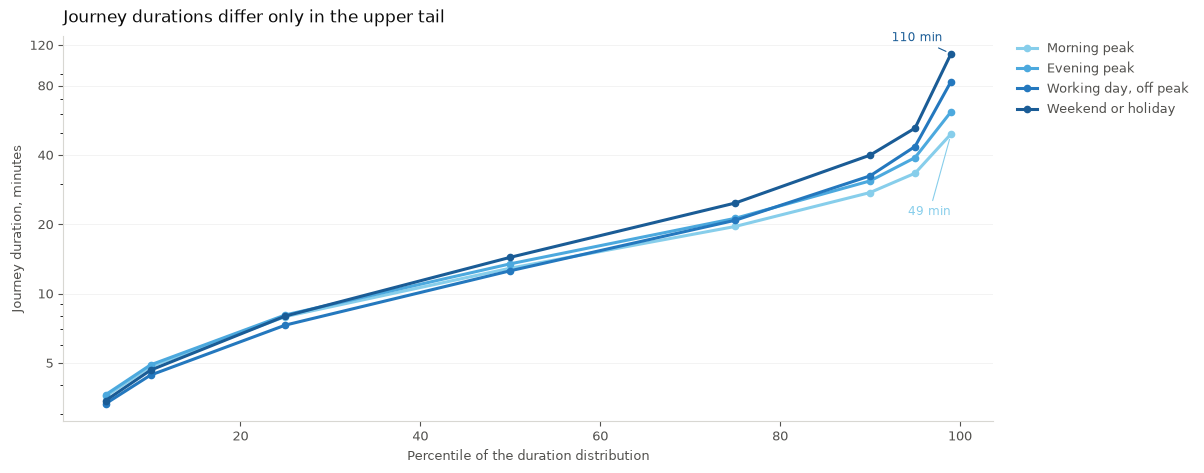

In [47]:
# Quantiles and interquartile range by period
qs = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
qt = (clean.groupby("period", observed=True)["duration_min"]
      .quantile(qs).unstack().round(1))
qt.columns = [f"p{int(q * 100)}" for q in qs]
qt["IQR"] = qt["p75"] - qt["p25"]
qt["p90/p50"] = (qt["p90"] / qt["p50"]).round(2)
print(qt.to_string())

# Journey duration does not distinguish commuting from leisure 
# at the centre of the distribution, only in its upper tail.

# Figure 6: Duration distributions diverge only in the upper tail
qs = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
qt = (clean.groupby("period", observed=True)["duration_min"].quantile(qs).unstack())

fig, ax = plt.subplots(figsize=(12, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for i, period in enumerate(qt.index):
    ax.plot([q * 100 for q in qs], qt.loc[period], color=PALETTE[i],
            linewidth=2.2, marker="o", markersize=4.5, label=period)

ax.set_yscale("log")
ax.set_yticks([5, 10, 20, 40, 80, 120])
ax.set_yticklabels(["5", "10", "20", "40", "80", "120"])
ax.set_ylabel("Journey duration, minutes", color=INK_SOFT, fontsize=9)
ax.set_xlabel("Percentile of the duration distribution", color=INK_SOFT, fontsize=9)
ax.set_title("Journey durations differ only in the upper tail",
             loc="left", fontsize=12, color=INK, pad=10)
ax.grid(axis="y", alpha=0.15, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

# Legend outside the plotting area, aligned to the top right
ax.legend(frameon=False, fontsize=9, labelcolor=INK_SOFT,
          loc="upper left", bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, handlelength=1.6)

ax.annotate(f"{qt.loc['Weekend or holiday', 0.99]:.0f} min",
            xy=(99, qt.loc["Weekend or holiday", 0.99]),
            xytext=(-6, 7), textcoords="offset points",
            ha="right", va="bottom", 
            fontsize=8.5, color=PALETTE[3],
            arrowprops=dict(arrowstyle="-", color=PALETTE[3],
                            linewidth=0.8, shrinkA=2, shrinkB=4))

ax.annotate(f"{qt.loc['Morning peak', 0.99]:.0f} min",
            xy=(99, qt.loc["Morning peak", 0.99]),
            xytext=(99, 24), ha="right", va="top",
            fontsize=8.5, color=PALETTE[0],
            arrowprops=dict(arrowstyle="-", color=PALETTE[0],
                            linewidth=0.8, shrinkA=2, shrinkB=4))

plt.savefig(FIG_DIR / "fig06_duration_quantiles.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

**Figure 6** plots selected quantiles of the journey duration distribution for each period on a log y-axis, revealing where the four distributions converge and where they diverge.

Below the 75th percentile the four lines are nearly indistinguishable: all periods share a 10th percentile of approximately 4.5-4.9 minutes and a median of 12.6-14.4 minutes. Duration alone cannot distinguish a commuter from a leisure cyclist in the bulk of the distribution. Differences emerge only above the 75th percentile and widen sharply beyond the 90th.

At the 99th percentile the gap is substantial: morning peak journeys reach 49 minutes, against 110 minutes for weekend or holiday trips, a ratio of more than two to one. The IQR follows the same ordering: 11.6 minutes (morning peak) through to 16.7 minutes (weekends). The p90/p50 ratio, a measure of tail heaviness relative to the median, ranges from 2.13 at morning peak to 2.77 at weekends, confirming that leisure-dominated periods carry proportionally heavier tails.

The implication for analysis is that median duration is an unreliable discriminator of trip purpose; the distributional differences are a tail phenomenon.

In [48]:
# Converting date from Python object to datetime64 and station name strings to
# categorical reduces memory footprint before partitioned persistence.
clean["date"] = pd.to_datetime(clean["date"])
clean["start_station_name"] = clean["start_station_name"].astype("category")
clean["end_station_name"] = clean["end_station_name"].astype("category")
print(f"Memory: {clean.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Memory: 1.20 GB


In [49]:
# Cleaned dataset and variables
sizes = []
for period, chunk in clean.groupby(clean["start_time"].dt.to_period("M"), observed=True):
    path = CLEAN_DIR / f"journeys_clean_{period}.parquet"
    chunk.to_parquet(path, index=False, compression="snappy")
    sizes.append({"month": str(period), "rows": len(chunk),
                  "size_mb": round(path.stat().st_size / 1e6, 2)})

part = pd.DataFrame(sizes)
print(f"Partitions written : {len(part)}")
print(f"Total on disk : {part['size_mb'].sum():,.0f} MB")
print(f"Largest partition : {part['size_mb'].max():,.1f} MB")

# Data dictionary, for the "description of key variables" requirement
dd = pd.DataFrame({
    "variable": clean.columns,
    "dtype": [str(clean[c].dtype) for c in clean.columns],
    "nulls": [int(clean[c].isna().sum()) for c in clean.columns],
    "distinct": [int(clean[c].nunique()) for c in clean.columns],
})
dd["null_pct"] = (dd["nulls"] / len(clean)).map("{:.3%}".format)
dd.to_csv(REF_DIR / "data_dictionary.csv", index=False)
print(f"\nVariables: {len(dd)}")
dd

Partitions written : 17
Total on disk : 344 MB
Largest partition : 24.1 MB

Variables: 28


,variable,dtype,nulls,distinct,null_pct
0,rental_id,Int32,0,12502010,0.000%
1,start_time,datetime64[us],0,679676,0.000%
2,start_station_id,Int32,0,822,0.000%
3,start_station_name,category,0,824,0.000%
4,end_time,datetime64[us],0,679642,0.000%
5,end_station_id,Int32,0,822,0.000%
6,end_station_name,category,0,824,0.000%
7,bike_id,Int32,0,13764,0.000%
8,bike_model,category,0,2,0.000%
9,duration_ms,Int64,0,2760698,0.000%


The data dictionary confirms 28 variables across 12,502,010 records. Only three variables carry nulls: start_station_key (0.845%), end_station_key (0.840%), and is_round_trip (1.660%), all attributable to the eight decommissioned stations documented in the resolution ledger. 

## Analysis and results

The five research questions are designed to characterise the cycle scheme network from complementary analytical perspectives, moving from aggregate temporal demand (RQ1) through spatial and structural imbalance (RQ2-RQ3) to fleet composition and user behaviour (RQ4) and unsupervised station classification (RQ5).

**RQ1: Demand Structure: What are the temporal patterns of demand?**

Understanding the temporal architecture of demand is the foundation of any operational analysis of a shared cycle-hire scheme. RQ1 examines three interlocking time scales: intra-day, intra-week, and annual, and asks not only how demand varies across each, but how stable and predictable that variation is. Answering this question establishes whether the scheme operates on a reliable cyclical rhythm or whether its patterns are too noisy to generalise, and it provides the interpretive baseline against which the network, adoption, and clustering analyses in RQ2-RQ5 are read.

Days in series: 516
Mean per day: 24,229
Minimum: 184 on 2025-08-05
Maximum: 45,278 on 2025-09-09


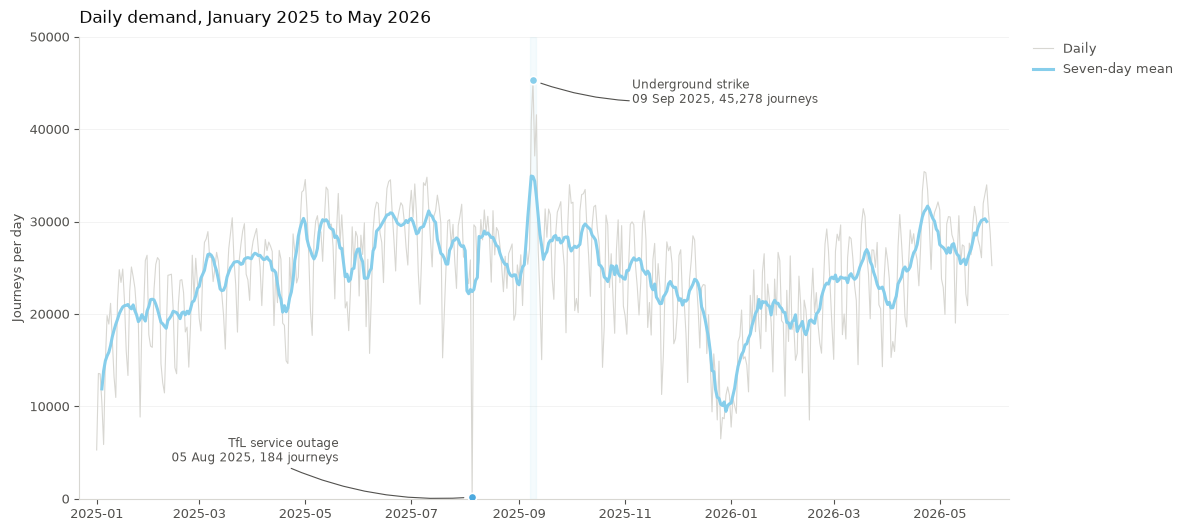

In [50]:
# Daily demand series (candidate for topic 6 time series analysis)
# Figure 7: The daily series is the base observation from which every other temporal
# result derives. A seven-day centred mean is overlaid because the weekly cycle
# is strong enough to obscure the trend: without smoothing, the eye reads the
# weekday-to-weekend oscillation rather than the seasonal movement beneath it.
# The mean is centred rather than trailing so that it does not lag the turning
# points it is meant to reveal.

# Also peak and dip points are annotated:
# 1. Peak being the underground strike in September 2025
# https://www.theguardian.com/uk-news/2025/sep/10/london-underground-tube-strike-rmt
# 2. Dip being the TfL service outage in August 2025
# https://www.bbc.co.uk/news/articles/c2kzvd7nlvvo

daily = clean.groupby("date", observed=True).size()
daily.index = pd.to_datetime(daily.index)
daily = daily.asfreq("D", fill_value=0)
roll = daily.rolling(7, center=True).mean()

print(f"Days in series: {len(daily)}")
print(f"Mean per day: {daily.mean():,.0f}")
print(f"Minimum: {daily.min():,} on {daily.idxmin().date()}")
print(f"Maximum: {daily.max():,} on {daily.idxmax().date()}")

fig, ax = plt.subplots(figsize=(12, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# Context band for the strike week
ax.axvspan(pd.Timestamp("2025-09-07"), pd.Timestamp("2025-09-11"),
           color=PALETTE[0], alpha=0.08, zorder=0)

ax.plot(daily.index, daily.values, color=GRID, linewidth=0.8,
        label="Daily", zorder=2)
ax.plot(roll.index, roll.values, color=PALETTE[0], linewidth=2.2,
        label="Seven-day mean", zorder=3)

peak_d, peak_v = daily.idxmax(), daily.max()
dip_d, dip_v = daily.idxmin(), daily.min()

ax.plot([peak_d], [peak_v], "o", color=PALETTE[0], markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.2, zorder=4)
ax.plot([dip_d], [dip_v], "o", color=PALETTE[1], markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.2, zorder=4)

# Callouts placed in empty regions, with leaders rather than crowding the point
ax.annotate(f"Underground strike\n{peak_d:%d %b %Y}, {peak_v:,} journeys",
            xy=(peak_d, peak_v), xytext=(pd.Timestamp("2025-11-05"), 44000),
            ha="left", va="center", fontsize=8.5, color=INK_SOFT,
            arrowprops=dict(arrowstyle="-", color=INK_SOFT,
                            linewidth=0.8, shrinkA=0, shrinkB=6,
                            connectionstyle="arc3,rad=-0.15"))

ax.annotate(f"TfL service outage\n{dip_d:%d %b %Y}, {dip_v:,} journeys",
            xy=(dip_d, dip_v), xytext=(pd.Timestamp("2025-05-20"), 5200),
            ha="right", va="center", fontsize=8.5, color=INK_SOFT,
            arrowprops=dict(arrowstyle="-", color=INK_SOFT,
                            linewidth=0.8, shrinkA=0, shrinkB=6,
                            connectionstyle="arc3,rad=0.15"))

ax.set_ylabel("Journeys per day", color=INK_SOFT, fontsize=9)
ax.set_title("Daily demand, January 2025 to May 2026",
             loc="left", fontsize=12, color=INK, pad=10)
ax.set_ylim(0, 50000)
ax.set_xlim(daily.index.min() - pd.Timedelta(days=10),
            daily.index.max() + pd.Timedelta(days=10))
ax.legend(frameon=False, fontsize=9, labelcolor=INK_SOFT,
          loc="upper left", bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, handlelength=1.6)
ax.grid(axis="y", alpha=0.15, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

plt.savefig(FIG_DIR / "fig07_daily_demand.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

**Figure 7** plots daily journey counts across the full 516-day window, with a seven-day centred rolling mean overlaid to reveal the seasonal trend beneath the weekly oscillation. Mean daily demand is 24,229 journeys.

Two anomalies are immediately visible. On 5 August 2025, a TfL system outage reduced recorded journeys to just 184, a near-complete dropout attributable to a data recording failure rather than genuine absence of demand; the day is retained in the series as a zero-equivalent rather than imputed, to preserve the integrity of the date spine. On 9 September 2025, a London Underground strike drove demand to 45,278 journeys, as commuters substituted cycle hire for suspended rail services.

In [51]:
# Quantifying the September 2025 strike
# The baseline is the median of the same weekday across the four weeks either
# side, excluding the strike itself. Matching on weekday is necessary because
# demand varies more between weekdays than between weeks, so a simple
# before-and-after mean would confound the strike with the day of the week.
# The median rather than the mean, so that a single unusual day in the
# comparison window cannot distort the baseline it is meant to establish.

# Strike week in September 2025
strike_days = pd.date_range("2025-09-07", "2025-09-11")
strike = daily.loc[strike_days]

# Baseline
window = daily.loc["2025-08-10":"2025-10-09"]
baseline = window[~window.index.isin(strike_days)]
base_by_dow = baseline.groupby(baseline.index.dayofweek).median()

cmp = pd.DataFrame({
    "actual": strike,
    "baseline": [base_by_dow[d.dayofweek] for d in strike_days],
})
cmp["uplift_pct"] = (cmp["actual"] / cmp["baseline"] - 1) * 100
cmp.index = [f"{d:%a %d %b}" for d in strike_days]
print(cmp.round(0).to_string())
print(f"\nAdditional journeys across the strike: "
      f"{(cmp['actual'] - cmp['baseline']).sum():,.0f}")

            actual   baseline  uplift_pct
Sun 07 Sep   27041 23450.0000     15.0000
Mon 08 Sep   40763 27231.0000     50.0000
Tue 09 Sep   45278 31145.0000     45.0000
Wed 10 Sep   37102 28900.0000     28.0000
Thu 11 Sep   41558 30964.0000     34.0000

Additional journeys across the strike: 50,052


The Underground strike of 8-11 September 2025 produced a sustained and quantifiable uplift in cycle hire demand. Against a weekday-matched median baseline drawn from the eight weeks either side of the strike, demand on Monday 8 September exceeded expectations by 50%. Absolute demand peaked on Tuesday 9 September at 45,278 journeys. Uplift persisted throughout the strike week. The Sunday preceding the strike showed a modest 15% above-baseline increase, consistent with advance planning rather than a systematic modal shift.

Across the five days, approximately 50,052 additional journeys were made above the expected baseline, equivalent to roughly two full days of typical demand. The pattern confirms that cycle hire functions as a genuine substitution service during major transit disruptions, absorbing a measurable share of displaced Underground commuter demand.

In [52]:
# Daily completeness audit
low = daily.sort_values().head(15).to_frame("journeys")
low["weekday"] = low.index.day_name()
low["bank_holiday"] = low.index.isin(pd.to_datetime(sorted(bank_holidays)))
print("Fifteen lowest days:\n")
print(low.to_string())

# Ratio to the median of the same weekday in the surrounding month
same_dow = daily.groupby(daily.index.dayofweek).transform(
    lambda s: s.rolling(9, center=True, min_periods=3).median())
ratio = daily / same_dow
suspect = ratio[ratio < 0.5].sort_values()
print(f"\nDays below half the local median for that weekday: {len(suspect)}\n")
print(pd.DataFrame({"journeys": daily[suspect.index],
                    "ratio": suspect.round(3),
                    "weekday": suspect.index.day_name()}).to_string())

Fifteen lowest days:

            journeys    weekday  bank_holiday
date                                         
2025-08-05       184    Tuesday         False
2025-01-01      5284  Wednesday          True
2025-01-05      5871     Sunday         False
2025-12-26      6484     Friday          True
2026-01-01      7759   Thursday          True
2026-02-15      8523     Sunday         False
2025-12-24      8534  Wednesday         False
2025-12-28      8662     Sunday         False
2025-12-27      8796   Saturday         False
2025-01-26      8846     Sunday         False
2026-01-04      9245     Sunday         False
2025-12-21      9410     Sunday         False
2026-01-03     10051   Saturday         False
2025-01-04     10382   Saturday         False
2026-01-02     10931     Friday         False

Days below half the local median for that weekday: 6

            journeys  ratio    weekday
date                                  
2025-08-05       184 0.0060    Tuesday
2025-01-01      5284 0.2

The completeness audit identifies six days where demand falls below half the local weekday median. Five of the six have an immediately interpretable cause that involves no data loss.

The service outage of 5 August 2025 stands apart: a ratio of 0.006 (184 journeys against a typical Tuesday of approximately 30,000) confirms a near-total recording failure rather than a demand event.

The remaining five suspect days cluster entirely within the Christmas-New Year period: Christmas Eve, Boxing Day, New Year's Eve, and both New Year's Days in the window. All five are plausible low-demand days combining a bank holiday or eve effect with the quietest part of the seasonal calendar; demand recovering to normal levels immediately either side of each confirms there is no persistent gap in the data.

Fourteen of the fifteen lowest absolute days are either bank holidays, the Christmas-New Year period, or winter Sundays during January and February. No unexplained gaps or systematic recording failures are present beyond the confirmed August outage.

In [53]:
# Did the outage on August 5th, 2025 have any impact on the days immediately preceding and following it?
for d in ["2025-08-04", "2025-08-05", "2025-08-06"]:
    h = clean.loc[clean["date"] == d].groupby("hour", observed=True).size()
    print(f"\n{d}: {h.sum():,} journeys across {len(h)} hours")
    print(h.to_string())


2025-08-04: 25,850 journeys across 24 hours
hour
0      225
1      118
2       69
3       52
4       49
5      143
6      646
7     1595
8     2875
9     1629
10    1054
11     880
12    1101
13     981
14     985
15    1055
16    1478
17    2921
18    2834
19    1995
20    1326
21     888
22     610
23     341

2025-08-05: 184 journeys across 13 hours
hour
0      24
9       2
12      1
13      1
14      2
15      1
16      3
17      1
19      3
20      2
21     11
22     18
23    115

2025-08-06: 29,648 journeys across 24 hours
hour
0      122
1        5
2        7
3       21
4       20
5      125
6      600
7     1618
8     3165
9     1792
10    1062
11    1111
12    1280
13    1362
14    1211
15    1405
16    1960
17    3577
18    3350
19    2209
20    1447
21    1033
22     761
23     405


The hourly breakdown confirms that the outage was entirely contained within 5 August 2025. 

In [54]:
# Anomaly treatment for modelling series

# 5 August 2025: TfL service outage caused by an overrunning software upgrade.
# The day is retained in descriptive figures, since the collapse is real, but
# excluded from autocorrelation and decomposition, where a single point at
# 0.6% of normal would dominate the estimate.

ANOMALOUS = {pd.Timestamp("2025-08-05"): "Service outage, failed software upgrade"}

daily_model = daily.astype(float).copy()
daily_model.loc[list(ANOMALOUS)] = np.nan

# Impute from the same weekday either side, preserving weekly structure
same_dow = daily_model.groupby(daily_model.index.dayofweek).transform(
    lambda s: s.interpolate(limit_direction="both"))
daily_model = daily_model.fillna(same_dow)

for d, why in ANOMALOUS.items():
    print(f"{d:%d %b %Y}  observed {daily[d]:>6,}  "
          f"imputed {daily_model[d]:>8,.0f}   {why}")

print(f"\nSeries for modelling: {len(daily_model)} days, "
      f"{daily_model.isna().sum()} nulls")

# September 2025 strike: retained without adjustment
# The Underground strike of 7 to 11 September 2025 is a demand response, not a
# supply failure. The scheme operated normally and Londoners chose it in
# unusual numbers, so the elevated counts are genuine behaviour rather than a
# measurement artefact. Imputing them would remove a finding.

# The asymmetry with 5 August is deliberate. The outage left demand unobserved
# and therefore unmeasurable; the strike left it fully observed.

STRIKE = pd.date_range("2025-09-07", "2025-09-11")

assert (daily_model.loc[STRIKE] == daily.loc[STRIKE]).all(), \
    "Strike days must pass through the modelling series unchanged"

print("\nUnderground strike, 7 to 11 September 2025: retained unaltered")
print(f" - Days: {len(STRIKE)}")
print(f" - Observed journeys: {daily.loc[STRIKE].sum():,}")
print(f" - Expected baseline: {cmp['baseline'].sum():,.0f}")
print(f" - Excess: {(cmp['actual'] - cmp['baseline']).sum():,.0f} "
      f"({cmp['uplift_pct'].mean():.0f}% mean uplift)")
print("\nRetained so that the seasonal decomposition identifies both events "
      "from the residual component without being told about them.")

05 Aug 2025  observed    184  imputed   30,932   Service outage, failed software upgrade

Series for modelling: 516 days, 0 nulls

Underground strike, 7 to 11 September 2025: retained unaltered
 - Days: 5
 - Observed journeys: 191,742
 - Expected baseline: 141,690
 - Excess: 50,052 (35% mean uplift)

Retained so that the seasonal decomposition identifies both events from the residual component without being told about them.


Two anomalies require different treatments before the modelling series:
- The 5 August outage is imputed. Demand that day was unobserved rather than genuinely absent: 184 recorded journeys against an imputed value of 30,932 reflects a recording failure, not a demand event. A single point at 0.6% of normal would otherwise dominate the STL residual and distort the autocorrelation structure. Imputation uses same-weekday rolling interpolation, which preserves the weekly seasonal structure without introducing a smooth trend artefact.
- The Underground strike (7-11 September 2025) is retained unchanged. The network operated normally throughout; the 50,052-journey excess above baseline represents real demand captured without loss. Imputing it would erase a genuine behavioural finding.

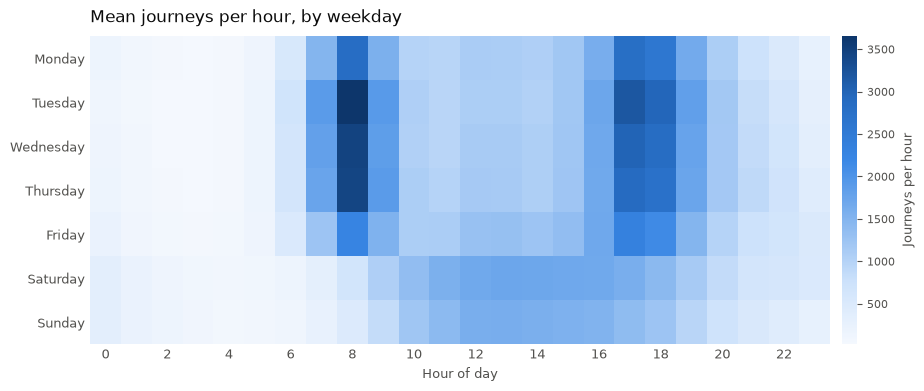

Busiest cell : ('Tuesday', np.int8(8)) at 3,655 per hour
Quietest cell: ('Tuesday', np.int8(3)) at 25 per hour


In [55]:
# Figure 8: Hour by weekday heatmap (candidate for topic 9)
# Two dimensions of the weekly cycle at once, which neither a line chart nor a
# table can show simultaneously. Cell values are means per day rather than
# totals, so that weekdays and weekend days are comparable despite there being
# two and a half times as many of the former.

DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

# 5 August is excluded, consistent with the treatment of the outage elsewhere:
# the map describes typical structure, and that day is not typical.
hm = clean[clean["date"] != pd.Timestamp("2025-08-05")]

n_days = hm.groupby("day_name", observed=True)["date"].nunique()
grid = (hm.groupby(["day_name", "hour"], observed=True).size()
        .unstack(fill_value=0).reindex(DAY_ORDER))
grid = grid.div(n_days.reindex(DAY_ORDER), axis=0)

BLUE_RAMP = LinearSegmentedColormap.from_list(
    "tfl_blue", ["#f4f8fe", "#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#0d366b"])

fig, ax = plt.subplots(figsize=(10, 4), facecolor=SURFACE)
im = ax.imshow(grid.values, aspect="auto", cmap=BLUE_RAMP, origin="upper")

ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))
ax.set_yticks(range(7))
ax.set_yticklabels(DAY_ORDER)
ax.set_xlabel("Hour of day", color=INK_SOFT, fontsize=9)
ax.set_title("Mean journeys per hour, by weekday",
             loc="left", fontsize=12, color=INK, pad=10)
ax.tick_params(colors=INK_SOFT, labelsize=9, length=0)
for s in ax.spines.values():
    s.set_visible(False)

cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.03)
cbar.set_label("Journeys per hour", color=INK_SOFT, fontsize=9)
cbar.ax.tick_params(colors=INK_SOFT, labelsize=8)
cbar.outline.set_visible(False)

plt.savefig(FIG_DIR / "fig08_hour_weekday_heatmap.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

print(f"Busiest cell : {grid.stack().idxmax()} at {grid.stack().max():,.0f} per hour")
print(f"Quietest cell: {grid.stack().idxmin()} at {grid.stack().min():,.0f} per hour")

**Figure 8** encodes the full weekly demand cycle as a 7×24 heatmap, with cell colour representing mean journeys per hour normalised by the number of days of each type. 

- The structure is immediately legible. Monday through Friday display a strongly bimodal pattern: two dark columns at 08:00 and 17:00-18:00 separated by a pale midday trough. The morning column is narrower and more intense, with Tuesday 08:00 reaching 3,655 journeys per hour, the highest value in the grid. The evening column is broader, consistent with more dispersed departure times after work.
- Saturday and Sunday show a qualitatively different pattern: a single broad lighter band centred around 11:00-15:00, with no visible morning spike. 

In [56]:
# Friday is visibly weaker than Monday to Thursday at both peaks, 
# and Monday looks slightly softer than Tuesday to Thursday. 
# That is the hybrid-working signature: the commuting peak 
# is a Tuesday-to-Thursday phenomenon now.

# Weekday structure of the commuting peak
am = grid.loc[:, 7:9].mean(axis=1)
pm = grid.loc[:, 17:19].mean(axis=1)
mid = grid.loc[:, 11:15].mean(axis=1)

wk = pd.DataFrame({"morning_peak": am, "evening_peak": pm, "midday": mid})
wk["peak_vs_midday"] = (wk[["morning_peak", "evening_peak"]].mean(axis=1)
                        / wk["midday"])
ref = wk.loc[["Tuesday", "Wednesday", "Thursday"], "morning_peak"].mean()
wk["morning_vs_TWT"] = (wk["morning_peak"] / ref - 1) * 100

print(wk.round(2).to_string())
print(f"\nDynamic range: {grid.values.max() / grid.values.min():.0f} to 1, "
      f"from {grid.values.max():,.0f} at Tuesday 08:00 "
      f"to {grid.values.min():,.0f} at Tuesday 03:00")

           morning_peak  evening_peak    midday  peak_vs_midday  morning_vs_TWT
day_name                                                                       
Monday        1959.8700     2349.5100 1080.4200          1.9900        -18.4800
Tuesday       2483.1000     2655.7300 1062.9600          2.4200          3.2800
Wednesday     2370.6800     2533.8500 1092.9300          2.2400         -1.4000
Thursday      2359.0200     2445.7700 1111.3400          2.1600         -1.8800
Friday        1676.4900     1986.9700 1256.3700          1.4600        -30.2700
Saturday       675.7800     1385.3400 1672.6300          0.6200        -71.8900
Sunday         517.4000     1187.6600 1547.4100          0.5500        -78.4800

Dynamic range: 146 to 1, from 3,655 at Tuesday 08:00 to 25 at Tuesday 03:00


The numeric decomposition confirms the hybrid-working signature visible in the heatmap. Tuesday, Wednesday, and Thursday form the core commuting days, with mean morning peaks of 2,371-2,483 journeys per hour and peak-to-midday ratios of 2.16-2.42. Monday and Friday diverge markedly from this reference:
- **Monday** morning peak is 18.5% below the Tuesday-to-Thursday mean, yet its evening peak (2,350) exceeds its morning (1,960), suggesting a later commute-in pattern rather than reduced attendance overall.
- **Friday** morning peak is 30.3% below the mid-week reference and its midday demand (1,256) is the highest of any weekday, consistent with a significant proportion of workers taking the day remotely or departing early for leisure.

The peak-to-midday ratio crosses below 1.0 at the weekend (Saturday: 0.62; Sunday: 0.55), confirming that Saturday and Sunday are leisure-dominated days where midday demand exceeds any single peak hour.

Taken together, these figures establish that the commuting peak is concentrated in Tuesday-to-Thursday, a pattern consistent with the post-pandemic hybrid working norm widely reported across Central London employers.

In [57]:
# Morning vs evening peak asymmetry by day of week

ref_pm = wk.loc[["Tuesday", "Wednesday", "Thursday"], "evening_peak"].mean()
wk["evening_vs_TWT"] = (wk["evening_peak"] / ref_pm - 1) * 100
print(wk[["morning_vs_TWT", "evening_vs_TWT"]].round(1).to_string())

           morning_vs_TWT  evening_vs_TWT
day_name                                 
Monday           -18.5000         -7.7000
Tuesday            3.3000          4.3000
Wednesday         -1.4000         -0.4000
Thursday          -1.9000         -3.9000
Friday           -30.3000        -21.9000
Saturday         -71.9000        -45.6000
Sunday           -78.5000        -53.3000


- On **Monday**, the morning is 18.5% below the mid-week reference while the evening is only 7.7% below. This is consistent with a later Monday inbound commute (many workers begin later or work remotely in the morning) combined with a more typical evening return.
- On **Friday**, the morning is 30.3% below while the evening is 21.9% below, still a substantial suppression on both measures, but the evening retains more relative demand, likely because leisure trips and early-Friday social activity partially substitute for the lost commuter volume.
- At the **weekend**, the gap widens further: Saturday morning is 71.9% below the mid-week reference but the evening is only 45.6% below, and Sunday shows the largest asymmetry of all (78.5% vs 53.3%). Weekend evenings retain substantial demand from recreational and social use, buffering the collapse of the commuter signal.

Taken together, the morning peak is the cleaner indicator of commuter behaviour; the evening peak is a composite signal that becomes increasingly leisure-dominated away from the Tuesday-to-Thursday core.

In [58]:
# Is the Friday effect stable, or still moving?

fri = clean[(clean["dow"] == 4) & clean["is_working_day"]
            & clean["hour"].between(7, 9)]
twt = clean[clean["dow"].isin([1, 2, 3]) & clean["is_working_day"]
            & clean["hour"].between(7, 9)]

f = fri.groupby(fri["date"].dt.to_period("M")).size() / fri.groupby(
    fri["date"].dt.to_period("M"))["date"].nunique()
t = twt.groupby(twt["date"].dt.to_period("M")).size() / twt.groupby(
    twt["date"].dt.to_period("M"))["date"].nunique()

trend = ((f / t - 1) * 100).to_frame("friday_deficit_pct")
print(trend.round(1).to_string())
print(f"\nJan to May 2025 mean : {trend.iloc[:5, 0].mean():.1f}%")
print(f"Jan to May 2026 mean : {trend.iloc[-5:, 0].mean():.1f}%")

         friday_deficit_pct
date                       
2025-01            -40.8000
2025-02            -31.3000
2025-03            -30.1000
2025-04            -23.6000
2025-05            -25.5000
2025-06            -25.3000
2025-07            -25.6000
2025-08            -33.0000
2025-09            -26.0000
2025-10            -30.5000
2025-11            -32.0000
2025-12             -8.2000
2026-01            -38.8000
2026-02            -27.9000
2026-03            -29.1000
2026-04            -22.7000
2026-05            -24.6000

Jan to May 2025 mean : -30.3%
Jan to May 2026 mean : -28.6%


The monthly Friday deficit, the percentage by which Friday morning demand falls short of the Tuesday-to-Thursday mean, shows no meaningful convergence over the 17-month window. The comparable five-month periods (January to May) shift from a mean deficit of 30.3% in 2025 to 28.6% in 2026, a change of 1.7% that falls within month-to-month noise.

Two months stand out as outliers driven by calendar effects rather than behavioural change. January records the largest deficits in both years, consistent with a slow
return to office routines after the Christmas break. December 2025 shows the smallest deficit of any month (-8.2%), likely because end-of-year work obligations: team meetings, client events, project deadlines, pull a higher proportion of workers into the office on Fridays than in other months.

Excluding these seasonal outliers, the deficit oscillates in a band of roughly 22% to 33% with no discernible trend direction. The Friday effect is therefore a stable structural feature of the weekly cycle rather than a transitional artefact of post-pandemic adjustment still resolving.

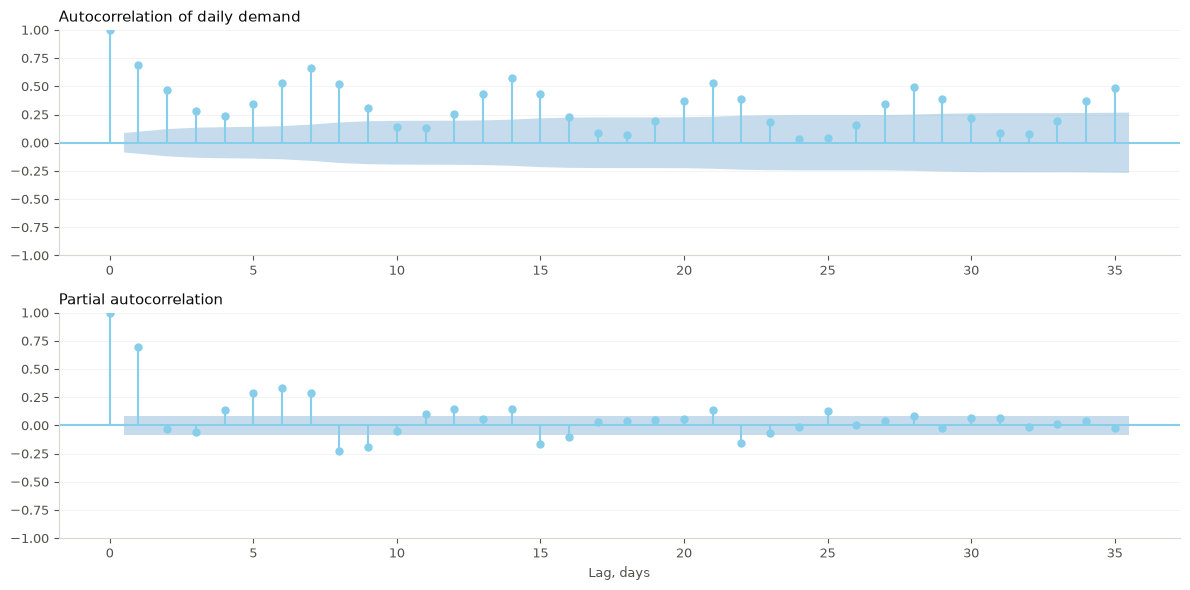

Autocorrelation at weekly lags:
  lag  1 days : 0.693
  lag  7 days : 0.664
  lag 14 days : 0.573
  lag 21 days : 0.527
  lag 28 days : 0.495
  lag 35 days : 0.489


In [59]:
# Autocorrelation and decomposition
# Figure 9: ACF and PACF of the daily series
# Quantifies how much of today's demand is predictable from previous days, and
# at what lag. The imputed series is used, since the outage would otherwise
# contaminate every lag it enters, appearing as spurious negative correlation
# at one, seven and fourteen days.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), facecolor=SURFACE)
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color(GRID)
    ax.tick_params(colors=INK_SOFT, labelsize=9)
    ax.grid(axis="y", alpha=0.15, linewidth=0.7)

plot_acf(daily_model, lags=35, ax=ax1, color=PALETTE[0],
         vlines_kwargs={"colors": PALETTE[0]}, title=None)
plot_pacf(daily_model, lags=35, ax=ax2, method="ywm", color=PALETTE[0],
          vlines_kwargs={"colors": PALETTE[0]}, title=None)
ax1.set_title("Autocorrelation of daily demand", loc="left", fontsize=11, color=INK)
ax2.set_title("Partial autocorrelation", loc="left", fontsize=11, color=INK)
ax2.set_xlabel("Lag, days", color=INK_SOFT, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig09_autocorrelation.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

a = acf(daily_model, nlags=35)
print("Autocorrelation at weekly lags:")
for lag in (1, 7, 14, 21, 28, 35):
    print(f"  lag {lag:>2} days : {a[lag]:.3f}")

- The ACF exhibits two overlapping structures. First, a slow decay from 0.693 at lag 1 that does not approach zero within the 35-day window, which is characteristic of a non-stationary trend component, today's demand is substantially influenced by where the seasonal envelope currently sits. Second, elevated spikes at lags 7, 14, 21, 28, and 35 confirm strong weekly periodicity: demand five weeks ago explains nearly half the variance of today's demand once trend effects are included.
- The PACF isolates the direct contribution of each lag after removing the mediation of shorter lags. A large spike at lag 1 (~0.70) and smaller but significant spikes at lags 6-8 account for nearly all of the structure visible in the ACF; beyond lag 9, partial autocorrelations fall within or close to the confidence band. This pattern is consistent with a process driven primarily by one-day persistence and one-week periodicity, with little additional explanatory content in intermediate lags.

Together, the two panels motivate an STL decomposition: the trend and weekly seasonal components need to be extracted before the residual structure of the series can be assessed.

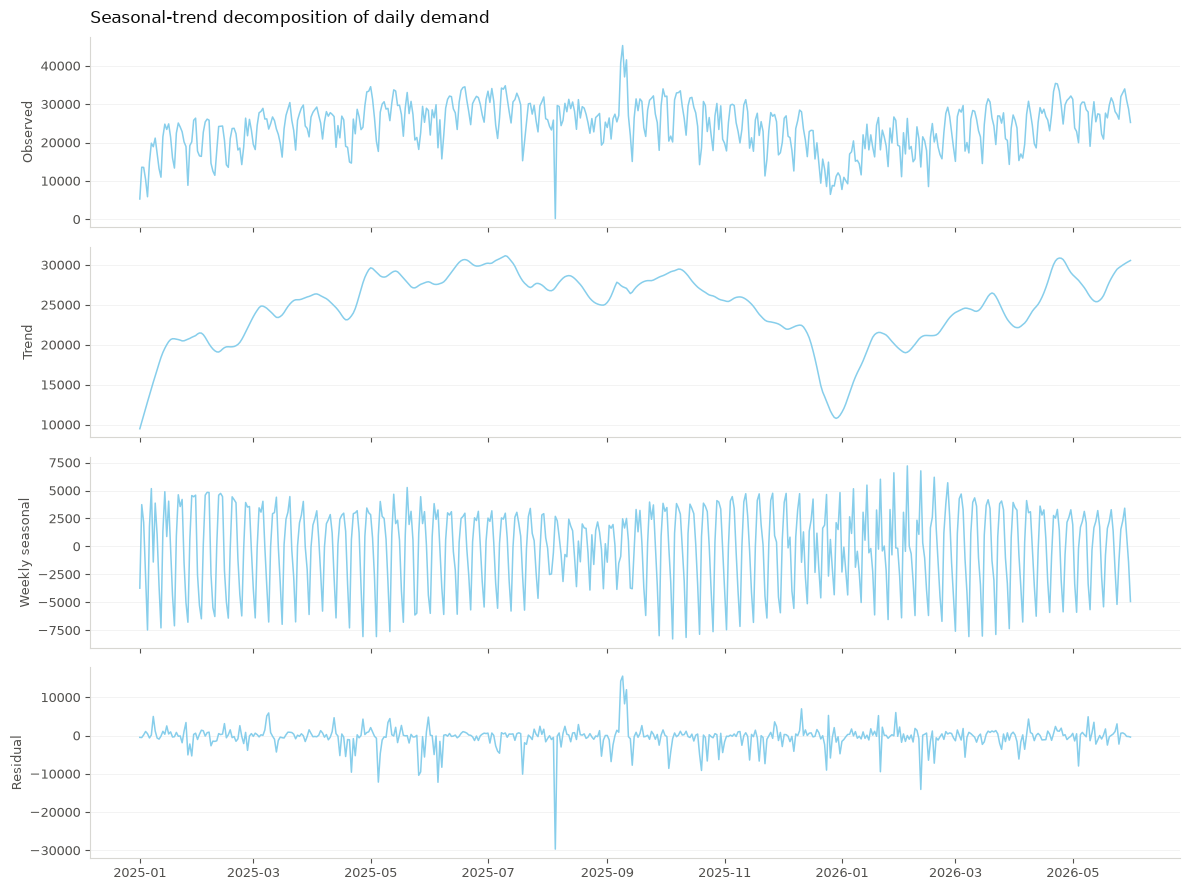

Ten largest residuals, with the events they correspond to:

            observed    residual    weekday
date                                       
2025-04-21     14640  -9576.0000     Monday
2025-05-05     17684 -12164.0000     Monday
2025-05-26     18194 -10376.0000     Monday
2025-06-05     18632 -12207.0000   Thursday
2025-07-19     15251 -10087.0000   Saturday
2025-08-05       184 -29669.0000    Tuesday
2025-09-08     40763  14225.0000     Monday
2025-09-09     45278  15534.0000    Tuesday
2025-09-11     41558  11990.0000   Thursday
2026-02-11     13621 -14073.0000  Wednesday


In [60]:
# Figure 10:Seasonal-trend decomposition
# Separates the series into trend, weekly cycle and residual.
# Run on the RAW series, including the outage, so that the residual component
# identifies both events without having been told about them. The weekly
# period is used because 17 months is insufficient to estimate an annual cycle.

stl = STL(daily.astype(float), period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True, facecolor=SURFACE)
for ax, series, label in zip(
        axes,
        [daily, stl.trend, stl.seasonal, stl.resid],
        ["Observed", "Trend", "Weekly seasonal", "Residual"]):
    ax.set_facecolor(SURFACE)
    ax.plot(series.index, series.values, color=PALETTE[0], linewidth=1.1)
    ax.set_ylabel(label, color=INK_SOFT, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color(GRID)
    ax.tick_params(colors=INK_SOFT, labelsize=9)
    ax.grid(axis="y", alpha=0.15, linewidth=0.7)
axes[0].set_title("Seasonal-trend decomposition of daily demand",
                  loc="left", fontsize=12, color=INK, pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_stl_decomposition.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

resid = stl.resid
extreme = resid.abs().nlargest(10).index.sort_values()
print("Ten largest residuals, with the events they correspond to:\n")
print(pd.DataFrame({
    "observed": daily[extreme],
    "residual": resid[extreme].round(0),
    "weekday": extreme.day_name(),
}).to_string())

**Figure 10** decomposes the raw daily series into trend, weekly seasonal, and residual components using STL (period=7). The raw series is used rather than the imputed one so that the residual component can surface both anomalies, the outage trough and the strike spike, without prior information. Their appearance in the residual validates that the decomposition is capturing genuine structure and not fitting to noise.

The **trend** rises from approximately 10,000 journeys per day in January 2025 through a summer 2025 plateau of around 29,000-31,000, falls steeply to a winter trough near 11,000 in January 2026, then recovers strongly to 30,000 by May 2026. The winter trough is notably deeper than the January 2025 starting point, consistent with the seasonal pattern being stronger than the underlying year-on-year growth at this timescale.

The **weekly seasonal** component oscillates in a band of roughly ±7,500 journeys, reflecting the weekday-to-weekend contrast documented in Figure 8. The amplitude is broadly stable across the window, with modest widening in summer months when absolute demand is higher.

The **residual** pikes and dips on anomalies. The largest is 5 August 2025, the service outage, confirming its recovery by the decomposition without instruction. The next largest are 8-11 September 2025, the Underground strike.

In [61]:
# Quantifying the weekly seasonal amplitude by month

seas = stl.seasonal.to_frame("seasonal")
amp = (seas.groupby(seas.index.to_period("M"))["seasonal"]
       .agg(lambda s: s.max() - s.min()))
print("Weekly seasonal amplitude by month:")
print(amp.round(0).to_string())
print(f"\nWidest: {amp.idxmax()} at {amp.max():,.0f}")
print(f"Narrowest: {amp.idxmin()} at {amp.min():,.0f}")
print(f"Ratio: {amp.max() / amp.min():.2f} to 1")

Weekly seasonal amplitude by month:
date
2025-01   12648.0000
2025-02   11311.0000
2025-03   11431.0000
2025-04   11507.0000
2025-05   13340.0000
2025-06    9915.0000
2025-07    9184.0000
2025-08    6596.0000
2025-09   11958.0000
2025-10   12372.0000
2025-11   12219.0000
2025-12   10354.0000
2026-01   13131.0000
2026-02   13906.0000
2026-03   12755.0000
2026-04   10864.0000
2026-05    9313.0000
Freq: M

Widest: 2026-02 at 13,906
Narrowest: 2025-08 at 6,596
Ratio: 2.11 to 1


The weekly seasonal amplitude, the peak-to-trough swing of the STL seasonal component within each calendar month, ranges from 6,596 (August 2025) to 13,906 (February 2026), a 2.11-to-1 ratio. Winter months consistently produce the widest amplitudes: weekday demand remains relatively stable year-round, whereas weekend leisure cycling collapses in cold weather, widening the contrast. Summer months produce the narrowest amplitudes: rising weekend leisure demand closes the gap with weekdays, compressing the seasonal swing. This seasonal modulation of the weekly rhythm is structurally distinct from the trend and confirms that the STL decomposition captures two interacting cycles, a 7-day weekly pattern whose intensity is itself governed by the annual calendar.

In [62]:
# Seasonal profile
# Demand per day rather than per month, so that months of unequal length and
# unequal working-day composition are comparable. 
# The service outage of 5 August 2025 is excluded

SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]
OUTAGE = pd.Timestamp("2025-08-05")

d = clean[clean["date"] != OUTAGE]

season_profile = (d.groupby("season", observed=True)
                  .agg(journeys=("rental_id", "size"),
                       days=("date", "nunique"),
                       median_min=("duration_min", "median"),
                       ebike_pct=("bike_model",
                                  lambda s: (s == "PBSC_EBIKE").mean() * 100),
                       weekend_pct=("is_weekend", "mean"))
                  .reindex(SEASON_ORDER))
season_profile["per_day"] = (season_profile["journeys"]
                             / season_profile["days"]).round(0)
season_profile["vs_winter"] = ((season_profile["per_day"]
                                / season_profile.loc["Winter", "per_day"] - 1)
                               * 100).round(1)
season_profile["weekend_pct"] = (season_profile["weekend_pct"] * 100).round(1)

print(season_profile[["days", "per_day", "vs_winter", "median_min",
                      "ebike_pct", "weekend_pct"]].round(2).to_string())

        days    per_day  vs_winter  median_min  ebike_pct  weekend_pct
season                                                                
Winter   149 18881.0000     0.0000     12.0700    18.7800      20.5000
Spring   184 25937.0000    37.4000     13.3700    18.3100      24.9000
Summer    91 27823.0000    47.4000     14.3400    18.0600      25.7000
Autumn    91 26200.0000    38.8000     13.3600    18.3500      22.1000


Seasonal demand, measured per day to control for calendar length and working-day composition, rises steadily from Winter to Summer before retreating in Autumn. Summer averages 27,823 journeys per day, a 47.4% lift over Winter (18,881); Spring and Autumn are broadly symmetric at roughly 38-39% above Winter. Median trip duration follows the same gradient, extending from 12.1 minutes in Winter to 14.3 minutes in Summer, consistent with more leisure cycling and greater willingness to travel longer distances in favourable weather. E-bike share is effectively stable across seasons, ranging narrowly from 18.1% (Summer) to 18.8% (Winter), indicating that e-bike adoption is not meaningfully driven by seasonal weather conditions within this window. Weekend trips as a share of daily volume rise from 20.5% in Winter to 25.7% in Summer, corroborating the STL amplitude findings: the weekend leisure component is the primary driver of seasonal modulation.

In [63]:
# Year-on-year comparison, January to May
# The window contains five overlapping months in consecutive years. Comparison
# is made on a per-day basis within day type, so that differences in the number
# of working days between the two years cannot drive the result.

ov = d[d["month"].between(1, 5)].copy()
ov["day_type"] = np.where(ov["is_working_day"], "Working day", "Weekend or holiday")

grp = (ov.groupby(["year", "day_type"], observed=True)
       .agg(journeys=("rental_id", "size"), days=("date", "nunique")))
grp["per_day"] = grp["journeys"] / grp["days"]

yoy = grp["per_day"].unstack(0)
yoy["change_pct"] = (yoy[2026] / yoy[2025] - 1) * 100

total = (ov.groupby("year", observed=True)
         .agg(journeys=("rental_id", "size"), days=("date", "nunique")))
total["per_day"] = total["journeys"] / total["days"]

print("Mean journeys per day, January to May:\n")
print(yoy.round(0).to_string())
print(f"\nAll days 2025: {total.loc[2025, 'per_day']:,.0f} per day "
      f"across {total.loc[2025, 'days']} days")
print(f"All days 2026: {total.loc[2026, 'per_day']:,.0f} per day "
      f"across {total.loc[2026, 'days']} days")
print(f"Change: {(total.loc[2026, 'per_day'] / total.loc[2025, 'per_day'] - 1) * 100:+.1f}%")

# Where has any change occurred: commuting, or everything else?
per = (ov.groupby(["year", "period"], observed=True)
       .agg(journeys=("rental_id", "size"), days=("date", "nunique")))
per["per_day"] = per["journeys"] / per["days"]
pv = per["per_day"].unstack(0)
pv["change_pct"] = (pv[2026] / pv[2025] - 1) * 100
print("\nBy period:\n")
print(pv.round(3).to_string())

Mean journeys per day, January to May:

year                     2025       2026  change_pct
day_type                                            
Weekend or holiday 18597.0000 18943.0000      2.0000
Working day        25311.0000 25540.0000      1.0000

All days 2025: 23,177 per day across 151 days
All days 2026: 23,399 per day across 151 days
Change: +1.0%

By period:

year                        2025       2026  change_pct
period                                                 
Morning peak           7236.6020  7485.9510      3.4460
Evening peak           7085.5730  6977.9220     -1.5190
Working day, off peak 10988.8250 11076.0200      0.7930
Weekend or holiday    18597.4580 18943.2650      1.8590


Year-on-year growth across the comparable January-to-May window is modest: overall demand rose +1.0% (23,177 to 23,399 journeys perday), with both working days (+0.8%) and weekends or holidays (+1.9%) contributing roughly equally at the day-type level. The period breakdown reveals an important asymmetry beneath that aggregate figure: morning peak demand grew by +3.4% whilst evening peak demand fell by -1.5%. 

The divergence between the two commuter peaks is consistent with continued asymmetric hybrid-working patterns: more riders are cycling in during core morning hours, but return journeys by bike haven't grown at the same rate, suggesting that afternoon commuters are increasingly substituting other modes or working from home on return trips.

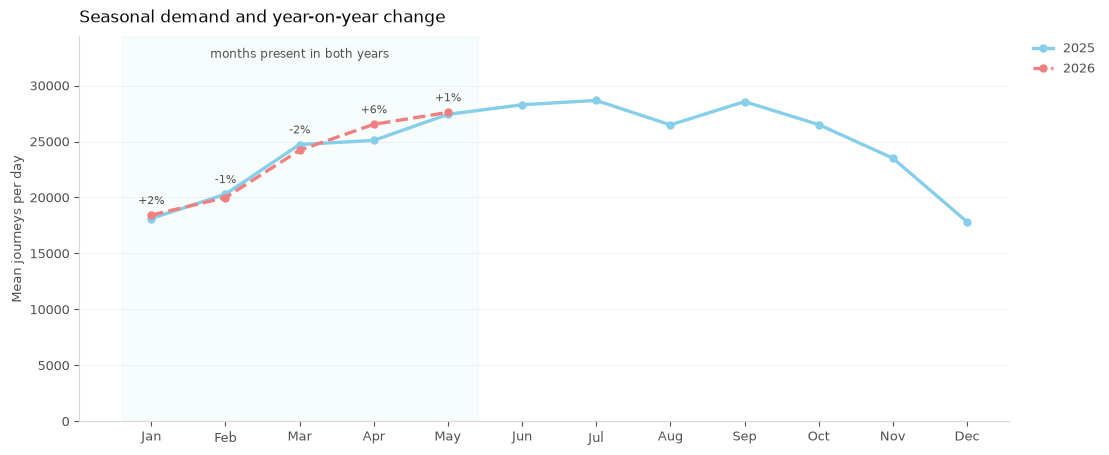

In [64]:
# Figure 11: Monthly demand, year on year
monthly = (d.groupby(["year", "month"], observed=True)
           .agg(journeys=("rental_id", "size"), days=("date", "nunique")))
monthly["per_day"] = monthly["journeys"] / monthly["days"]
mp = monthly["per_day"].unstack(0)

MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(12, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# Shade the five months present in both years
ax.axvspan(0.6, 5.4, color=PALETTE[0], alpha=0.06, zorder=0)
ax.annotate("months present in both years", xy=(3, 0.97),
            xycoords=("data", "axes fraction"), ha="center", va="top",
            fontsize=8.5, color=INK_SOFT)

ax.plot(mp.index, mp[2025], color=PALETTE[0], linewidth=2.4,
        marker="o", markersize=5, label="2025", zorder=3)
ax.plot(mp[2026].dropna().index, mp[2026].dropna(), color=PALETTE[7],
        linewidth=2.4, marker="o", markersize=5, label="2026", zorder=3,
        linestyle="--"
        )

for m in mp[2026].dropna().index:
    delta = (mp.loc[m, 2026] / mp.loc[m, 2025] - 1) * 100
    ax.annotate(f"{delta:+.0f}%", xy=(m, max(mp.loc[m, 2025], mp.loc[m, 2026])),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8, color=INK_SOFT)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTHS)
ax.set_ylabel("Mean journeys per day", color=INK_SOFT, fontsize=9)
ax.set_title("Seasonal demand and year-on-year change",
             loc="left", fontsize=12, color=INK, pad=10)
ax.set_ylim(0, float(np.nanmax(mp.astype("float64").to_numpy())) * 1.20)
ax.legend(frameon=False, fontsize=9, labelcolor=INK_SOFT,
          loc="upper left", bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, handlelength=1.6)
ax.grid(axis="y", alpha=0.15, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

plt.savefig(FIG_DIR / "fig11_seasonal_yoy.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

Figure 11 overlays mean journeys per day for each calendar month across 2025 and 2026. Year-on-year changes within the five comparable months are small and mixed (-2% to +6%), and the 2026 line closely replicates the 2025 seasonal shape, indicating that the scheme's annual demand structure is stable.

**RQ2: Network imbalance: Which stations systematically accumulate or deplete cycles, and how large is the rebalancing burden?**

A cycle-hire network is balanced when bikes removed from a station are replaced by arrivals before demand returns. When they are not, the operator must intervene with vehicles. RQ2 identifies which stations depend on that intervention structurally; not as a result of unusual events, but as a consequence of where they sit in London's commuting geography. It decomposes net flow by demand period to separate stations that self-correct through the return commute from those that do not, examines whether fleet type contributes to imbalance independently of location, and maps the residual spatial pattern to reveal the directional asymmetry between where Londoners begin and end their working day.

In [65]:
# Directional decomposition of station flow (candidate for topic 7 Geospatial)
# Net flow across the whole window conceals its mechanism. A station that
# accumulates during the morning peak and depletes during the evening peak is
# self-correcting: commuting creates the imbalance and commuting undoes it.
# A station that moves the same way in both peaks does not correct itself and
# must be rebalanced by vehicle.

def net_by(mask, label):
    """
    Compute net flow (arrivals minus departures) per station for a subset of journeys.

    Parameters
    ----------
    mask : pd.Series of bool
        Boolean mask selecting the rows of `clean` to include.
    label : str
        Name assigned to the returned Series.

    Returns
    -------
    pd.Series
        Net flow per station key, indexed by station key.
    """
    sub = clean[mask]
    dep = sub["start_station_key"].value_counts()
    arr = sub["end_station_key"].value_counts()
    return (arr.subtract(dep, fill_value=0)).rename(label)

am = net_by(clean["period"] == "Morning peak", "am_net")
pm = net_by(clean["period"] == "Evening peak", "pm_net")
off = net_by(clean["period"] == "Working day, off peak", "off_net")
wke = net_by(clean["period"] == "Weekend or holiday", "wke_net")

sf = pd.concat([am, pm, off, wke], axis=1).fillna(0)
sf = sf.join(flow[["station", "turnover", "net", "imbalance_rate"]], how="inner")

n_work = clean.loc[clean["is_working_day"], "start_time"].dt.normalize().nunique()
sf["am_per_day"] = sf["am_net"] / n_work
sf["pm_per_day"] = sf["pm_net"] / n_work

# How much of the morning imbalance does the evening peak reverse?
sf["reversal"] = np.where(sf["am_net"].abs() > 0,
                          -sf["pm_net"] / sf["am_net"], np.nan)

def archetype(r):
    """
    Classify a station by the sign of its morning and evening peak net flow.

    Parameters
    ----------
    r : pd.Series
        A row from `sf` containing at minimum `am_net` and `pm_net`.

    Returns
    -------
    str
        One of: 'Fills AM, empties PM', 'Empties AM, fills PM',
        'Fills in both peaks', 'Empties in both peaks'.
    """
    if r["am_net"] > 0 and r["pm_net"] < 0:
        return "Fills AM, empties PM"
    if r["am_net"] < 0 and r["pm_net"] > 0:
        return "Empties AM, fills PM"
    if r["am_net"] > 0 and r["pm_net"] > 0:
        return "Fills in both peaks"
    return "Empties in both peaks"

sf["archetype"] = sf.apply(archetype, axis=1)

print(f"Working days: {n_work}\n")
print("Station archetypes by peak-period flow direction:\n")
summ = (sf.groupby("archetype")
        .agg(stations=("turnover", "size"),
             mean_turnover=("turnover", "mean"),
             mean_net=("net", "mean"),
             median_reversal=("reversal", "median"))
        .sort_values("stations", ascending=False))
print(summ.round(2).to_string())

print("\nStations with high turnover and high am_net:\n")
strong = sf[(sf["turnover"] >= 20000) & (sf["am_net"].abs() > 2000)]
print(strong.nsmallest(10, "reversal")[
    ["station", "am_per_day", "pm_per_day", "reversal", "imbalance_rate"]
].round(3).to_string())

Working days: 355

Station archetypes by peak-period flow direction:

                       stations  mean_turnover  mean_net  median_reversal
archetype                                                                
Empties AM, fills PM        483     26510.4300 -654.4800           0.5500
Fills AM, empties PM        277     38549.9200 1166.0700           0.5800
Fills in both peaks          21     41643.8100  410.5700          -0.8000
Empties in both peaks        16     27247.0000 -936.0000          -0.3900

Stations with high turnover and high am_net:

                                            station  am_per_day  pm_per_day  reversal  imbalance_rate
end_station_key                                                                                      
1077             Royal London Hospital, Whitechapel      6.8820      0.9860   -0.1430          0.0050
2660                             Frith Street, Soho      6.1040      0.2030   -0.0330          0.0060
3504                           

Net flow decomposed by demand period classifies 797 stations into four archetypes. The two self-correcting types account for 760 stations: 483 empty in the morning and refill in the evening (residential origins), 277 fill in the morning and empty in the evening (employment destinations), each reversing roughly 55-58% of their morning imbalance by the evening peak. The remaining 37 stations accumulate or deplete across both peaks and require systematic rebalancing; despite being few in number, they carry the highest mean turnover.

In [66]:
# Does the imbalance pattern differ between fleets?
# Imbalance is normalised within each fleet, so that the 82:18 split in volume
# does not make the classic pattern appear stronger merely by being larger.
# A close correspondence justifies analysing the fleets together; divergence
# would indicate that vehicle type, not station, drives the imbalance.

def mode_flow(model):
    """
    Compute per-station net flow, turnover, and imbalance rate for one bike model.

    Parameters
    ----------
    model : str
        Bike model identifier, e.g. 'CLASSIC' or 'PBSC_EBIKE'.

    Returns
    -------
    pd.DataFrame
        DataFrame indexed by station_key with columns
        '{model}_net', '{model}_turn', and '{model}_rate'.
    """
    sub = clean[clean["bike_model"] == model]
    dep = sub["start_station_key"].value_counts()
    arr = sub["end_station_key"].value_counts()
    net = arr.subtract(dep, fill_value=0)
    turn = arr.add(dep, fill_value=0)
    return pd.DataFrame({f"{model}_net": net,
                         f"{model}_turn": turn,
                         f"{model}_rate": net / turn}).rename_axis("station_key")

cf = mode_flow("CLASSIC").join(mode_flow("PBSC_EBIKE"), how="inner")
cf = cf.join(sf[["station", "turnover"]], how="inner")

# Restrict to stations with enough of both fleets for the rate to be stable
cmp_ = cf[(cf["CLASSIC_turn"] >= 5000) & (cf["PBSC_EBIKE_turn"] >= 1000)]
r = cmp_["CLASSIC_rate"].corr(cmp_["PBSC_EBIKE_rate"])

print(f"Stations compared: {len(cmp_)} of {len(cf)}")
print(f"Correlation of imbalance rate, classic against e-bike: {r:.3f}\n")

# Gap: positive = e-bikes accumulate more (or deplete less) than classics
cmp_ = cmp_.assign(gap=cmp_["PBSC_EBIKE_rate"] - cmp_["CLASSIC_rate"])
print("Stations where e-bikes accumulate most relative to classics "
      "(candidate uphill effect):")
print(cmp_.nlargest(8, "gap")[
    ["station", "CLASSIC_rate", "PBSC_EBIKE_rate", "gap"]].round(3).to_string())
print("\nStations where classics accumulate most relative to e-bikes:")
print(cmp_.nsmallest(8, "gap")[
    ["station", "CLASSIC_rate", "PBSC_EBIKE_rate", "gap"]].round(3).to_string())

Stations compared: 780 of 797
Correlation of imbalance rate, classic against e-bike: 0.840

Stations where e-bikes accumulate most relative to classics (candidate uphill effect):
                                            station  CLASSIC_rate  PBSC_EBIKE_rate    gap
station_key                                                                              
1072                   Waterloo Station 3, Waterloo       -0.0800           0.1060 0.1860
1101                       Knightsbridge, Hyde Park       -0.4410          -0.2640 0.1770
2586                         Cloudesley Road, Angel       -0.2410          -0.0930 0.1480
999                            Queen Street 1, Bank        0.1440           0.2850 0.1410
2665                        Lord's, St. John's Wood       -0.2190          -0.0900 0.1280
10631                      Holland Park, Kensington       -0.1780          -0.0670 0.1110
200017                   Lancaster Gate , Bayswater       -0.2230          -0.1170 0.1060
200015     

In [67]:
# Testing the topographic hypothesis
# The fleet comparison suggests classics deplete disproportionately at elevated
# stations, consistent with riders descending on unassisted cycles and not
# returning. Elevation is retrieved so the hypothesis can be tested rather than
# inferred from the names of districts.

ELEV_CACHE = REF_DIR / "station_elevation.csv"
ELEV_API = "https://api.open-meteo.com/v1/elevation"

# Coordinates keyed by canonical station key rather than by raw station id
key_coords = (xwalk.dropna(subset=["ref_lat"])
              .assign(key=lambda d: d["station_id"].astype("Int64").map(canon_terminal))
              .dropna(subset=["key"])
              .drop_duplicates("key")
              .set_index("key")[["ref_lat", "ref_lon"]])
key_coords.index = key_coords.index.astype("int64")
key_coords.index.name = "station_key"
print(f"Stations with coordinates: {len(key_coords)}")

def fetch_elevation(lats, lons, max_retries=6):
    """
    Fetch elevations for a batch of coordinates from the Open-Meteo API,
    retrying with linear backoff on HTTP 429 responses.

    Parameters
    ----------
    lats : iterable of float
        Latitude values in decimal degrees.
    lons : iterable of float
        Longitude values in decimal degrees.
    max_retries : int, optional
        Maximum number of retry attempts before raising RuntimeError.

    Returns
    -------
    list of float
        Elevation in metres for each coordinate pair, in input order.

    Raises
    ------
    RuntimeError
        If the API refuses all retry attempts.
    """
    params = {"latitude": ",".join(f"{v:.5f}" for v in lats),
              "longitude": ",".join(f"{v:.5f}" for v in lons)}
    for attempt in range(max_retries):
        r = requests.get(ELEV_API, params=params, timeout=30)
        if r.status_code == 429:
            wait = 5 * (attempt + 1)
            print(f"    rate limited, waiting {wait}s")
            time.sleep(wait)
            continue
        r.raise_for_status()
        return r.json()["elevation"]
    raise RuntimeError("Elevation service refused after repeated retries")

if ELEV_CACHE.exists():
    pts = pd.read_csv(ELEV_CACHE, index_col="station_key")
    print(f"Loaded cached elevations for {len(pts)} stations")
else:
    pts = key_coords.dropna().copy()
    BATCH = 50
    elev = []
    for i in range(0, len(pts), BATCH):
        chunk = pts.iloc[i:i + BATCH]
        elev.extend(fetch_elevation(chunk["ref_lat"], chunk["ref_lon"]))
        print(f"  {min(i + BATCH, len(pts)):>3}/{len(pts)} retrieved")
        time.sleep(2.0)

    pts["elevation_m"] = elev
    pts.to_csv(ELEV_CACHE)
    print(f"\nCached to {ELEV_CACHE}")

print(f"Elevation range: {pts['elevation_m'].min():.0f} m "
      f"to {pts['elevation_m'].max():.0f} m")
print(f"Median: {pts['elevation_m'].median():.0f} m")

Stations with coordinates: 797
   50/797 retrieved
  100/797 retrieved
  150/797 retrieved
  200/797 retrieved
  250/797 retrieved
  300/797 retrieved
  350/797 retrieved
  400/797 retrieved
  450/797 retrieved
  500/797 retrieved
  550/797 retrieved
  600/797 retrieved
  650/797 retrieved
  700/797 retrieved
  750/797 retrieved
  797/797 retrieved

Cached to data/reference/station_elevation.csv
Elevation range: 1 m to 52 m
Median: 16 m


Elevations for 796 of 797 stations were retrieved from the Open-Meteo API and cached locally. 

Flat topographic signal.

In [68]:
# Does topography explain part of the imbalance?
# The gap between fleets is a difference taken within each station. Anything
# that varies by station but not by vehicle type, whether a district is
# residential or commercial, how far it sits from the employment core, how many
# docks it has, affects both fleets equally and therefore cancels. What remains
# is the effect of the vehicle itself. Since electrical assistance principally
# removes the penalty for climbing, an association between that gap and
# elevation isolates a topographic component that commuting cannot explain.

t = cmp_.join(pts["elevation_m"], how="inner")
print(f"Stations tested: {len(t)}\n")

print("Correlation with station elevation:")
print(f"  Classic imbalance rate: {t['CLASSIC_rate'].corr(t['elevation_m']):+.3f}")
print(f"  E-bike imbalance rate: {t['PBSC_EBIKE_rate'].corr(t['elevation_m']):+.3f}")
print(f"  Gap, e-bike less classic: {t['gap'].corr(t['elevation_m']):+.3f}")

t["band"] = pd.cut(t["elevation_m"], bins=[0, 10, 15, 20, 30, 60],
                   labels=["1 to 10 m", "10 to 15 m", "15 to 20 m",
                           "20 to 30 m", "above 30 m"])
banded = (t.groupby("band", observed=True)
          .agg(stations=("gap", "size"),
               classic=("CLASSIC_rate", "mean"),
               ebike=("PBSC_EBIKE_rate", "mean"),
               gap=("gap", "mean")))
print("\nMean imbalance rate by elevation band:")
print(banded.round(3).to_string())

Stations tested: 780

Correlation with station elevation:
  Classic imbalance rate: -0.056
  E-bike imbalance rate: +0.018
  Gap, e-bike less classic: +0.117

Mean imbalance rate by elevation band:
            stations  classic   ebike     gap
band                                         
1 to 10 m        248  -0.0040 -0.0060 -0.0030
10 to 15 m       134  -0.0050 -0.0040  0.0010
15 to 20 m        96  -0.0040 -0.0060 -0.0020
20 to 30 m       150  -0.0150 -0.0080  0.0070
above 30 m       152  -0.0060 -0.0010  0.0050


In [69]:
# Where does the morning imbalance get undone?
# The evening peak is only one of four channels through which a morning
# accumulation can be reversed. Attributing the correction across all of them
# distinguishes a station balanced by the return commute from one balanced by
# off-peak or weekend travel, and from one not balanced at all.

sf.index.name = "station_key"

sf["total_net"] = sf[["am_net", "pm_net", "off_net", "wke_net"]].sum(axis=1)
assert np.allclose(sf["total_net"], sf["net"]), \
    "Period flows must sum to the overall net flow"

# Restricted to stations where the morning accumulation is large enough for the
# shares to be stable, and with enough traffic for the rate to mean anything.
am_gain = sf[(sf["am_net"] > 500) & (sf["turnover"] >= 20000)].copy()
for src in ("pm", "off", "wke"):
    am_gain[f"undone_{src}"] = -am_gain[f"{src}_net"] / am_gain["am_net"]
am_gain["residual"] = am_gain["total_net"] / am_gain["am_net"]

print(f"Stations accumulating materially in the morning peak: {len(am_gain)}")
print(f"Of {len(sf)} stations in total\n")

print("Share of the morning accumulation reversed by each channel, median:")
print(f" - Evening peak: {am_gain['undone_pm'].median():7.1%}")
print(f" - Working day off peak: {am_gain['undone_off'].median():7.1%}")
print(f" - Weekend and holiday: {am_gain['undone_wke'].median():7.1%}")
print(f" - Not reversed: {am_gain['residual'].median():7.1%}")

print("\nStations whose morning accumulation is least reversed overall, "
      "meaning genuine structural imbalance requiring intervention:")
print(am_gain.nlargest(10, "residual")[
    ["station", "am_per_day", "pm_per_day", "undone_pm", "undone_off",
     "residual", "imbalance_rate"]].round(3).to_string())

print("\nAnd the mirror case, stations depleting in the morning:")
am_loss = sf[(sf["am_net"] < -500) & (sf["turnover"] >= 20000)].copy()
for src in ("pm", "off", "wke"):
    am_loss[f"undone_{src}"] = -am_loss[f"{src}_net"] / am_loss["am_net"]
am_loss["residual"] = am_loss["total_net"] / am_loss["am_net"]
print(f"  Stations: {len(am_loss)}")
print(f" - Evening peak {am_loss['undone_pm'].median():7.1%}")
print(f" - Working day off peak: {am_loss['undone_off'].median():7.1%}")
print(f" - Weekend and holiday: {am_loss['undone_wke'].median():7.1%}")
print(f" - Not reversed: {am_loss['residual'].median():7.1%}")

Stations accumulating materially in the morning peak: 239
Of 797 stations in total

Share of the morning accumulation reversed by each channel, median:
 - Evening peak:   57.1%
 - Working day off peak:   29.9%
 - Weekend and holiday:   -4.2%
 - Not reversed:   11.3%

Stations whose morning accumulation is least reversed overall, meaning genuine structural imbalance requiring intervention:
                                         station  am_per_day  pm_per_day  undone_pm  undone_off  residual  imbalance_rate
station_key                                                                                                              
1138                  Elizabeth Bridge, Victoria      4.4730     -2.4820     0.5550     -0.4860    1.5760          0.0580
960                    Hop Exchange, The Borough     27.3270     -2.4250     0.0890      0.1190    1.1390          0.0990
22179             Exhibition Road, Knightsbridge     30.1150     -4.3040     0.1430     -0.0490    1.0490          0.111

In [70]:
# Is unreversed imbalance associated with non-commuting traffic?
# Measured on turnover rather than on net flow. Net flow appears on both sides
# of the residual, so a share built from it would be partly circular; turnover
# counts journeys regardless of direction and is therefore independent.

def period_turnover(period, label):
    """
    Compute total turnover (arrivals plus departures) per station for one demand period.

    Parameters
    ----------
    period : str
        Period label matching the 'period' column in `clean`.
    label : str
        Name assigned to the returned Series.

    Returns
    -------
    pd.Series
        Total turnover per station key, indexed by station_key.
    """
    sub = clean[clean["period"] == period]
    dep = sub["start_station_key"].value_counts()
    arr = sub["end_station_key"].value_counts()
    return dep.add(arr, fill_value=0).rename(label).rename_axis("station_key")

turn = pd.concat([period_turnover("Morning peak", "am_turn"),
                  period_turnover("Evening peak", "pm_turn"),
                  period_turnover("Working day, off peak", "off_turn"),
                  period_turnover("Weekend or holiday", "wke_turn")],
                 axis=1).fillna(0)
turn["all_turn"] = turn.sum(axis=1)
turn["peak_share"] = (turn["am_turn"] + turn["pm_turn"]) / turn["all_turn"]
turn["wke_share"] = turn["wke_turn"] / turn["all_turn"]

chk = am_gain.join(turn[["peak_share", "wke_share"]], how="inner")

print(f"Stations: {len(chk)}\n")
print(f"Residual against peak share of turnover: "
      f"{chk['residual'].corr(chk['peak_share']):+.3f}")
print(f"Residual against weekend share of turnover: "
      f"{chk['residual'].corr(chk['wke_share']):+.3f}")

print("\nMean residual by quartile of weekend share of turnover:")
print(chk.groupby(pd.qcut(chk["wke_share"], 4), observed=True)["residual"]
      .agg(["mean", "median", "size"]).round(3).to_string())

print("\nWeekend share of turnover at the ten least-reversed stations:")
print(chk.nlargest(10, "residual")[
    ["station", "residual", "peak_share", "wke_share"]].round(3).to_string())

Stations: 239

Residual against peak share of turnover: +0.178
Residual against weekend share of turnover: -0.152

Mean residual by quartile of weekend share of turnover:
                  mean  median  size
wke_share                           
(0.0515, 0.177] 0.2130  0.1320    60
(0.177, 0.22]   0.0950  0.0560    60
(0.22, 0.261]   0.1990  0.1430    59
(0.261, 0.45]   0.0850  0.1230    60

Weekend share of turnover at the ten least-reversed stations:
                                         station  residual  peak_share  wke_share
station_key                                                                      
1138                  Elizabeth Bridge, Victoria    1.5760      0.4180     0.2480
960                    Hop Exchange, The Borough    1.1390      0.3550     0.2740
22179             Exhibition Road, Knightsbridge    1.0490      0.3270     0.2400
200226               Kingsway Southbound, Strand    1.0030      0.4580     0.1330
1097               Northumberland Avenue, Strand    

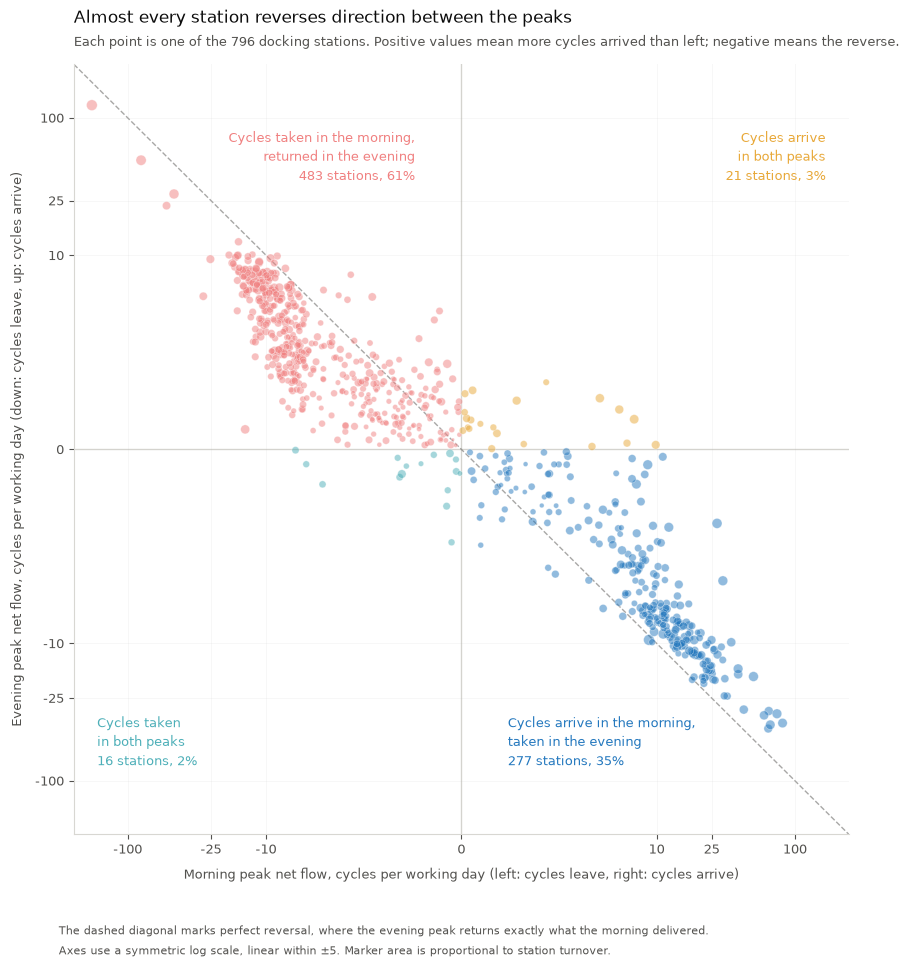

Stations reversing direction between peaks: 95.4%
Median magnitude reversed by the evening peak: 56.0%


In [71]:
# Figure 12: the commuting signature of each station
# Morning against evening peak net flow, one point per station. The
# anti-diagonal marks perfect reversal, where the evening returns exactly what
# the morning delivered. Distance from that line measures how far a station
# depends on something other than the return commute to balance itself.

# A symmetric log scale is used on both axes. Net flow spans three orders of
# magnitude, from under one cycle per day to 183 at Waterloo, and on a linear
# scale the four largest stations set the limits whilst the remaining 780
# collapse into an indistinguishable cluster. Symlog is linear near zero, where
# the sign matters and small values must not be exaggerated, and logarithmic
# beyond. Since both axes share the transform, the anti-diagonal stays straight
# and the geometric reading is preserved.

ARCH_COLOUR = {
    "Fills AM, empties PM": PALETTE[2],
    "Empties AM, fills PM": PALETTE[7],
    "Fills in both peaks": PALETTE[6],
    "Empties in both peaks": PALETTE[4],
}

# Plain-language descriptions for display. 
ARCH_DESC = {
    "Empties AM, fills PM":   "Cycles taken in the morning,\nreturned in the evening",
    "Fills AM, empties PM":   "Cycles arrive in the morning,\ntaken in the evening",
    "Fills in both peaks":    "Cycles arrive\nin both peaks",
    "Empties in both peaks":  "Cycles taken\nin both peaks",
}

LINTHRESH = 5
fig, ax = plt.subplots(figsize=(10, 10), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

lim = max(sf["am_per_day"].abs().max(), sf["pm_per_day"].abs().max()) * 1.35

ax.set_xscale("symlog", linthresh=LINTHRESH)
ax.set_yscale("symlog", linthresh=LINTHRESH)

ax.axhline(0, color=GRID, linewidth=1, zorder=1)
ax.axvline(0, color=GRID, linewidth=1, zorder=1)
ax.plot([-lim, lim], [lim, -lim], color=INK_SOFT, linewidth=1,
        linestyle="--", alpha=0.5, zorder=1)

# Stations, drawn largest group first so smaller groups remain visible
for arch in ["Empties AM, fills PM", "Fills AM, empties PM",
             "Fills in both peaks", "Empties in both peaks"]:
    m = sf["archetype"] == arch
    ax.scatter(sf.loc[m, "am_per_day"], sf.loc[m, "pm_per_day"],
               s=np.sqrt(sf.loc[m, "turnover"]) / 6.5,
               color=ARCH_COLOUR[arch], alpha=0.5, edgecolor=SURFACE,
               linewidth=0.4, zorder=3)

# Quadrant annotations
QUADRANTS = [
    ("Empties AM, fills PM", 0.44, 0.88, "right"), # upper left
    ("Fills AM, empties PM", 0.56, 0.12, "left"), # lower right
    ("Fills in both peaks", 0.97, 0.88, "right"), # upper right
    ("Empties in both peaks",0.03, 0.12, "left"), # lower left
]

n_total = len(sf)
for arch, fx, fy, ha in QUADRANTS:
    n = int((sf["archetype"] == arch).sum())
    ax.annotate(f"{ARCH_DESC[arch]}\n{n} stations, {n / n_total:.0%}",
                xy=(fx, fy), xycoords="axes fraction",
                ha=ha, va="center", fontsize=9,
                color=ARCH_COLOUR[arch], zorder=5, linespacing=1.5)

# Sparse ticks: a symlog axis with default minor ticks is visually noisy
ticks = [-100, -25, -10, 0, 10, 25, 100]
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_locator(FixedLocator(ticks))
    axis.set_major_formatter(FixedFormatter([str(t) for t in ticks]))
    axis.set_minor_locator(FixedLocator([]))

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xlabel("Morning peak net flow, cycles per working day "
              "(left: cycles leave, right: cycles arrive)",
              color=INK_SOFT, fontsize=9, labelpad=8)
ax.set_ylabel("Evening peak net flow, cycles per working day "
              "(down: cycles leave, up: cycles arrive)",
              color=INK_SOFT, fontsize=9, labelpad=8)

ax.set_title("Almost every station reverses direction between the peaks",
             loc="left", fontsize=12, color=INK, pad=30)
ax.annotate("Each point is one of the 796 docking stations. "
            "Positive values mean more cycles arrived than left; "
            "negative means the reverse.",
            xy=(0, 1.02), xycoords="axes fraction",
            ha="left", va="bottom", fontsize=9, color=INK_SOFT)

ax.grid(alpha=0.10, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

fig.text(0.11, 0.010,
         "The dashed diagonal marks perfect reversal, where the evening peak "
         "returns exactly what the morning delivered.",
         fontsize=8, color=INK_SOFT, ha="left")
fig.text(0.11, -0.010,
         f"Axes use a symmetric log scale, linear within \u00b1{LINTHRESH}. "
         "Marker area is proportional to station turnover.",
         fontsize=8, color=INK_SOFT, ha="left")

plt.savefig(FIG_DIR / "fig12_station_commute_signature.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

reverses = ((sf["am_net"] > 0) & (sf["pm_net"] < 0)) | \
           ((sf["am_net"] < 0) & (sf["pm_net"] > 0))
print(f"Stations reversing direction between peaks: {reverses.mean():.1%}")
print(f"Median magnitude reversed by the evening peak: "
      f"{sf.loc[reverses, 'reversal'].median():.1%}")

Stations mapped: 797 of 797


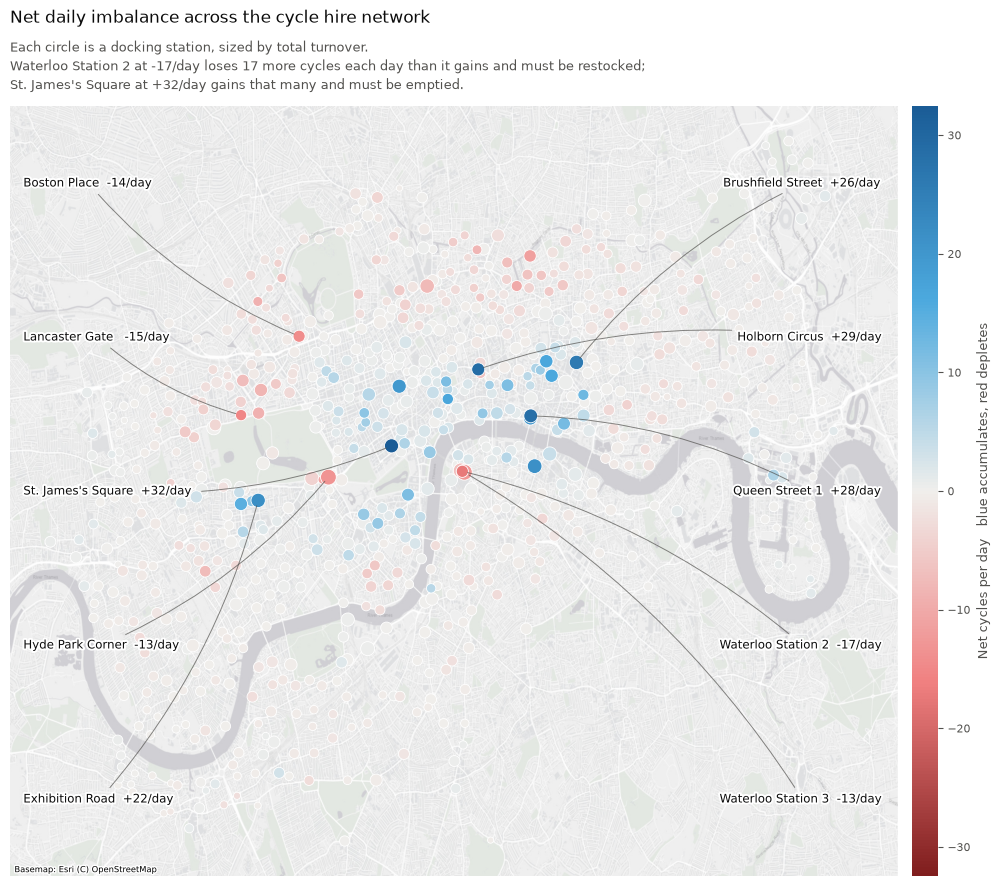

In [72]:
# Figure 13: net daily imbalance, on a basemap
# A muted basemap is used so that the Thames, the parks and the street grid
# provide orientation without competing with the diverging colour that carries
# the data. Coordinates are reprojected to Web Mercator, since tile services
# are served in that projection and mixing the two would misplace every point.

geo = sf.join(key_coords, how="inner")
n_days_all = clean["start_time"].dt.normalize().nunique()
geo["daily_net"] = geo["net"] / n_days_all
print(f"Stations mapped: {len(geo)} of {len(sf)}")

gdf = gpd.GeoDataFrame(
    geo.copy(),
    geometry=gpd.points_from_xy(geo["ref_lon"], geo["ref_lat"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

gdf = gdf.reindex(gdf["daily_net"].abs().sort_values().index)

DIVERGE = LinearSegmentedColormap.from_list(
    "net_flow", ["#7f1d1d", "#F08080", "#f0efec", "#4CA9DE", "#1A5C96"])
vmax = float(np.abs(gdf["daily_net"]).max())
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=SURFACE)

sc = ax.scatter(gdf.geometry.x, gdf.geometry.y,
                c=gdf["daily_net"], cmap=DIVERGE, norm=norm,
                s=np.sqrt(gdf["turnover"]) / 3.0,
                edgecolor="white", linewidth=0.6, zorder=3)

cx_ok = True
try:
    cx.add_basemap(ax, crs=gdf.crs, source=str(BASEMAP_WIDE),
                   attribution=BASEMAP_ATTRIBUTION,
                   attribution_size=6, zorder=1)
except Exception as exc:
    print(f"Basemap unavailable ({exc})")

# Labels are assigned to evenly spaced slots down the left and right margins,
# sorted by latitude, with leader lines back to their stations. Radial offsets
# work for a handful of points but fail here, since the ten most imbalanced
# stations are all in central London and have no room to spread into.
cx0 = gdf.geometry.x.median()
labelled = pd.concat([gdf.nlargest(5, "daily_net"),
                      gdf.nsmallest(5, "daily_net")])
labelled = labelled.assign(_x=labelled.geometry.x, _y=labelled.geometry.y)

for side, group in (("left",  labelled[labelled["_x"] < cx0]),
                    ("right", labelled[labelled["_x"] >= cx0])):
    group = group.sort_values("_y", ascending=False)
    if group.empty:
        continue
    slots = np.linspace(0.90, 0.10, len(group))
    fx = 0.015 if side == "left" else 0.985
    ha = "left" if side == "left" else "right"

    for (_, r), fy in zip(group.iterrows(), slots):
        ax.annotate(f"{str(r['station']).split(',')[0]}  {r['daily_net']:+.0f}/day",
                    xy=(r["_x"], r["_y"]), xycoords="data",
                    xytext=(fx, fy), textcoords="axes fraction",
                    ha=ha, va="center", fontsize=8.5, color=INK, zorder=6,
                    path_effects=[pe.withStroke(linewidth=2.8, foreground="white")],
                    arrowprops=dict(arrowstyle="-", color=INK_SOFT,
                                    linewidth=0.7, shrinkA=2, shrinkB=4,
                                    alpha=0.7,
                                    connectionstyle="arc3,rad=0.12"))

ax.set_xticks([])
ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

lo = gdf.nsmallest(1, "daily_net").iloc[0]
hi = gdf.nlargest(1, "daily_net").iloc[0]
subtitle = (
    "Each circle is a docking station, sized by total turnover.\n"
    f"{str(lo['station']).split(',')[0]} at {lo['daily_net']:+.0f}/day loses "
    f"{abs(lo['daily_net']):.0f} more cycles each day than it gains and must be restocked; \n"
    f"{str(hi['station']).split(',')[0]} at {hi['daily_net']:+.0f}/day gains that many "
    "and must be emptied."
)

ax.set_title("Net daily imbalance across the cycle hire network",
             loc="left", fontsize=12, color=INK, pad=60)

cbar = fig.colorbar(sc, ax=ax, pad=0.015, fraction=0.030, aspect=30)
cbar.set_label("Net cycles per day   blue accumulates, red depletes",
               color=INK_SOFT, fontsize=9)
cbar.ax.tick_params(colors=INK_SOFT, labelsize=8)
cbar.outline.set_visible(False)

ax.annotate(subtitle, xy=(0, 1.015), xycoords="axes fraction",
            ha="left", va="bottom", fontsize=9, color=INK_SOFT,
            linespacing=1.5)

plt.savefig(FIG_DIR / "fig13_net_flow_map.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

Figure 13 maps net daily imbalance across all 797 stations. Blue accumulation clusters in the City, Holborn, and Soho, the employment core, whilst red depletion concentrates in residential and transit-adjacent areas to the west (Lancaster Gate, Hyde Park Corner) and south (Waterloo). The spatial pattern confirms that structural imbalance follows London's commuting geography: cycles flow into the employment core each morning and are not returned in sufficient numbers to restore the distribution without intervention.

**RQ3: Corridor and centrality analysis: Which origin-destination pairs and stations are structurally central?**

Volume alone does not reveal how a network is organised. A station can process thousands of journeys each day whilst remaining locally contained, or carry modest traffic whilst sitting on the only path connecting two otherwise separated parts of the network. RQ3 constructs a weighted origin–destination graph from the full journey record and applies network centrality analysis to distinguish these roles. Degree and strength capture local volume; betweenness centrality captures structural position, a station's presence on paths between other station pairs. Ego network analysis then zooms into the two most instructive cases to show, concretely, what different centrality profiles look like on the ground.

In [73]:
# Build the origin-destination graph (Topic 8, networks)
# Journeys are aggregated into station-to-station pairs. The graph is treated
# as undirected, since a pair connects two places regardless of which way any
# given journey ran, and the directional question was already answered in RQ2.
# Round trips are excluded: a self-loop connects a station to itself and
# carries no information about network structure.

MIN_TRIPS = 50   # over 17 months, roughly one journey per fortnight

od = clean.dropna(subset=["start_station_key", "end_station_key"]).copy()
od = od[od["start_station_key"] != od["end_station_key"]]

a = od["start_station_key"].astype("int64").to_numpy()
b = od["end_station_key"].astype("int64").to_numpy()
lo, hi = np.minimum(a, b), np.maximum(a, b)

pairs = (pd.DataFrame({"u": lo, "v": hi})
         .value_counts().rename("trips").reset_index())

print(f"Journeys used: {len(od):,}")
print(f"Distinct undirected pairs: {len(pairs):,}")
print(f"Possible pairs: {796 * 795 // 2:,}")
print(f"Observed density: {len(pairs) / (796 * 795 / 2):.1%}")

kept = pairs[pairs["trips"] >= MIN_TRIPS]
print(f"\nPairs with at least {MIN_TRIPS} journeys: {len(kept):,} "
      f"({len(kept) / len(pairs):.1%} of pairs, "
      f"{kept['trips'].sum() / pairs['trips'].sum():.1%} of journeys)")

G = nx.Graph()
G.add_nodes_from(flow.index.astype("int64"))
for u, v, w in kept.itertuples(index=False):
    G.add_edge(u, v, trips=w, cost=1.0 / w)

print(f"\nGraph: {G.number_of_nodes()} nodes, {G.number_of_edges():,} edges")
print(f"Density: {nx.density(G):.4f}")
print(f"Components: {nx.number_connected_components(G)}")

giant = max(nx.connected_components(G), key=len)
print(f"Largest component: {len(giant)} nodes "
      f"({len(giant) / G.number_of_nodes():.1%})")

isolated = [n for n in G.nodes if G.degree(n) == 0]
print(f"Isolated nodes: {len(isolated)}")

Journeys used: 11,975,683
Distinct undirected pairs: 263,181
Possible pairs: 316,410
Observed density: 83.2%

Pairs with at least 50 journeys: 57,189 (21.7% of pairs, 78.9% of journeys)

Graph: 797 nodes, 57,189 edges
Density: 0.1803
Components: 1
Largest component: 797 nodes (100.0%)
Isolated nodes: 0


The graph contains 797 nodes and 57,189 edges after applying the 50-journey minimum threshold, retaining 78.9% of journeys whilst removing low-confidence pairs. The raw observed density is 83.2%, indicating that almost every station pair has been used at least once across 17 months; after filtering, the retained density is 0.1803. The graph is fully connected; one component and zero isolated nodes, confirming that every station participates in the network without structural disconnection.

In [74]:
# The most travelled station pairs
name = flow["station"]
top = kept.nlargest(15, "trips").copy()
top["from"] = top["u"].map(name)
top["to"] = top["v"].map(name)
top["per_day"] = top["trips"] / clean["start_time"].dt.normalize().nunique()
top["share"] = top["trips"] / pairs["trips"].sum()

print("Fifteen most travelled station pairs:\n")
print(top[["from", "to", "trips", "per_day", "share"]]
      .assign(share=lambda d: d["share"].map("{:.3%}".format))
      .round(1).to_string(index=False))

print(f"\nTop 15 pairs account for "
      f"{top['trips'].sum() / pairs['trips'].sum():.2%} of all journeys")
print(f"Top 100 pairs account for "
      f"{pairs.nlargest(100, 'trips')['trips'].sum() / pairs['trips'].sum():.2%}")

Fifteen most travelled station pairs:

                                  from                                        to  trips  per_day  share
                    Ackroyd Drive, Bow                   Maplin Street, Mile End   9813  19.0000 0.082%
             Monier Road, Hackney Wick              Stratford Station, Stratford   8129  15.8000 0.068%
           Hyde Park Corner, Hyde Park                    Albert Gate, Hyde Park   7792  15.1000 0.065%
           Hyde Park Corner, Hyde Park       Black Lion Gate, Kensington Gardens   6341  12.3000 0.053%
          Southwick Street, Paddington            Exhibition Road, Knightsbridge   5669  11.0000 0.047%
       Palace Gate, Kensington Gardens       Black Lion Gate, Kensington Gardens   5643  10.9000 0.047%
           Hyde Park Corner, Hyde Park            Serpentine Car Park, Hyde Park   5038   9.8000 0.042%
           Hyde Park Corner, Hyde Park              Triangle Car Park, Hyde Park   4912   9.5000 0.041%
 Barons Court Station, We

Demand is highly dispersed: the top 15 pairs account for only 0.70% of all journeys and the top 100 for just 2.58%. The busiest corridors split into two types: intra-park leisure circuits (Hyde Park Corner, Serpentine Car Park, Black Lion Gate) and short residential connectors in outer clusters (Bow, Hackney Wick, Wapping, Clapham). No central commuter corridor appears in the top 15, commuter demand disperses across many pairs rather than concentrating on a few, making volume a poor proxy for structural centrality.

In [75]:
# Which stations matter structurally?
# An important caveat on interpretation. The edges here are direct journeys,
# not routes: nobody cycles through an intermediate dock. Betweenness therefore
# does not measure physical throughput. It measures a station's position in the
# pattern of exchanges, identifying places whose connections link parts of the
# network that otherwise exchange little with each other.

# Edge cost is the reciprocal of journeys, so a heavily travelled pair counts
# as a short step and lightly travelled pairs as long ones.

strength = pd.Series(dict(G.degree(weight="trips")), name="strength")
degree = pd.Series(dict(G.degree()), name="degree")
btw = pd.Series(nx.betweenness_centrality(G, weight="cost", normalized=True),
                name="betweenness")
eig = pd.Series(nx.eigenvector_centrality(G, weight="trips", max_iter=1000),
                name="eigenvector")

cen = pd.concat([strength, degree, btw, eig], axis=1)
cen["station"] = cen.index.map(name)
cen = cen.join(flow[["turnover"]], how="left")

for col in ("strength", "degree", "betweenness", "eigenvector"):
    cen[f"rank_{col}"] = cen[col].rank(ascending=False)

print("\nTen highest by weighted degree, that is by raw volume:")
print(cen.nlargest(10, "strength")[
    ["station", "strength", "degree", "betweenness", "rank_betweenness"]
].round(4).to_string(index=False))

print("\nTen highest by betweenness, that is by structural position:")
print(cen.nlargest(10, "betweenness")[
    ["station", "betweenness", "degree", "strength", "rank_strength"]
].round(4).to_string(index=False))

# The interesting stations are those where the two disagree
cen["rank_gap"] = cen["rank_strength"] - cen["rank_betweenness"]
print("\nStations far more central than their volume suggests:")
print(cen.nlargest(10, "rank_gap")[
    ["station", "rank_strength", "rank_betweenness", "rank_gap", "degree"]
].round(0).to_string(index=False))

print(f"\nCorrelation, volume against betweenness: "
      f"{cen['strength'].corr(cen['betweenness']):+.3f}")
print(f"Spearman rank correlation: "
      f"{cen['strength'].corr(cen['betweenness'], method='spearman'):+.3f}")


Ten highest by weighted degree, that is by raw volume:
                            station  strength  degree  betweenness  rank_betweenness
       Waterloo Station 3, Waterloo    145199     296       0.3757            1.0000
       Waterloo Station 1, Waterloo    115111     401       0.0195           41.0000
          Hop Exchange, The Borough    102512     444       0.0597           12.0000
  Wormwood Street, Liverpool Street    101155     416       0.1251            2.0000
        Hyde Park Corner, Hyde Park     95531     313       0.0601           11.0000
         Argyle Street, Kings Cross     94836     398       0.0649            9.0000
Brushfield Street, Liverpool Street     94808     377       0.0921            5.0000
     Exhibition Road, Knightsbridge     92181     399       0.1080            3.0000
    Duke Street Hill, London Bridge     88896     387       0.0409           16.0000
    St. James's Square, St. James's     87667     486       0.0761            6.0000

Ten high

Volume and betweenness centrality agree moderately (Pearson r=+0.631, Spearman=+0.697) but diverge in revealing ways. 
- Waterloo Station 3 is the clear outlier: ranked first by both volume and betweenness (score 0.376), it acts as a gateway between south London and the rest of the network rather than merely a busy local hub. 
- Wormwood Street and Exhibition Road rank 2nd and 3rd by betweenness despite ranking 4th and 8th by volume, indicating genuine structural bridging roles. 
- The rank-gap table exposes a different class of station: low-volume peripheral stations such as Abingdon Villas, Spindrift Avenue, and Putney that sit on the few corridors connecting outer residential clusters to the core, giving them outsized structural importance relative to their traffic.

In [76]:
# Are structurally central stations peripheral in geography?
# The rank-gap hypothesis: stations on the network's geographic edge connect
# otherwise weakly linked outer clusters to the core, giving them betweenness
# scores disproportionate to their traffic volume.

cen_geo = cen.join(key_coords, how="inner")
c_lat, c_lon = cen_geo["ref_lat"].median(), cen_geo["ref_lon"].median()
cen_geo["km_from_centre"] = haversine_m(
    cen_geo["ref_lat"], cen_geo["ref_lon"],
    np.full(len(cen_geo), c_lat), np.full(len(cen_geo), c_lon)) / 1000

print(f"Stations: {len(cen_geo)}")
print(f"Distance from centre: median {cen_geo['km_from_centre'].median():.1f} km, "
      f"max {cen_geo['km_from_centre'].max():.1f} km\n")

print(f"Rank gap against distance from centre: "
      f"{cen_geo['rank_gap'].corr(cen_geo['km_from_centre']):+.3f}")
print(f"Volume against distance: "
      f"{cen_geo['strength'].corr(cen_geo['km_from_centre']):+.3f}")
print(f"Betweenness against distance: "
      f"{cen_geo['betweenness'].corr(cen_geo['km_from_centre']):+.3f}")

cen_geo["ring"] = pd.qcut(cen_geo["km_from_centre"], 4,
                          labels=["inner", "inner middle",
                                  "outer middle", "outer"])
print("\nBy distance ring:")
print(cen_geo.groupby("ring", observed=True)
      .agg(stations=("rank_gap", "size"),
           mean_rank_gap=("rank_gap", "mean"),
           mean_degree=("degree", "mean"),
           mean_strength=("strength", "mean")).round(1).to_string())

Stations: 797
Distance from centre: median 3.7 km, max 9.3 km

Rank gap against distance from centre: +0.390
Volume against distance: -0.262
Betweenness against distance: -0.076

By distance ring:
              stations  mean_rank_gap  mean_degree  mean_strength
ring                                                             
inner              200       -70.6000     185.2000     27470.7000
inner middle       199       -42.4000     166.9000     27513.0000
outer middle       199         8.0000     131.4000     22531.0000
outer              199       105.4000      90.3000     17256.2000


The rank-gap hypothesis is confirmed. The gap between betweenness rank and volume rank increases monotonically with distance from the network centre (r=+0.390): inner stations are on average ranked 70.6 positions lower by betweenness than by volume, whilst outer stations are ranked 105.4 positions higher. Volume falls steadily with distance (r=-0.262) whilst betweenness is nearly distance-independent (r=-0.076), meaning that peripheral stations maintain structural importance despite lower traffic. Outer-ring stations connect isolated residential clusters to the core through the few available high-frequency corridors, giving them betweenness scores that their local volume alone cannot explain.

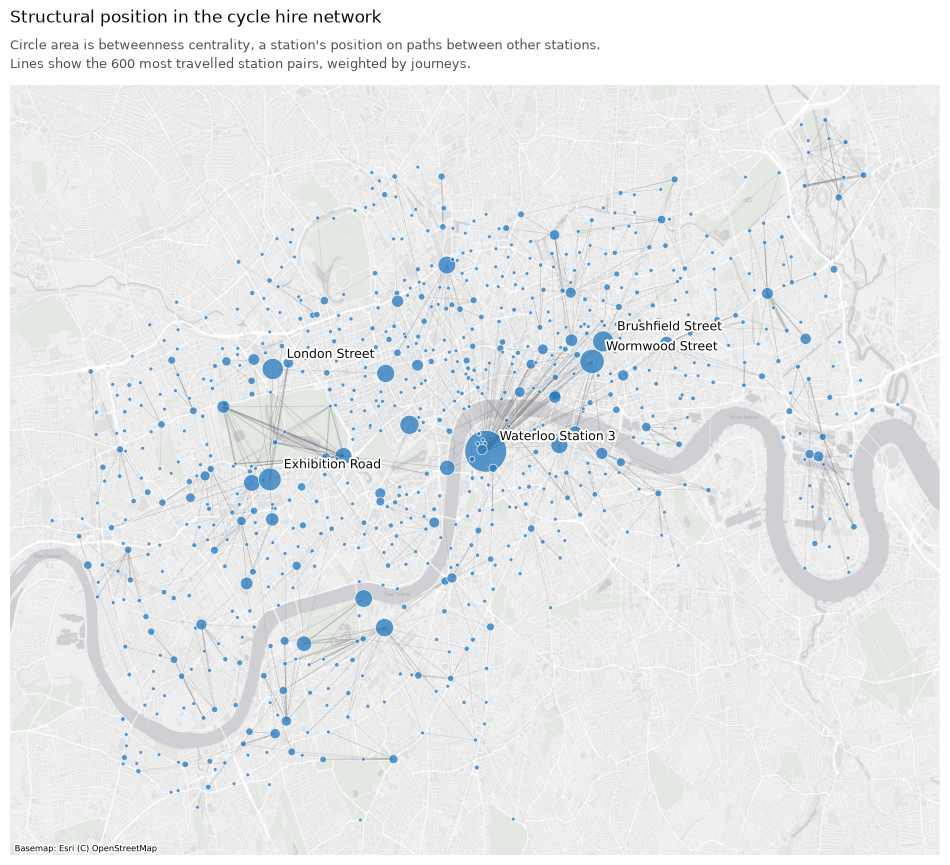

In [77]:
# Figure 14: the network's structure over London
# Edges are drawn for the strongest pairs only, since 57,102 lines would render
# as a solid block. Node area encodes betweenness rather than volume, so the
# figure shows structural position, which is what the question asks about.

TOP_EDGES = 600
e = kept.nlargest(TOP_EDGES, "trips")

pos = key_coords.copy()
gnodes = cen.join(pos, how="inner")

gp = gpd.GeoDataFrame(
    gnodes, geometry=gpd.points_from_xy(gnodes["ref_lon"], gnodes["ref_lat"]),
    crs="EPSG:4326").to_crs(epsg=3857)
xy = {k: (p.x, p.y) for k, p in gp.geometry.items()}

fig, ax = plt.subplots(figsize=(12, 10), facecolor=SURFACE)

segs = [[xy[u], xy[v]] for u, v in zip(e["u"], e["v"]) if u in xy and v in xy]
widths = (e["trips"] / e["trips"].max() * 2.2).clip(lower=0.25)

ax.add_collection(LineCollection(segs, colors=INK_SOFT, linewidths=widths,
                                 alpha=0.28, zorder=2))

sc = ax.scatter(gp.geometry.x, gp.geometry.y,
                s=gp["betweenness"] / gp["betweenness"].max() * 900 + 8,
                c=PALETTE[2], alpha=0.75, edgecolor="white",
                linewidth=0.6, zorder=3)

try:
    cx.add_basemap(ax, crs=gp.crs, source=str(BASEMAP_WIDE),
                   attribution=BASEMAP_ATTRIBUTION,
                   attribution_size=6, zorder=1)
except Exception as exc:
    print(f"Basemap unavailable ({exc})")

for _, r in gp.nlargest(5, "betweenness").iterrows():
    ax.annotate(str(r["station"]).split(",")[0],
                xy=(r.geometry.x, r.geometry.y),
                xytext=(10, 8), textcoords="offset points",
                fontsize=9, color=INK, zorder=6,
                path_effects=[pe.withStroke(linewidth=2.8, foreground="white")])

ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Structural position in the cycle hire network",
             loc="left", fontsize=12, color=INK, pad=45)
ax.annotate(f"Circle area is betweenness centrality, a station's position on paths "
            f"between other stations.\nLines show the {TOP_EDGES} most travelled "
            "station pairs, weighted by journeys.",
            xy=(0, 1.015), xycoords="axes fraction", ha="left", va="bottom",
            fontsize=9, color=INK_SOFT, linespacing=1.5)

plt.savefig(FIG_DIR / "fig14_network_structure.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

Figure 14 maps betweenness centrality (circle area) against the 600 highest-volume corridors (line weight). Waterloo Station 3 is visually dominant, with a node area several times larger than any other station, confirming its role as the primary gateway between south London and the central network. The Liverpool Street cluster (Wormwood Street, Brushfield Street) and Exhibition Road form secondary structural hubs. Edge density is highest in the City and West End, thinning sharply toward the periphery where stations remain connected but through fewer, lower-frequency corridors.

In [78]:
# Extents for the two ego-network figures
# Each hub gets its own raster. 

EGO_TOP_N = 40
EGO_PAD_DEG = 0.004   # roughly 400 m, matching the figures' visual margin

def ego_bounds(hub_name, top_n=EGO_TOP_N, pad=EGO_PAD_DEG):
    """
    Compute the WGS84 bounding box enclosing a hub and its strongest neighbours.

    Derived from the nodes the figure actually plots, so the box stays correct
    if top_n changes or a different hub is chosen.

    Parameters
    ----------
    hub_name : str
        Full station name as it appears in the `name` Series.
    top_n : int, optional
        Number of strongest neighbours included, matching the figure.
    pad : float, optional
        Margin in decimal degrees added on all four sides.

    Returns
    -------
    tuple of float
        (west, south, east, north) in decimal degrees.
    """
    h = int(name[name == hub_name].index[0])

    inc_ = kept[(kept["u"] == h) | (kept["v"] == h)].copy()
    inc_["other"] = np.where(inc_["u"] == h, inc_["v"], inc_["u"])
    keys = set(inc_.nlargest(top_n, "trips")["other"].tolist()) | {h}

    pts = key_coords.loc[sorted(keys & set(key_coords.index))]
    return (pts["ref_lon"].min() - pad, pts["ref_lat"].min() - pad,
            pts["ref_lon"].max() + pad, pts["ref_lat"].max() + pad)


for hub_name, path in [("Waterloo Station 3, Waterloo", BASEMAP_WATERLOO),
                       ("Hyde Park Corner, Hyde Park", BASEMAP_HYDEPARK)]:
    b = ego_bounds(hub_name)
    print(f"\n{hub_name.split(',')[0]}")
    print(f"  bounds {tuple(round(v, 4) for v in b)}")
    print(f"  span   {(b[2] - b[0]) * 69:.1f} km east-west, "
          f"{(b[3] - b[1]) * 69:.1f} km north-south")
    fetch_basemap(path, b, zoom=16)


Waterloo Station 3
  bounds (np.float64(-0.1421), np.float64(51.4998), np.float64(-0.0695), np.float64(51.5269))
  span   5.0 km east-west, 1.9 km north-south
fetching basemap_waterloo_z16.tif at zoom 16 ...
written  basemap_waterloo_z16.tif  (33.0 MB), shape (2304, 3584, 4)

Hyde Park Corner
  bounds (np.float64(-0.2004), np.float64(51.4925), np.float64(-0.1192), np.float64(51.5219))
  span   5.6 km east-west, 2.0 km north-south
fetching basemap_hydepark_z16.tif at zoom 16 ...
written  basemap_hydepark_z16.tif  (37.8 MB), shape (2304, 4096, 4)


Waterloo Station 3, Waterloo
 - Degree: 296
 - Total journeys: 145,199
 - Betweenness: 0.3757
 - Share of its journeys in top 40 links: 50.0%

Ten strongest connections:
                            station  trips
        Newgate Street , St. Paul's   4278
                    Cheapside, Bank   3761
  Wormwood Street, Liverpool Street   3204
               Queen Street 1, Bank   3161
  Queen Victoria Street, St. Paul's   2750
  Finsbury Circus, Liverpool Street   2687
    Blackfriars Station, St. Paul's   2661
Brushfield Street, Liverpool Street   2296
               Queen Street 2, Bank   2045
        Godliman Street, St. Paul's   1969

Edges among the 40 neighbours: 582 of 780 possible (75%)


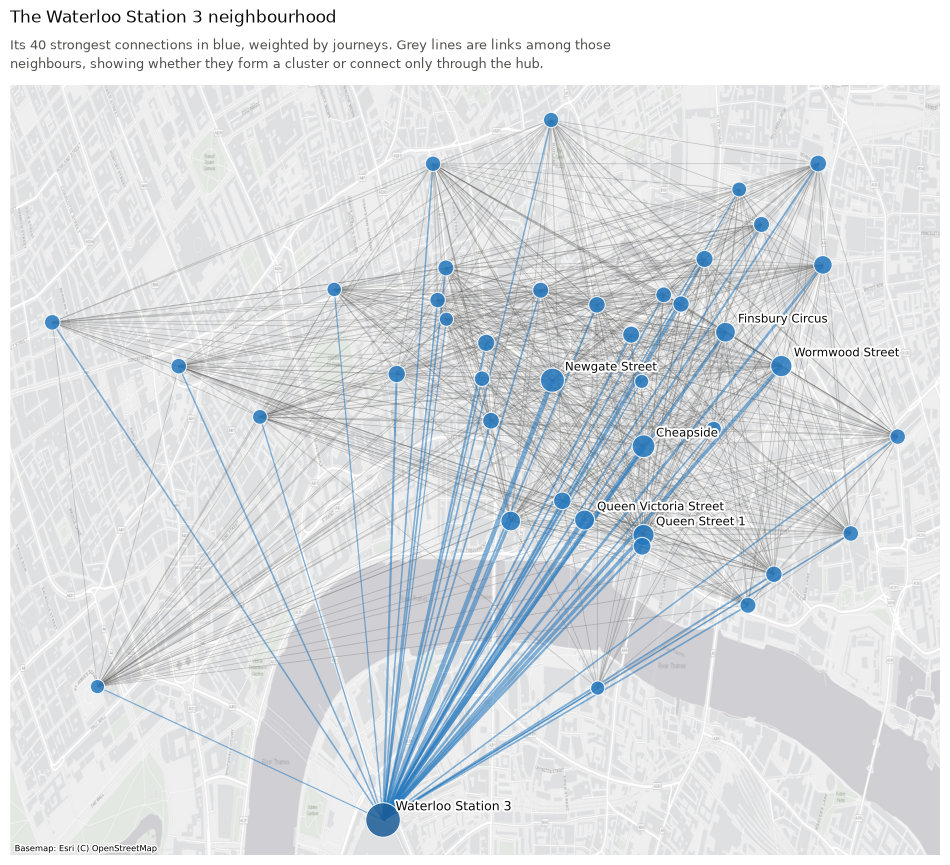


Neighbours north of the hub: 40 of 40
Share of its journeys to the north: 100.0%


In [79]:
# Figure 15: the Waterloo Station 3 ego network
# Waterloo Station 3 carries a betweenness of 0.376, three times the next
# station. This isolates its neighbourhood to show why. Its strongest
# connections are drawn, together with the edges among those neighbours, so
# that a hub radiating to unconnected places can be distinguished from one
# embedded in a cluster.

HUB_NAME = "Waterloo Station 3, Waterloo"
TOP_NEIGHBOURS = 40

hub = int(name[name == HUB_NAME].index[0])

# Edges incident on the hub, strongest first
inc = kept[(kept["u"] == hub) | (kept["v"] == hub)].copy()
inc["other"] = np.where(inc["u"] == hub, inc["v"], inc["u"])
inc = inc.nlargest(TOP_NEIGHBOURS, "trips")
nbrs = inc["other"].tolist()

print(f"{HUB_NAME}")
print(f" - Degree: {G.degree(hub)}")
print(f" - Total journeys: {G.degree(hub, weight='trips'):,}")
print(f" - Betweenness: {cen.loc[hub, 'betweenness']:.4f}")
print(f" - Share of its journeys in "
      f"top {TOP_NEIGHBOURS} links: {inc['trips'].sum() / G.degree(hub, weight='trips'):.1%}\n")

print(f"Ten strongest connections:")
tbl = inc.head(10).assign(station=lambda d: d["other"].map(name))
print(tbl[["station", "trips"]].to_string(index=False))

# Positions
sub_ids = [hub] + nbrs
sub = cen.loc[sub_ids].join(key_coords, how="inner")
gsub = gpd.GeoDataFrame(
    sub, geometry=gpd.points_from_xy(sub["ref_lon"], sub["ref_lat"]),
    crs="EPSG:4326").to_crs(epsg=3857)
pxy = {k: (p.x, p.y) for k, p in gsub.geometry.items()}

# Edges among the neighbours themselves, to reveal whether they form a cluster
among = kept[kept["u"].isin(nbrs) & kept["v"].isin(nbrs)]
print(f"\nEdges among the {len(nbrs)} neighbours: {len(among):,} "
      f"of {len(nbrs) * (len(nbrs) - 1) // 2:,} possible "
      f"({len(among) / (len(nbrs) * (len(nbrs) - 1) / 2):.0%})")

fig, ax = plt.subplots(figsize=(12, 10), facecolor=SURFACE)

# Neighbour-to-neighbour edges, recessive
seg_among = [[pxy[u], pxy[v]] for u, v in zip(among["u"], among["v"])
             if u in pxy and v in pxy]
ax.add_collection(LineCollection(seg_among, colors=INK_SOFT, linewidths=0.6,
                                 alpha=0.25, zorder=2))

# Hub edges, emphasised and weighted by journeys
seg_hub = [[pxy[hub], pxy[o]] for o in nbrs if o in pxy]
w_hub = (inc["trips"] / inc["trips"].max() * 3.4).clip(lower=0.5)
ax.add_collection(LineCollection(seg_hub, colors=PALETTE[2], linewidths=w_hub,
                                 alpha=0.55, zorder=3))

trips_to_hub = inc.set_index("other")["trips"]
sizes = gsub.index.map(lambda k: 620 if k == hub
                       else 40 + trips_to_hub.get(k, 0) / trips_to_hub.max() * 260)
cols = [PALETTE[3] if k == hub else PALETTE[2] for k in gsub.index]

ax.scatter(gsub.geometry.x, gsub.geometry.y, s=sizes, c=cols,
           alpha=0.85, edgecolor="white", linewidth=0.8, zorder=4)

try:
    cx.add_basemap(ax, crs=gsub.crs, source=str(BASEMAP_WATERLOO),
                   attribution=BASEMAP_ATTRIBUTION,
                   attribution_size=6, zorder=1)
except Exception as exc:
    print(f"Basemap unavailable ({exc})")

for k in [hub] + inc.head(6)["other"].tolist():
    if k not in pxy:
        continue
    ax.annotate(str(name.get(k, k)).split(",")[0],
                xy=pxy[k], xytext=(9, 7), textcoords="offset points",
                fontsize=9 if k == hub else 8.5,
                color=INK, zorder=6,
                path_effects=[pe.withStroke(linewidth=2.8, foreground="white")])

ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

ax.set_title(f"The {HUB_NAME.split(',')[0]} neighbourhood",
             loc="left", fontsize=12, color=INK, pad=45)
ax.annotate(f"Its {TOP_NEIGHBOURS} strongest connections in blue, weighted by journeys. "
            "Grey lines are links among those\nneighbours, showing whether they form a "
            "cluster or connect only through the hub.",
            xy=(0, 1.015), xycoords="axes fraction", ha="left", va="bottom",
            fontsize=9, color=INK_SOFT, linespacing=1.5)

plt.savefig(FIG_DIR / "fig15_waterloo_ego.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

# Does its role involve crossing the river?
hub_lat = key_coords.loc[hub, "ref_lat"]
nb_lat = key_coords.reindex(nbrs)["ref_lat"]
north = (nb_lat > hub_lat)
w = trips_to_hub.reindex(nb_lat.index)
print(f"\nNeighbours north of the hub: {north.sum()} of {len(nb_lat)}")
print(f"Share of its journeys to the north: {w[north.values].sum() / w.sum():.1%}")

All 40 of Waterloo Station 3's strongest neighbours lie north of the station, and 100% of its top-corridor journeys cross the Thames to City and St Paul's destinations. Its neighbours are themselves densely connected, 582 of 780 possible edges exist (75%), confirming that Waterloo Station 3 connects into a tight City cluster rather than simply radiating to isolated stations. Its betweenness arises from being the sole high-frequency crossing point between the south bank and that cluster, not from high local connectivity alone.

Hyde Park Corner, Hyde Park
 - Degree: 313
 - Total journeys: 95,531
 - Betweenness: 0.0601
 - Share of its journeys in top 40 links: 61.5%

Ten strongest connections:
                            station  trips
             Albert Gate, Hyde Park   7792
Black Lion Gate, Kensington Gardens   6341
     Serpentine Car Park, Hyde Park   5038
       Triangle Car Park, Hyde Park   4912
   Queen's Gate, Kensington Gardens   3986
              Park Lane , Hyde Park   3833
    Palace Gate, Kensington Gardens   3209
          Bayswater Road, Hyde Park   2076
              Green Street, Mayfair   1461
         Wellington Arch, Hyde Park   1408

Edges among the 40 neighbours: 733 of 780 possible (94%)


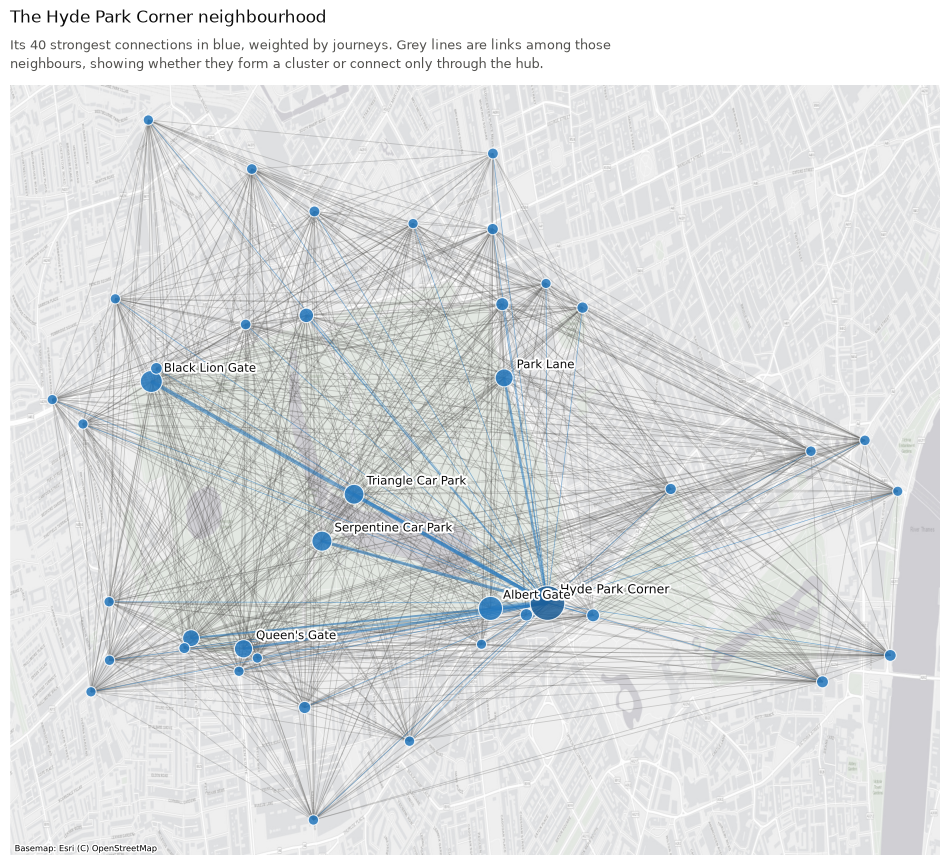

In [80]:
# Figure 16: Hyde Park Corner, a hub embedded in a cluster

HUB_NAME = "Hyde Park Corner, Hyde Park"
TOP_NEIGHBOURS = 40

hub = int(name[name == HUB_NAME].index[0])

# Edges incident on the hub, strongest first
inc = kept[(kept["u"] == hub) | (kept["v"] == hub)].copy()
inc["other"] = np.where(inc["u"] == hub, inc["v"], inc["u"])
inc = inc.nlargest(TOP_NEIGHBOURS, "trips")
nbrs = inc["other"].tolist()

print(f"{HUB_NAME}")
print(f" - Degree: {G.degree(hub)}")
print(f" - Total journeys: {G.degree(hub, weight='trips'):,}")
print(f" - Betweenness: {cen.loc[hub, 'betweenness']:.4f}")
print(f" - Share of its journeys in "
      f"top {TOP_NEIGHBOURS} links: {inc['trips'].sum() / G.degree(hub, weight='trips'):.1%}\n")

print(f"Ten strongest connections:")
tbl = inc.head(10).assign(station=lambda d: d["other"].map(name))
print(tbl[["station", "trips"]].to_string(index=False))

# Positions
sub_ids = [hub] + nbrs
sub = cen.loc[sub_ids].join(key_coords, how="inner")
gsub = gpd.GeoDataFrame(
    sub, geometry=gpd.points_from_xy(sub["ref_lon"], sub["ref_lat"]),
    crs="EPSG:4326").to_crs(epsg=3857)
pxy = {k: (p.x, p.y) for k, p in gsub.geometry.items()}

# Edges among the neighbours themselves, to reveal whether they form a cluster
among = kept[kept["u"].isin(nbrs) & kept["v"].isin(nbrs)]
print(f"\nEdges among the {len(nbrs)} neighbours: {len(among):,} "
      f"of {len(nbrs) * (len(nbrs) - 1) // 2:,} possible "
      f"({len(among) / (len(nbrs) * (len(nbrs) - 1) / 2):.0%})")

fig, ax = plt.subplots(figsize=(12, 10), facecolor=SURFACE)

# Neighbour-to-neighbour edges, recessive
seg_among = [[pxy[u], pxy[v]] for u, v in zip(among["u"], among["v"])
             if u in pxy and v in pxy]
ax.add_collection(LineCollection(seg_among, colors=INK_SOFT, linewidths=0.6,
                                 alpha=0.25, zorder=2))

# Hub edges, emphasised and weighted by journeys
seg_hub = [[pxy[hub], pxy[o]] for o in nbrs if o in pxy]
w_hub = (inc["trips"] / inc["trips"].max() * 3.4).clip(lower=0.5)
ax.add_collection(LineCollection(seg_hub, colors=PALETTE[2], linewidths=w_hub,
                                 alpha=0.55, zorder=3))

trips_to_hub = inc.set_index("other")["trips"]
sizes = gsub.index.map(lambda k: 620 if k == hub
                       else 40 + trips_to_hub.get(k, 0) / trips_to_hub.max() * 260)
cols = [PALETTE[3] if k == hub else PALETTE[2] for k in gsub.index]

ax.scatter(gsub.geometry.x, gsub.geometry.y, s=sizes, c=cols,
           alpha=0.85, edgecolor="white", linewidth=0.8, zorder=4)

try:
    cx.add_basemap(ax, crs=gsub.crs, source=str(BASEMAP_HYDEPARK),
                   attribution=BASEMAP_ATTRIBUTION,
                   attribution_size=6, zorder=1)
except Exception as exc:
    print(f"Basemap unavailable ({exc})")

for k in [hub] + inc.head(6)["other"].tolist():
    if k not in pxy:
        continue
    ax.annotate(str(name.get(k, k)).split(",")[0],
                xy=pxy[k], xytext=(9, 7), textcoords="offset points",
                fontsize=9 if k == hub else 8.5,
                color=INK, zorder=6,
                path_effects=[pe.withStroke(linewidth=2.8, foreground="white")])

ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

ax.set_title(f"The {HUB_NAME.split(',')[0]} neighbourhood",
             loc="left", fontsize=12, color=INK, pad=45)
ax.annotate(f"Its {TOP_NEIGHBOURS} strongest connections in blue, weighted by journeys. "
            "Grey lines are links among those\nneighbours, showing whether they form a "
            "cluster or connect only through the hub.",
            xy=(0, 1.015), xycoords="axes fraction", ha="left", va="bottom",
            fontsize=9, color=INK_SOFT, linespacing=1.5)

plt.savefig(FIG_DIR / "fig16_hyde_park_ego.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

Hyde Park Corner contrasts sharply with Waterloo Station 3. Its neighbours are overwhelmingly other Hyde Park and Kensington Gardens stations, and 94% of possible neighbour-to-neighbour edges exist, the grey lines in the figure form an almost-complete graph. It is embedded in a tight leisure cluster rather than bridging separate sub-networks, which is why its betweenness (0.060) is six times lower than Waterloo Station 3 (0.376) despite comparable degree. High volume and high structural centrality are not the same thing.

In [81]:
# Hub profile, as a self-contained function
# Every input is derived from the argument, so the result cannot depend on
# whatever a previous cell happened to leave bound. The recurring alternative,
# a block that reads variables set elsewhere, has silently produced stale
# output more than once in this notebook.

def hub_profile(hub_name, top_n=40):
    """
    Compute structural and geographic statistics for one station's neighbourhood.

    Parameters
    ----------
    hub_name : str
        Full station name as it appears in the `name` Series.
    top_n : int, optional
        Number of strongest neighbours to include. Default 40.

    Returns
    -------
    dict
        Keys: station, degree, journeys, betweenness, top_share,
        nbr_interconnect, median_link_km, under_1km, under_2km,
        furthest_km, northward.
    """
    h = int(name[name == hub_name].index[0])

    inc_ = kept[(kept["u"] == h) | (kept["v"] == h)].copy()
    inc_["other"] = np.where(inc_["u"] == h, inc_["v"], inc_["u"])
    inc_ = inc_.nlargest(top_n, "trips")
    nbrs_ = inc_["other"].tolist()

    among_ = kept[kept["u"].isin(nbrs_) & kept["v"].isin(nbrs_)]
    possible = len(nbrs_) * (len(nbrs_) - 1) / 2

    ok = [o for o in nbrs_ if o in key_coords.index]
    d = haversine_m(
        np.full(len(ok), key_coords.loc[h, "ref_lat"]),
        np.full(len(ok), key_coords.loc[h, "ref_lon"]),
        key_coords.loc[ok, "ref_lat"].to_numpy(),
        key_coords.loc[ok, "ref_lon"].to_numpy()) / 1000
    w = inc_.set_index("other").loc[ok, "trips"].to_numpy()

    order = np.argsort(d)
    d_s, w_s = d[order], w[order]
    med_km = float(np.interp(0.5, w_s.cumsum() / w_s.sum(), d_s))

    north = key_coords.loc[ok, "ref_lat"].to_numpy() > key_coords.loc[h, "ref_lat"]

    return {
        "station": hub_name.split(",")[0],
        "degree": G.degree(h),
        "journeys": G.degree(h, weight="trips"),
        "betweenness": round(cen.loc[h, "betweenness"], 4),
        "top_share": inc_["trips"].sum() / G.degree(h, weight="trips"),
        "nbr_interconnect": len(among_) / possible,
        "median_link_km": med_km,
        "under_1km": w[d < 1].sum() / w.sum(),
        "under_2km": w[d < 2].sum() / w.sum(),
        "furthest_km": float(d.max()),
        "northward": w[north].sum() / w.sum(),
    }


profiles = pd.DataFrame([
    hub_profile("Waterloo Station 3, Waterloo"),
    hub_profile("Hyde Park Corner, Hyde Park"),
]).set_index("station").T

for col in profiles.columns:
    profiles[col] = profiles[col]
print(profiles.to_string())

station           Waterloo Station 3  Hyde Park Corner
degree                      296.0000          313.0000
journeys                 145199.0000        95531.0000
betweenness                   0.3757            0.0601
top_share                     0.5004            0.6150
nbr_interconnect              0.7462            0.9397
median_link_km                1.7718            1.3688
under_1km                     0.0000            0.2708
under_2km                     0.5988            0.7115
furthest_km                   3.0389            3.0492
northward                     1.0000            0.5805


The profile table quantifies the structural contrast between the two hubs. Despite similar degree and geographic reach (furthest neighbour ~3.0 km for both), they differ fundamentally in character. Waterloo Station 3's neighbours interconnect at 74.6%, it bridges a dense City cluster from the south bank, with 100% of journeys directed northward and no links under 1 km. Hyde Park Corner's neighbours interconnect at 94.0%, it is embedded within a leisure cluster where 27% of journeys are under 1 km and direction is broadly balanced (58% northward). High betweenness arises from bridging, not from local density.

**RQ4: E-bike adoption and spatial reach: How does e-bike usage differ from classic hire in reach, duration and adoption?**

The fleet has undergone a structural shift with the introduction of pedal-assist e-bikes. This section examines whether e-bike adoption is supply-driven or demand-driven, how e-bike usage compares to classic bikes on a like-for-like basis, and whether e-bikes extend effective travel range, particularly at peripheral stations where cycling distances are inherently greater.

In [82]:
# Fleet composition over the window (Candidate for topic 7 and 9)
# E-bike share is the obvious place to start, but share of journeys is not a
# measure of demand on its own: it is bounded by how many e-bikes TfL puts on
# the street. Both series are computed so the two can be compared.

monthly_model = (clean.groupby(["month_period", "bike_model"], observed=True)
                 .size().unstack(fill_value=0))
monthly_model["total"] = monthly_model.sum(axis=1)
monthly_model["ebike_share"] = monthly_model["PBSC_EBIKE"] / monthly_model["total"]

fleet = (clean.groupby(["month_period", "bike_model"], observed=True)["bike_id"]
         .nunique().unstack())
fleet["total"] = fleet[["CLASSIC", "PBSC_EBIKE"]].sum(axis=1)
fleet["ebike_share"] = fleet["PBSC_EBIKE"] / fleet["total"]

first = monthly_model["ebike_share"].iloc[0]
last = monthly_model["ebike_share"].iloc[-1]

print("Journeys by fleet, and e-bike share of each:\n")
print(pd.DataFrame({
    "journeys_classic": monthly_model["CLASSIC"],
    "journeys_ebike": monthly_model["PBSC_EBIKE"],
    "journey_share": monthly_model["ebike_share"].map("{:.1%}".format),
    "cycles_classic": fleet["CLASSIC"],
    "cycles_ebike": fleet["PBSC_EBIKE"],
    "fleet_share": fleet["ebike_share"].map("{:.1%}".format),
}).to_string())

print(f"\nJourney share, first month: {first:.1%}")
print(f"Journey share, last month: {last:.1%}")
print(f"Change: {(last - first) * 100:+.1f} percentage points")
print(f"Fleet share, first to last: {fleet['ebike_share'].iloc[0]:.1%} "
      f"to {fleet['ebike_share'].iloc[-1]:.1%}")

Journeys by fleet, and e-bike share of each:

              journeys_classic  journeys_ebike journey_share  cycles_classic  cycles_ebike fleet_share
month_period                                                                                          
2025-01                 461259          100439         17.9%           10214          1882       15.6%
2025-02                 465003          103128         18.2%           10289          1902       15.6%
2025-03                 635647          131089         17.1%           10389          1909       15.5%
2025-04                 625066          127855         17.0%           10351          1916       15.6%
2025-05                 698323          151902         17.9%           10344          1906       15.6%
2025-06                 696211          152324         18.0%           10346          1900       15.5%
2025-07                 732263          156535         17.6%           10386          1919       15.6%
2025-08                 646

E-bikes consistently generate a journey share above their fleet share, riders use them more intensively than classics on a per-bike basis, but the gap is modest (1-2pp), suggesting that increased adoption is primarily supply-driven rather than reflecting a step-change in rider preference.

In [83]:
# Is the August 2025 step a procurement event or a demand artefact?
# Distinct bike identifiers count cycles observed in use, not cycles deployed,
# so the measure is contaminated by demand. Restricting to cycles ridden at
# least twenty times in the month removes machines that appeared only
# incidentally, leaving a more stable proxy for what was actually on the street.

MIN_USES = 20
per_bike = (clean.groupby(["month_period", "bike_model", "bike_id"], observed=True)
            .size().rename("uses").reset_index())

active = (per_bike[per_bike["uses"] >= MIN_USES]
          .groupby(["month_period", "bike_model"], observed=True)["bike_id"]
          .nunique().unstack())
active["total"] = active.sum(axis=1)
active["ebike_share"] = active["PBSC_EBIKE"] / active["total"]

cmp_fleet = pd.DataFrame({
    "all_observed_ebikes": fleet["PBSC_EBIKE"],
    "regular_ebikes": active["PBSC_EBIKE"],
    "all_observed_share": fleet["ebike_share"].map("{:.1%}".format),
    "regular_share": active["ebike_share"].map("{:.1%}".format),
})
print(f"Cycles ridden at least {MIN_USES} times in the month:\n")
print(cmp_fleet.to_string())

step = active["PBSC_EBIKE"]
print(f"\nE-bikes before August 2025: {step.loc[:pd.Period('2025-07')].mean():.0f}")
print(f"E-bikes from August 2025: {step.loc[pd.Period('2025-08'):].mean():.0f}")
print(f"Step: "
      f"{step.loc[pd.Period('2025-08'):].mean() - step.loc[:pd.Period('2025-07')].mean():+.0f}")

Cycles ridden at least 20 times in the month:

              all_observed_ebikes  regular_ebikes all_observed_share regular_share
month_period                                                                      
2025-01                      1882            1856              15.6%         17.1%
2025-02                      1902            1879              15.6%         17.0%
2025-03                      1909            1898              15.5%         16.3%
2025-04                      1916            1905              15.6%         16.7%
2025-05                      1906            1886              15.6%         16.4%
2025-06                      1900            1884              15.5%         16.2%
2025-07                      1919            1902              15.6%         16.4%
2025-08                      2140            2049              17.5%         18.2%
2025-09                      2143            2124              18.1%         18.9%
2025-10                      2142       

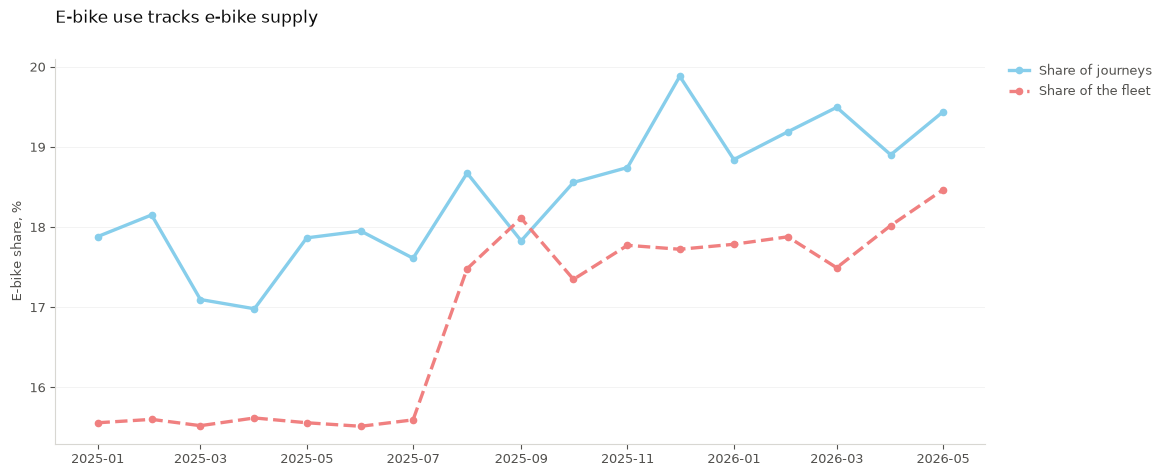

In [84]:
# Figure 17: e-bike use tracks e-bike supply
# Plotting both series together is what licenses the conclusion. Share of
# journeys alone would be read as adoption; alongside share of the fleet it is
# clear that the change follows procurement.

fig, ax = plt.subplots(figsize=(12, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
x = monthly_model.index.to_timestamp()

ax.plot(x, monthly_model["ebike_share"] * 100, color=PALETTE[0],
        linewidth=2.4, marker="o", markersize=4.5, label="Share of journeys")
ax.plot(x, fleet["ebike_share"].reindex(monthly_model.index) * 100,
        color=PALETTE[7], linewidth=2.4, marker="o", markersize=4.5,
        linestyle="--", label="Share of the fleet")

ax.set_ylabel("E-bike share, %", color=INK_SOFT, fontsize=9)
ax.set_title("E-bike use tracks e-bike supply", loc="left",
             fontsize=12, color=INK, pad=26)
ax.legend(frameon=False, fontsize=9, labelcolor=INK_SOFT,
          loc="upper left", bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, handlelength=1.6)
ax.grid(axis="y", alpha=0.15, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

plt.savefig(FIG_DIR / "fig17_ebike_supply.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

Both series move together: the August 2025 procurement step lifts fleet share from ~15.5 % to ~17.5 % and journey share follows immediately. Journey share sits consistently 1-2 pp above fleet share throughout, indicating modest but stable per-bike intensity advantage for e-bikes. 

In [85]:
# Year-on-year, like months only
# Seasonality is layered on top of any trend, so the raw series is noisy.
# Comparing each month against the same month a year earlier removes it.

yoy = monthly_model["ebike_share"].to_frame("share")
yoy["month"] = yoy.index.month
yoy["year"] = yoy.index.year
piv = yoy.pivot(index="month", columns="year", values="share").dropna()
piv["change_pp"] = (piv[2026] - piv[2025]) * 100

print("E-bike share of journeys, January to May:\n")
print((piv[[2025, 2026]] * 100).round(1).join(piv["change_pp"].round(1)).to_string())
print(f"\nMean year-on-year change: {piv['change_pp'].mean():+.1f} percentage points")

E-bike share of journeys, January to May:

         2025    2026  change_pp
month                           
1     17.9000 18.8000     1.0000
2     18.2000 19.2000     1.0000
3     17.1000 19.5000     2.4000
4     17.0000 18.9000     1.9000
5     17.9000 19.4000     1.6000

Mean year-on-year change: +1.6 percentage points


Like-for-like comparison confirms a consistent year-on-year gain of +1.6pp on average across January to May, ranging from +1.0pp (January, February) to +2.4pp (March). The gain is present in every month and aligns with the August 2025 fleet expansion rather than indicating independent demand growth.

In [86]:
# Utilisation: is each cycle working harder?
# Self-contained, taking the year as an argument, so the result cannot depend
# on variables another cell happened to leave bound. Both the fleet figure and
# the demand figure cover the same January to May window in each year, since
# comparing a single month's fleet against a five-month mean would not be
# like for like.

def utilisation(year, months=(1, 2, 3, 4, 5)):
    """
    Compute journeys per cycle per day across one year's January-to-May window.

    Parameters
    ----------
    year : int
        Calendar year to analyse.
    months : tuple of int, optional
        Months to include. Default is January to May.

    Returns
    -------
    dict
        Keys: year, mean_fleet, journeys_per_day, per_cycle_per_day.
    """
    lo, hi = pd.Period(f"{year}-01"), pd.Period(f"{year}-05")
    idx = [p for p in fleet.index if lo <= p <= hi]
    bikes = fleet.loc[idx, "total"].mean()

    sub = clean[(clean["year"] == year) & clean["month"].isin(months)]
    per_day = len(sub) / sub["start_time"].dt.normalize().nunique()
    return {"year": year, "mean_fleet": bikes, "journeys_per_day": per_day,
            "per_cycle_per_day": per_day / bikes}

uc = pd.DataFrame([utilisation(2025), utilisation(2026)]).set_index("year")
print(uc.round(3).to_string())
print(f"\nFleet change: {(uc['mean_fleet'].iloc[1] / uc['mean_fleet'].iloc[0] - 1) * 100:+.1f}%")
print(f"Demand change: {(uc['journeys_per_day'].iloc[1] / uc['journeys_per_day'].iloc[0] - 1) * 100:+.1f}%")
print(f"Utilisation change: {(uc['per_cycle_per_day'].iloc[1] / uc['per_cycle_per_day'].iloc[0] - 1) * 100:+.1f}%")

# Are e-bikes worked harder than classics?
util = (clean.groupby(["month_period", "bike_model"], observed=True)
        .agg(journeys=("rental_id", "size"), bikes=("bike_id", "nunique")))
util["per_bike"] = util["journeys"] / util["bikes"]
u = util["per_bike"].unstack()
u["ebike_advantage"] = u["PBSC_EBIKE"] / u["CLASSIC"]
print("\nJourneys per cycle per month, and the e-bike advantage:")
print(u.round(2).to_string())

      mean_fleet  journeys_per_day  per_cycle_per_day
year                                                 
2025  12220.4000        23176.8940             1.8970
2026  11898.8000        23399.2650             1.9670

Fleet change: -2.6%
Demand change: +1.0%
Utilisation change: +3.7%

Journeys per cycle per month, and the e-bike advantage:
bike_model    CLASSIC  PBSC_EBIKE  ebike_advantage
month_period                                      
2025-01       45.1600     53.3700           1.1800
2025-02       45.1900     54.2200           1.2000
2025-03       61.1800     68.6700           1.1200
2025-04       60.3900     66.7300           1.1100
2025-05       67.5100     79.7000           1.1800
2025-06       67.2900     80.1700           1.1900
2025-07       70.5000     81.5700           1.1600
2025-08       63.9800     69.3500           1.0800
2025-09       72.6800     71.3000           0.9800
2025-10       65.5900     71.2100           1.0900
2025-11       57.7800     61.6700           1.0

The fleet shrank by 2.6% year-on-year whilst demand rose 1.0%, pushing utilisation up +3.7%. E-bikes are consistently used more intensively than classics, with an advantage of 1.07-1.20x across most months. The advantage narrows after the August 2025 fleet expansion (from ~1.18x to ~1.07-1.09x), consistent with supply catching up to the latent demand premium.

In [87]:
# Distance and speed by fleet
# Duration alone understates the e-bike advantage because e-bikes are faster.
# Great-circle station separation is used as a distance proxy: it underestimates
# actual route distance equally for both fleets, so the relative comparison holds.

slat, slon = station_coords(clean["start_station_key"])
elat, elon = station_coords(clean["end_station_key"])
clean["straight_km"] = haversine_m(slat, slon, elat, elon) / 1000

oneway = clean[(clean["straight_km"] > 0) & clean["straight_km"].notna()]
print(f"Journeys with a measurable separation: {len(oneway):,} "
      f"({len(oneway) / len(clean):.1%})\n")

comp = (oneway.groupby("bike_model", observed=True)
        .agg(journeys=("rental_id", "size"),
             median_km=("straight_km", "median"),
             p90_km=("straight_km", lambda s: s.quantile(0.9)),
             median_min=("duration_min", "median"),
             mean_min=("duration_min", "mean"),
             commuter_pct=("is_commuter_trip", "mean"),
             weekend_pct=("is_weekend", "mean"),
             round_trip_pct=("is_round_trip", "mean")))
comp["kmh"] = comp["median_km"] / (comp["median_min"] / 60)
print(comp.round(3).to_string())

q = (oneway.groupby("bike_model", observed=True)["straight_km"]
     .quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).unstack().round(2))
print("\nDistance distribution by fleet, km:")
print(q.to_string())
print("\nE-bike premium at each quantile:")
print((q.loc["PBSC_EBIKE"] / q.loc["CLASSIC"] - 1).map("{:+.0%}".format).to_string())

Journeys with a measurable separation: 11,975,683 (95.8%)

            journeys  median_km  p90_km  median_min  mean_min  commuter_pct  weekend_pct  round_trip_pct     kmh
bike_model                                                                                                      
CLASSIC      9757502     1.9380  4.5440     12.5710   16.9320        0.4200       0.2330          0.0000  9.2510
PBSC_EBIKE   2218181     2.8870  6.0220     15.1130   19.0220        0.4450       0.2270          0.0000 11.4630

Distance distribution by fleet, km:
            0.2500  0.5000  0.7500  0.9000  0.9500  0.9900
bike_model                                                
CLASSIC     1.1400  1.9400  3.1200  4.5400  5.5800  7.8300
PBSC_EBIKE  1.8000  2.8900  4.3600  6.0200  7.1700  9.4800

E-bike premium at each quantile:
0.2500    +58%
0.5000    +49%
0.7500    +40%
0.9000    +33%
0.9500    +28%
0.9900    +21%


E-bikes cover 49% more distance at the median (2.89km vs 1.94km) and travel at an implied speed of 11.5km/h versus 9.3km/h for classics. The distance premium is largest at the lower quantiles (+58% at Q1) and compresses toward the tail (+21% at P99), indicating that e-bikes disproportionately extend short-to-medium trips rather than enabling extreme-distance outliers. Commuter share is marginally higher for e-bikes (44.5% vs 42.0%); weekend share is marginally lower (22.7% vs 23.3%), suggesting a slight tilt toward purposeful over leisure use.

In [88]:
# Audit: journeys excluded from the distance comparison
gone = clean[~clean.index.isin(oneway.index)]
print("Excluded from the distance comparison: {:,}".format(len(gone)))
print(" - round trips: {:,}".format(int(gone["is_round_trip"].sum())))
print(" - unresolved endpoint: {:,}".format(int(
    gone["start_station_key"].isna().sum() + gone["end_station_key"].isna().sum())))
print(" - zero distance, distinct stations: {:,}".format(int(
    ((gone["straight_km"] == 0) & ~gone["is_round_trip"]).sum())))

Excluded from the distance comparison: 526,327
 - round trips: 318,769
 - unresolved endpoint: 210,681
 - zero distance, distinct stations: 0


The exclusions are structurally explained and affect both fleets proportionally, so the comparison is unbiased.

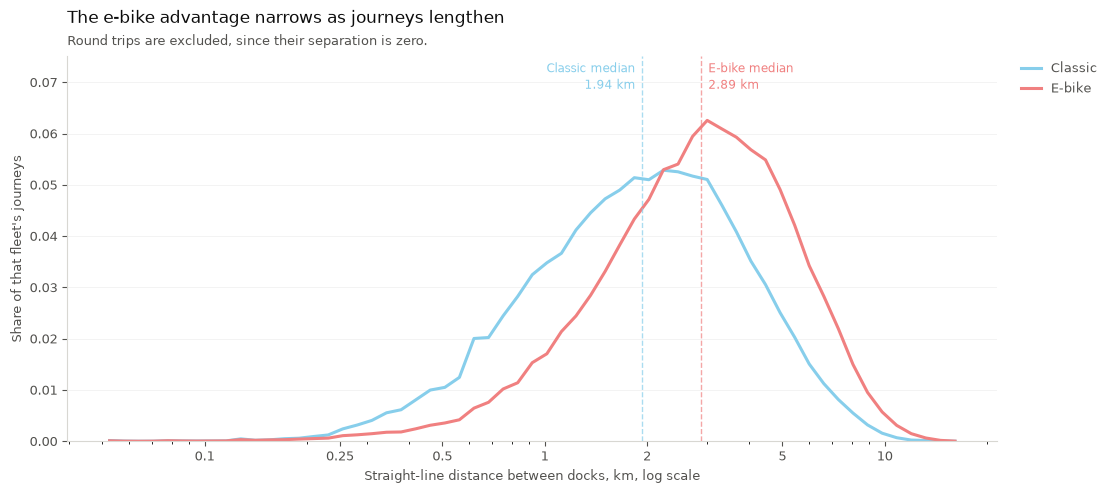

In [89]:
# Figure 18: distance travelled by fleet
# Each fleet is normalised to its own total, so the 82:18 split in volume does
# not make the classic distribution appear larger merely by being more
# numerous. Bin proportions rather than a kernel density estimate: exact, fast
# on twelve million records, and no smoothing parameter to justify.

bins = np.logspace(np.log10(0.05), np.log10(oneway["straight_km"].max()), 60)
centres = np.sqrt(bins[:-1] * bins[1:])

fig, ax = plt.subplots(figsize=(12, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.set_xscale("log")

FLEET_COLOUR = {"CLASSIC": PALETTE[0], "PBSC_EBIKE": PALETTE[7]}
FLEET_LABEL = {"CLASSIC": "Classic", "PBSC_EBIKE": "E-bike"}

# Plot first, position labels afterwards, so nothing is placed against an
# axis limit that later cells of the same loop go on to change.
medians, peak = {}, 0
for model, colour in FLEET_COLOUR.items():
    v = oneway.loc[oneway["bike_model"] == model, "straight_km"]
    counts, _ = np.histogram(v, bins=bins)
    share = counts / counts.sum()
    peak = max(peak, share.max())
    medians[model] = v.median()
    ax.plot(centres, share, color=colour, linewidth=2.2,
            label=FLEET_LABEL[model])

# Headroom for the labels, set once and explicitly rather than left to autoscale.
ax.set_ylim(0, peak * 1.20)

# x in data coordinates, y in axes coordinates: the label pins to the top of
# the line whatever the vertical scale turns out to be.
at_top = ax.get_xaxis_transform()
SIDE = {"CLASSIC": ("right", -5), "PBSC_EBIKE": ("left", 5)}

for model, colour in FLEET_COLOUR.items():
    med = medians[model]
    ax.axvline(med, color=colour, linewidth=1, linestyle="--", alpha=0.7)
    ha, dx = SIDE[model]
    ax.annotate(f"{FLEET_LABEL[model]} median\n{med:.2f} km",
                xy=(med, 1.0), xycoords=at_top,
                xytext=(dx, -2), textcoords="offset points",
                fontsize=8.5, color=colour, ha=ha, va="top",
                linespacing=1.4)

ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 5, 10])
ax.set_xticklabels(["0.1", "0.25", "0.5", "1", "2", "5", "10"])
ax.set_xlabel("Straight-line distance between docks, km, log scale",
              color=INK_SOFT, fontsize=9)
ax.set_ylabel("Share of that fleet's journeys", color=INK_SOFT, fontsize=9)
ax.set_title("The e-bike advantage narrows as journeys lengthen",
             loc="left", fontsize=12, color=INK, pad=24)
ax.annotate("Round trips are excluded, since their separation is zero.",
            xy=(0, 1.015), xycoords="axes fraction", ha="left", va="bottom",
            fontsize=9, color=INK_SOFT, linespacing=1.5)
ax.legend(frameon=False, fontsize=9, labelcolor=INK_SOFT,
          loc="upper left", bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, handlelength=1.6)
ax.grid(axis="y", alpha=0.15, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)

plt.savefig(FIG_DIR / "fig18_distance_by_fleet.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

The e-bike distribution is shifted rightward across its full range, median 2.89 km versus 1.94 km for classics, but the two distributions converge at longer distances. The classic curve peaks sharply near 0.5-1 km; the e-bike curve is flatter and peaks near 2-3 km, confirming that electrical assistance primarily extends short and medium trips rather than enabling outlier distances.

In [90]:
# Is the extra range used at the periphery or everywhere?
# If assistance extends the scheme's catchment, its advantage should be largest
# where distances are longest, that is at the network's edge. If the premium is
# uniform across rings, e-bikes are simply ridden further everywhere, and RQ4
# is a question about behaviour rather than about geography.

# Distance from centre is recomputed here rather than borrowed from RQ3, so the
# cell does not depend on state set elsewhere.

c_lat = key_coords["ref_lat"].median()
c_lon = key_coords["ref_lon"].median()
dist_centre = pd.Series(
    haversine_m(key_coords["ref_lat"].to_numpy(), key_coords["ref_lon"].to_numpy(),
                np.full(len(key_coords), c_lat), np.full(len(key_coords), c_lon)) / 1000,
    index=key_coords.index, name="km_from_centre")

st = oneway.dropna(subset=["start_station_key"]).copy()
st["start_key"] = st["start_station_key"].astype("int64")

by_station = (st.groupby(["start_key", "bike_model"], observed=True)
              .agg(n=("rental_id", "size"), med_km=("straight_km", "median"))
              .unstack())
by_station.columns = [f"{a}_{b}" for a, b in by_station.columns]
by_station = by_station.dropna()
by_station = by_station[(by_station["n_CLASSIC"] >= 500)
                        & (by_station["n_PBSC_EBIKE"] >= 200)]

by_station["ebike_share"] = (by_station["n_PBSC_EBIKE"]
                             / (by_station["n_PBSC_EBIKE"] + by_station["n_CLASSIC"]))
by_station["km_premium"] = (by_station["med_km_PBSC_EBIKE"]
                            / by_station["med_km_CLASSIC"] - 1)
by_station = by_station.join(dist_centre, how="inner")
by_station["ring"] = pd.qcut(by_station["km_from_centre"], 4,
                             labels=["inner", "inner middle",
                                     "outer middle", "outer"])
by_station["station"] = by_station.index.map(name)

print(f"Stations compared: {len(by_station)} of {len(key_coords)}\n")
print(f"E-bike share against distance from centre: "
      f"{by_station['ebike_share'].corr(by_station['km_from_centre']):+.3f}")
print(f"Distance premium against distance from centre: "
      f"{by_station['km_premium'].corr(by_station['km_from_centre']):+.3f}")

print("\nBy distance ring:")
print(by_station.groupby("ring", observed=True)
      .agg(stations=("ebike_share", "size"),
           ebike_share=("ebike_share", "mean"),
           classic_km=("med_km_CLASSIC", "median"),
           ebike_km=("med_km_PBSC_EBIKE", "median"),
           premium=("km_premium", "mean")).round(3).to_string())

print("\nStations where e-bikes are ridden furthest relative to classics:")
print(by_station.nlargest(8, "km_premium")[
    ["station", "km_from_centre", "med_km_CLASSIC", "med_km_PBSC_EBIKE",
     "km_premium", "ebike_share"]].round(2).to_string(index=False))

Stations compared: 795 of 797

E-bike share against distance from centre: -0.151
Distance premium against distance from centre: +0.521

By distance ring:
              stations  ebike_share  classic_km  ebike_km  premium
ring                                                              
inner              199       0.1960      1.9940    2.7130   0.3740
inner middle       199       0.1930      1.9920    2.8110   0.4340
outer middle       198       0.1790      1.8840    2.9630   0.6270
outer              199       0.1760      1.8570    3.3870   0.9050

Stations where e-bikes are ridden furthest relative to classics:
                                   station  km_from_centre  med_km_CLASSIC  med_km_PBSC_EBIKE  km_premium  ebike_share
              East Ferry Road, Cubitt Town          8.0600          0.9000             4.9700      4.5000       0.1500
                 Mudchute DLR, Cubitt Town          8.1500          0.7400             3.4100      3.6300       0.1700
Timber Lodge, Queen E

The distance premium grows strongly with distance from centre (r=+0.521): inner stations show a median premium of +37%, rising to +91% at the outer ring. E-bike share falls slightly with distance (r=-0.151), meaning fewer e-bike journeys originate at peripheral stations, but those that do cover far more ground relative to classics. The top-premium stations: Cubitt Town, Olympic Park, Blackwall, Putney, are all outer-ring locations where classic cyclists rarely venture beyond the nearest docking station but e-bike riders travel 2-4x further.

In [91]:
# Peripherality, or network sparsity?
# The stations with the largest premium are not merely far out, they sit in
# pockets where the next dock is a gap away. Distance from centre and local
# sparsity are correlated, so each is tested with the other held constant.

lat = key_coords["ref_lat"].to_numpy()
lon = key_coords["ref_lon"].to_numpy()
D = haversine_m(lat[:, None], lon[:, None], lat[None, :], lon[None, :]) / 1000
np.fill_diagonal(D, np.inf)
isolation = pd.Series(np.sort(D, axis=1)[:, :3].mean(axis=1),
                      index=key_coords.index, name="km_to_nearest3")

bs = by_station.join(isolation, how="inner")
bs["km_gap"] = bs["med_km_PBSC_EBIKE"] - bs["med_km_CLASSIC"]

def partial(y, x, z):
    """
    Compute the partial correlation of y with x, controlling for z.

    Parameters
    ----------
    y, x, z : array-like
        Numeric arrays of equal length.

    Returns
    -------
    float
        Pearson correlation of the residuals of (y ~ z) and (x ~ z).
    """
    rx = x - np.polyval(np.polyfit(z, x, 1), z)
    ry = y - np.polyval(np.polyfit(z, y, 1), z)
    return np.corrcoef(rx, ry)[0, 1]

for target, label in [("km_premium", "ratio"), ("km_gap", "absolute km")]:
    y = bs[target].to_numpy()
    d = bs["km_from_centre"].to_numpy()
    s = bs["km_to_nearest3"].to_numpy()
    print(f"{label:>12}  centre {np.corrcoef(y, d)[0, 1]:+.3f}"
          f"   sparsity {np.corrcoef(y, s)[0, 1]:+.3f}"
          f"   centre|sparsity {partial(y, d, s):+.3f}"
          f"   sparsity|centre {partial(y, s, d):+.3f}")

print("\nBy absolute gap, km:")
print(bs.nlargest(8, "km_gap")[["station", "km_from_centre",
                                "km_to_nearest3", "med_km_CLASSIC",
                                "med_km_PBSC_EBIKE", "km_gap",
                                "km_premium"]].round(2).to_string(index=False))

       ratio  centre +0.521   sparsity +0.178   centre|sparsity +0.509   sparsity|centre -0.121
 absolute km  centre +0.594   sparsity +0.293   centre|sparsity +0.541   sparsity|centre -0.015

By absolute gap, km:
                       station  km_from_centre  km_to_nearest3  med_km_CLASSIC  med_km_PBSC_EBIKE  km_gap  km_premium
       Santos Road, Wandsworth          7.6700          0.3300          1.9400             6.8300  4.8900      2.5200
  East Ferry Road, Cubitt Town          8.0600          0.4100          0.9000             4.9700  4.0600      4.5000
   Upper Richmond Road, Putney          8.0000          0.2500          1.5200             4.8500  3.3300      2.1900
          Naval Row, Blackwall          8.4000          0.4100          1.7400             4.8600  3.1200      1.8000
    Spindrift Avenue, Millwall          7.8600          0.4000          1.3700             4.3100  2.9400      2.1400
Hurlingham Park, Parsons Green          6.8400          0.3300          1.5900

Controlling for sparsity, the distance-from-centre effect on the e-bike premium remains strong (partial r=+0.509 for the ratio, +0.541 for the absolute gap). Sparsity alone has near-zero partial correlation once centrality is held constant (-0.121 and -0.015). The premium is a peripherality effect, not a dock-spacing effect: e-bikes extend reach at the outer edge of the network regardless of how closely stations are packed there.

In [92]:
# Do peripheral e-bike journeys head for the centre?
# The premium at the edge is consistent with two different stories: e-bikes
# being ridden further in every direction, or e-bikes being used to leave the
# area. The change in distance from centre between origin and destination
# separates them. Negative means the journey moved inwards.

r_of = dist_centre
g = oneway.dropna(subset=["start_station_key", "end_station_key"]).copy()
g["r_start"] = g["start_station_key"].astype("int64").map(r_of)
g["r_end"] = g["end_station_key"].astype("int64").map(r_of)
g["inward_km"] = g["r_start"] - g["r_end"]
g["ring"] = pd.qcut(g["r_start"], 4,
                    labels=["inner", "inner middle", "outer middle", "outer"])

print(g.groupby(["ring", "bike_model"], observed=True)
      .agg(journeys=("inward_km", "size"),
           median_inward=("inward_km", "median"),
           mean_inward=("inward_km", "mean"),
           pct_inward=("inward_km", lambda s: (s > 0).mean()))
      .round(3).to_string())

                         journeys  median_inward  mean_inward  pct_inward
ring         bike_model                                                  
inner        CLASSIC      2404052        -1.0580      -1.2750      0.2120
             PBSC_EBIKE    594375        -1.6150      -1.8280      0.1590
inner middle CLASSIC      2431457         0.0110      -0.1490      0.5030
             PBSC_EBIKE    558375        -0.2240      -0.3950      0.4540
outer middle CLASSIC      2449172         0.4480       0.3860      0.6110
             PBSC_EBIKE    545146         0.7810       0.5760      0.6590
outer        CLASSIC      2472821         0.8370       1.1840      0.7200
             PBSC_EBIKE    520285         2.0120       2.0340      0.8100


From the outer ring, 81% of e-bike journeys move inward versus 72% for classics, with a median inward displacement of +2.01km versus +0.84km. The directional bias strengthens with distance from centre and is consistently larger for e-bikes at every ring. Peripheral e-bike riders are not simply cycling further in all directions, they are predominantly travelling toward the centre, using assistance to bridge the gap that deters classic riders.

In [93]:
# Is the inward bias a choice of direction, or a consequence of length?
# Expressing radial displacement as a fraction of the journey's straight-line
# distance removes length from the measure: +1 is directly inbound, -1 directly
# outbound, 0 tangential. If the fleets still differ, direction is chosen.

g["radial_frac"] = g["inward_km"] / g["straight_km"]

print(g.groupby(["ring", "bike_model"], observed=True)["radial_frac"]
      .agg(median="median", mean="mean").round(3).unstack().to_string())

              median               mean           
bike_model   CLASSIC PBSC_EBIKE CLASSIC PBSC_EBIKE
ring                                              
inner        -0.6070    -0.6490 -0.4260    -0.4970
inner middle  0.0060    -0.0870 -0.0000    -0.0470
outer middle  0.2860     0.2930  0.1370     0.1910
outer         0.5930     0.6730  0.3540     0.4690


After normalising for journey length, e-bikes are directionally more inward-oriented than classics at every ring. The outer-ring difference is clearest: median radial fraction +0.673 for e-bikes versus +0.593 for classics. The gap persists in the mean column too. E-bike riders at the periphery choose a more radially inward direction, the centripetal bias is not a length artefact.

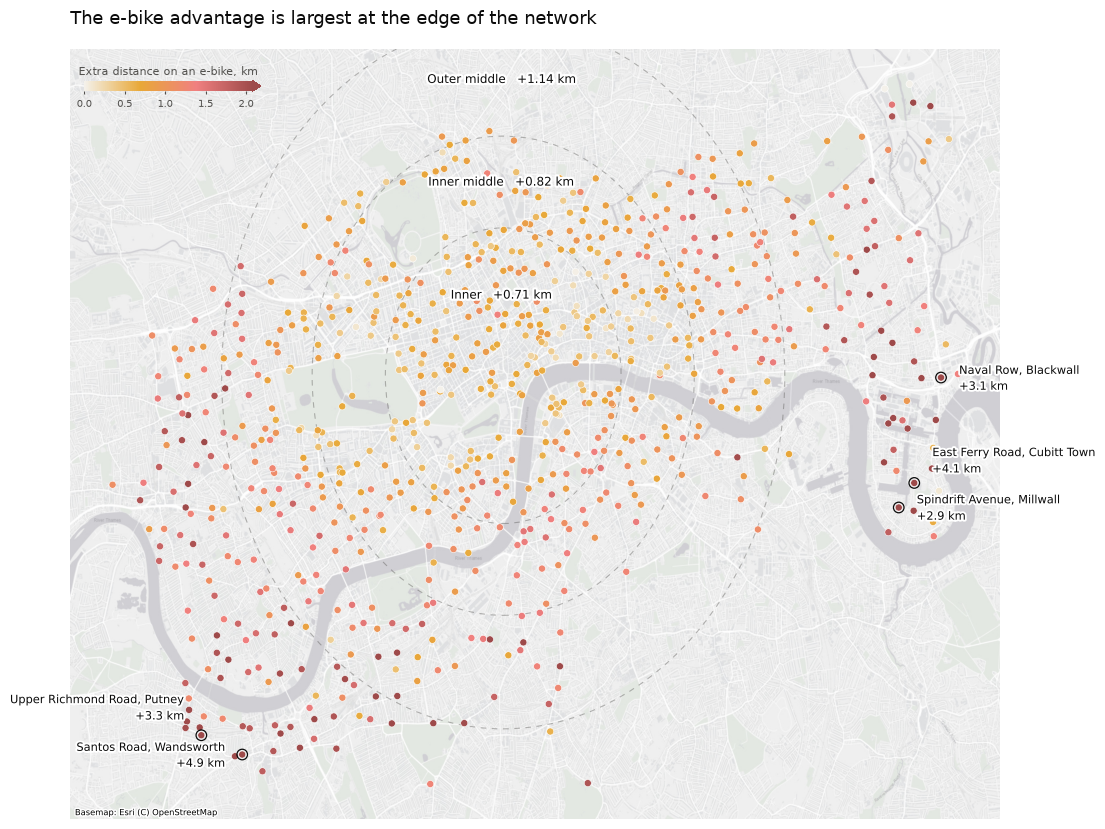

Stations mapped: 795
Median gap: +0.96 km
Negative gap: 1 stations
Ring means:
ring
Inner          0.7100
Inner middle   0.8200
Outer middle   1.1400
Outer          1.5600


In [94]:
# Figure 19: where the e-bike distance advantage is largest
# Figure 18 shows the premium narrowing as journeys lengthen, which reads
# network-wide as a rejection of the reach hypothesis. Mapping the same
# quantity station by station shows it reverses with position, so this figure
# exists to make the conditioning visible rather than to restate the aggregate.
# The gradient is real but noisy, r = +0.59 across 794 stations, and a plain
# dot map renders that as scatter. The ring boundaries and their mean gaps are
# drawn on the map so that the structure is stated rather than inferred; the
# individual points then do what they are suited to, which is showing where the
# exceptions lie.

gap = by_station.copy()
gap["km_gap"] = gap["med_km_PBSC_EBIKE"] - gap["med_km_CLASSIC"]
gap = gap.join(key_coords[["ref_lat", "ref_lon"]], how="inner")

gg = gpd.GeoDataFrame(
    gap, geometry=gpd.points_from_xy(gap["ref_lon"], gap["ref_lat"]),
    crs="EPSG:4326").to_crs(epsg=3857)

GAP_CMAP = LinearSegmentedColormap.from_list(
    "gap", ["#f4f1ea", PALETTE[6], PALETTE[7], "#9e4a4a"])
vmax = gg["km_gap"].quantile(0.95)

RING_NAMES = ["Inner", "Inner middle", "Outer middle", "Outer"]
gg["ring"] = pd.qcut(gg["km_from_centre"], 4, labels=RING_NAMES)
ring_mean = gg.groupby("ring", observed=True)["km_gap"].mean()
edges = gg["km_from_centre"].quantile([0, 0.25, 0.50, 0.75, 1.0]).to_numpy()

# Web Mercator inflates distance by 1/cos(latitude), so a ring of r kilometres
# on the ground is drawn at r / cos(51.5 degrees) in projected metres.
centre = gpd.GeoSeries([Point(c_lon, c_lat)], crs="EPSG:4326") \
            .to_crs(epsg=3857).iloc[0]
merc = 1 / np.cos(np.radians(c_lat))

fig, ax = plt.subplots(figsize=(12, 10), facecolor=SURFACE)

sc = ax.scatter(gg.geometry.x, gg.geometry.y,
                 c=gg["km_gap"].clip(upper=vmax),
                 cmap=GAP_CMAP, vmin=0, vmax=vmax,
                 s=26, edgecolor="white", linewidth=0.4, zorder=4)

# Limits are set from the stations, not left to the basemap, so the figure has
# no dead margin. Applied before add_basemap so the tiles match the extent.
pad = 0.05
xs, ys = gg.geometry.x, gg.geometry.y
dx, dy = xs.max() - xs.min(), ys.max() - ys.min()
ax.set_xlim(xs.min() - dx * pad, xs.max() + dx * pad)
ax.set_ylim(ys.min() - dy * pad, ys.max() + dy * pad)

for r_km in edges[1:-1]:
    ax.add_patch(plt.Circle((centre.x, centre.y), r_km * 1000 * merc,
                            fill=False, edgecolor=INK_SOFT, linewidth=0.8,
                            linestyle=(0, (5, 5)), alpha=0.40, zorder=2))

# Ring means run north from the centre, one per band, placed at the midpoint
# radius of the band. North is the emptiest direction on this network.
for i, nm in enumerate(RING_NAMES):
    mid = (edges[i] + edges[i + 1]) / 2
    ax.annotate(f"{nm}   +{ring_mean[nm]:.2f} km",
                xy=(centre.x, centre.y + mid * 1000 * merc),
                ha="center", va="center", fontsize=8.6, color=INK, zorder=6,
                path_effects=[pe.withStroke(linewidth=3.2, foreground="white")])

try:
    cx.add_basemap(ax, crs=gg.crs, source=str(BASEMAP_WIDE),
                   attribution=BASEMAP_ATTRIBUTION,
                   attribution_size=6, zorder=1)
except Exception as exc:
    print(f"Basemap unavailable ({exc})")

# Five labels rather than eight. Three of the largest gaps sit on the Isle of
# Dogs, so labelling one and leaving the rest as ringed markers says the same
# thing with less ink. Offsets are solved from the plotted positions after the
# limits are final, so the figure re-lays itself out if the figures change.
lab = gg.nlargest(5, "km_gap").copy()
fig.canvas.draw()
px, py = ax.transData.transform(
    np.column_stack([lab.geometry.x, lab.geometry.y])).T
lab["px"], lab["py"] = px, py
lab["side"] = np.where(lab.geometry.x >= gg.geometry.x.median(), 1, -1)

MIN_GAP, to_points = 34, 72 / fig.dpi
lab["dy"] = 0.0
for side in (-1, 1):
    previous = -1e9
    for idx in lab[lab["side"] == side].sort_values("py").index:
        y_pt = lab.at[idx, "py"] * to_points
        placed = max(y_pt, previous + MIN_GAP)
        lab.at[idx, "dy"] = placed - y_pt
        previous = placed

for idx, r in lab.iterrows():
    right = r["side"] == 1
    ax.annotate(f"{r['station']}\n+{r['km_gap']:.1f} km",
                xy=(r.geometry.x, r.geometry.y),
                xytext=(13 if right else -13, r["dy"]),
                textcoords="offset points",
                ha="left" if right else "right", va="center",
                fontsize=8.2, color=INK, linespacing=1.35, zorder=7,
                path_effects=[pe.withStroke(linewidth=2.8, foreground="white")])
    ax.scatter([r.geometry.x], [r.geometry.y], s=58, facecolor="none",
               edgecolor=INK, linewidth=0.9, zorder=5)

cax = ax.inset_axes([0.015, 0.945, 0.19, 0.014])
cbar = fig.colorbar(sc, cax=cax, orientation="horizontal", extend="max")
cbar.set_label("Extra distance on an e-bike, km", color=INK_SOFT, fontsize=8.2)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.tick_params(colors=INK_SOFT, labelsize=7.5, length=2)
cbar.outline.set_visible(False)

ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("The e-bike advantage is largest at the edge of the network",
             loc="left", fontsize=13, color=INK, pad=18)

plt.savefig(FIG_DIR / "fig19_ebike_gap_map.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

print(f"Stations mapped: {len(gg):,}")
print(f"Median gap: {gg['km_gap'].median():+.2f} km")
print(f"Negative gap: {int((gg['km_gap'] < 0).sum()):,} stations")
print(f"Ring means:\n{ring_mean.round(2).to_string()}")

E-bike distance gap widens consistently from centre to periphery.

**RQ5: Station archetypes: Can stations be grouped into archetypes from demand, spatial and imbalance characteristics?**

Station roles emerge from the interaction of demand, geography, and network position rather than from any single dimension. This section applies k-means clustering to a 16-feature station-level matrix spanning demand profile, spatial position, network centrality, and fleet composition to identify latent archetypes that cut across administrative geography.

In [95]:
# Feature Matrix
# All features are computed at station level (indexed by station_key).
# Four dimensions: demand profile, spatial position, network centrality,
# and fleet composition. Journey-level clean is aggregated here; all other
# inputs (flow, cen, bs, by_station, sf, dist_centre) are already station-level.

# Demand profile
# Base counts and behavioural fractions from the journey log.
demand = (
    clean.groupby("start_station_key")
    .agg(
        total_starts = ("rental_id", "count"),
        commuter_frac = ("is_commuter_trip", "mean"),
        weekend_frac = ("is_weekend", "mean"),
        med_duration_min = ("duration_min", "median"),
        med_km = ("straight_km", "median"),
    )
    .rename_axis("station_key")
)

# Morning and evening peak fractions (departures only)
n_starts = clean.groupby("start_station_key").size().rename_axis("station_key")

am_frac = (
    clean[clean["period"] == "Morning peak"]
    .groupby("start_station_key").size()
    .rename_axis("station_key")
    .div(n_starts)
    .rename("am_peak_frac")
)

pm_frac = (
    clean[clean["period"] == "Evening peak"]
    .groupby("start_station_key").size()
    .rename_axis("station_key")
    .div(n_starts)
    .rename("pm_peak_frac")
)

demand = demand.join(am_frac, how="left").join(pm_frac, how="left")

# Join spatial, network, and fleet features
km_gap = (
    by_station["med_km_PBSC_EBIKE"] - by_station["med_km_CLASSIC"]
).rename("km_gap")

feat = (
    demand
    .join(flow[["imbalance_rate", "turnover"]], how="inner")
    .join(dist_centre.rename("dist_from_centre"), how="left")
    .join(cen[["betweenness", "eigenvector"]], how="left")
    .join(bs[["km_to_nearest3", "ebike_share"]], how="left")
    .join(km_gap, how="left")
    .join(sf[["reversal"]].rename(columns={"reversal": "reversal_ratio"}), how="left")
)

# Drop stations missing centrality or spatial position (thin-data periphery)
feat = feat.dropna(subset=["betweenness", "dist_from_centre", "imbalance_rate"])

# Fill remaining NaNs with column medians (e.g. km_gap where only one fleet exists)
feat = feat.fillna(feat.median(numeric_only=True))

print(f"Stations in feature matrix : {len(feat):,}")
print(f"Features : {feat.shape[1]}")
print(f"\nMissing values after fill : {feat.isnull().sum().sum()}")
print(f"\nFeature summary:")
print(feat.describe().round(3))

Stations in feature matrix : 797
Features : 16

Missing values after fill : 0

Feature summary:
       total_starts  commuter_frac  weekend_frac  med_duration_min   med_km  am_peak_frac  pm_peak_frac  imbalance_rate    turnover  dist_from_centre  betweenness  eigenvector  km_to_nearest3  ebike_share   km_gap  reversal_ratio
count      797.0000       797.0000      797.0000          797.0000 797.0000      797.0000      797.0000        797.0000    797.0000          797.0000     797.0000     797.0000        797.0000     797.0000 797.0000        797.0000
mean     15553.8310         0.4190        0.2390           13.4880   2.0800        0.2210        0.1980         -0.0070  31108.3300            3.9680       0.0040       0.0270          0.3000       0.1860   1.0590          0.5610
std       8991.3170         0.0780        0.0600            3.0220   0.4690        0.1120        0.0940          0.0510  18378.3710            2.0750       0.0170       0.0230          0.1160       0.0470   0.5560 

Feature matrix: 797 stations, 16 features across demand, spatial, centrality, and fleet dimensions. No missing values after median imputation.

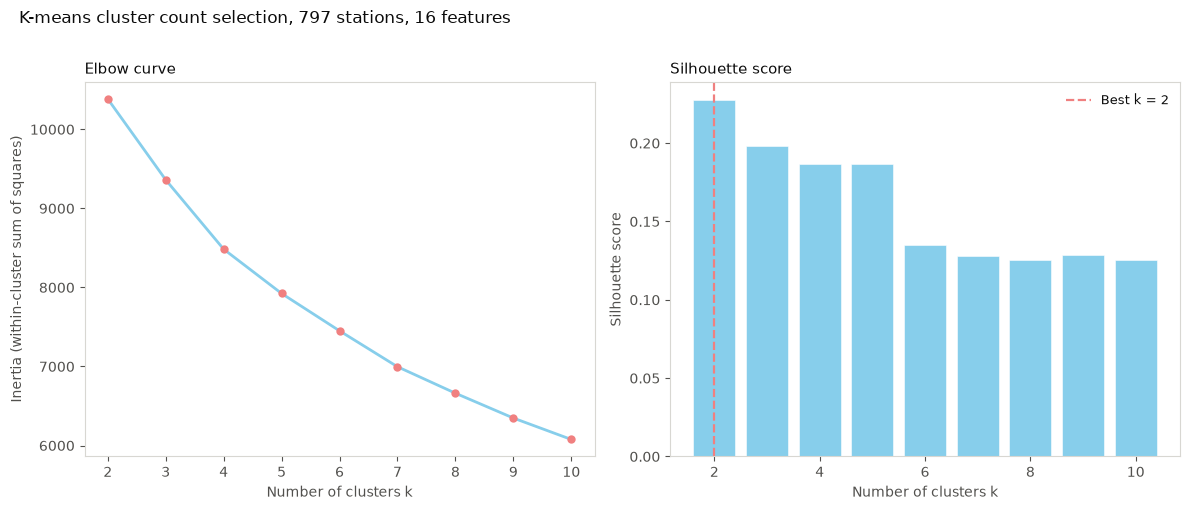

   k       Inertia    Silhouette
   2       10384.2        0.2277 <-- best silhouette
   3        9361.1        0.1983
   4        8483.7        0.1867
   5        7923.2        0.1867
   6        7450.5        0.1349
   7        6996.3        0.1282
   8        6661.4        0.1255
   9        6347.2        0.1284
  10        6076.3        0.1254


In [96]:
# K-selection
# Features span very different scales (total_starts ~15k vs betweenness ~0.004)
# so StandardScaler is applied before any distance-based computation.

FEATURE_COLS = feat.columns.tolist()

scaler = StandardScaler()
X = scaler.fit_transform(feat[FEATURE_COLS])

# Elbow (inertia) and silhouette score across k = 2..10
K_RANGE   = range(2, 11)
inertias  = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels, sample_size=min(len(X), 500),
                                       random_state=42))

# Figure 20: k-selection panel
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), facecolor=SURFACE)

ks = list(K_RANGE)

# Elbow curve
ax1.plot(ks, inertias, color=PALETTE[0], lw=2, marker="o", ms=6,
         markerfacecolor=PALETTE[7], markeredgewidth=0)
ax1.set_xlabel("Number of clusters k", color=INK_SOFT, fontsize=10)
ax1.set_ylabel("Inertia (within-cluster sum of squares)", color=INK_SOFT, fontsize=10)
ax1.set_title("Elbow curve", loc="left", color=INK, fontsize=11)
ax1.set_facecolor(SURFACE)
ax1.tick_params(colors=INK_SOFT)
for sp in ax1.spines.values():
    sp.set_color(GRID)

# Silhouette scores
ax2.bar(ks, sil_scores, color=PALETTE[0], edgecolor="white", linewidth=0.4)
best_k = ks[int(np.argmax(sil_scores))]
ax2.axvline(best_k, color=PALETTE[7], lw=1.6, linestyle="--",
            label=f"Best k = {best_k}")
ax2.set_xlabel("Number of clusters k", color=INK_SOFT, fontsize=10)
ax2.set_ylabel("Silhouette score", color=INK_SOFT, fontsize=10)
ax2.set_title("Silhouette score", loc="left", color=INK, fontsize=11)
ax2.legend(fontsize=9, frameon=False, labelcolor=INK)
ax2.set_facecolor(SURFACE)
ax2.tick_params(colors=INK_SOFT)
for sp in ax2.spines.values():
    sp.set_color(GRID)

fig.suptitle("K-means cluster count selection, 797 stations, 16 features",
             fontsize=12, color=INK, x=0.02, ha="left", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig20_k_selection.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

print(f"{'k':>4}  {'Inertia':>12}  {'Silhouette':>12}")
for k, ine, sil in zip(ks, inertias, sil_scores):
    marker = " <-- best silhouette" if k == best_k else ""
    print(f"{k:>4}  {ine:>12.1f}  {sil:>12.4f}{marker}")

Silhouette peaks at k=2 (0.228) but declines sharply to a plateau at k=4-5 (both 0.187). The elbow curve shows no sharp bend, consistent with a network where station roles exist on a continuum. k=4 is selected as the minimum that produces analytically distinct archetypes.

In [97]:
# Fit KMeans k=4
K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
feat["cluster"] = km_final.fit_predict(X)

# Cluster sizes
sizes = feat["cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(sizes.to_string())

# Cluster centroids in original (unscaled) feature space for interpretation
centres = (
    pd.DataFrame(scaler.inverse_transform(km_final.cluster_centers_),
                 columns=FEATURE_COLS)
)
centres.index.name = "cluster"
print("\nCluster centroids (unscaled):")
print(centres[["total_starts","commuter_frac","weekend_frac",
               "dist_from_centre","betweenness","imbalance_rate",
               "ebike_share","km_gap"]].round(3))

Cluster sizes:
cluster
0    394
1     41
2    210
3    152

Cluster centroids (unscaled):
         total_starts  commuter_frac  weekend_frac  dist_from_centre  betweenness  imbalance_rate  ebike_share  km_gap
cluster                                                                                                               
0          14258.9140         0.4270        0.2480            4.1980       0.0020         -0.0300       0.1690  1.1090
1          41396.4150         0.4350        0.2130            2.6640       0.0460          0.0330       0.1880  0.6380
2          16675.7570         0.4150        0.1920            2.0600       0.0020          0.0290       0.2040  0.6940
3          10389.6640         0.4000        0.2900            6.3570       0.0010         -0.0050       0.2050  1.5470


k=4 produces four archetypes: network gateways (n=41, betweenness 0.046, 41k starts), employment destinations (n=210, inner, net accumulating), suburban commuter feeders (n=394, peripheral, net depleting), and peripheral leisure stations (n=152, highest weekend fraction 0.29, largest e-bike gap 1.55 km).

In [98]:
# Assign interpretable names to cluster indices
CLUSTER_NAMES = {
    0: "Suburban commuter feeders",
    1: "Network gateways",
    2: "Employment destinations",
    3: "Peripheral leisure",
}
feat["cluster_name"] = feat["cluster"].map(CLUSTER_NAMES)
print(feat["cluster_name"].value_counts())

cluster_name
Suburban commuter feeders    394
Employment destinations      210
Peripheral leisure           152
Network gateways              41
Name: count, dtype: int64


In [99]:
# Interactive 3D PCA scatter

# PCA to three components for visualisation
pca = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(X)
ev = pca.explained_variance_ratio_ * 100  # explained variance per component

feat["pc1"] = coords[:, 0]
feat["pc2"] = coords[:, 1]
feat["pc3"] = coords[:, 2]

print(f"Explained variance:\nPC1: {ev[0]:.1f}%  PC2: {ev[1]:.1f}%  "
      f"PC3: {ev[2]:.1f}%  Total: {ev.sum():.1f}%")

CLUSTER_COLOURS = {
    "Network gateways" : PALETTE[0],
    "Employment destinations" : PALETTE[3],
    "Suburban commuter feeders": PALETTE[6],
    "Peripheral leisure": PALETTE[7],
}

traces = []
for name, colour in CLUSTER_COLOURS.items():
    mask = feat["cluster_name"] == name
    sub  = feat[mask]
    traces.append(go.Scatter3d(
        x=sub["pc1"],
        y=sub["pc2"],
        z=sub["pc3"],
        mode="markers",
        name=name,
        marker=dict(
            size=4,
            color=colour,
            opacity=0.75,
            line=dict(color="black", width=0.4)
        )
    ))

fig = go.Figure(data=traces)

fig.update_layout(
    title=f"Station archetypes in PCA space, k=4, 797 stations",
    scene=dict(
        xaxis_title=f"PC1",
        yaxis_title=f"PC2",
        zaxis_title=f"PC3",
    ),
    legend_title="Archetype",
    width=900,
    height=600,
)

fig.write_html(FIG_DIR / "fig21_pca_3d_interactive.html")
fig

Explained variance:
PC1: 27.6%  PC2: 15.7%  PC3: 13.4%  Total: 56.7%


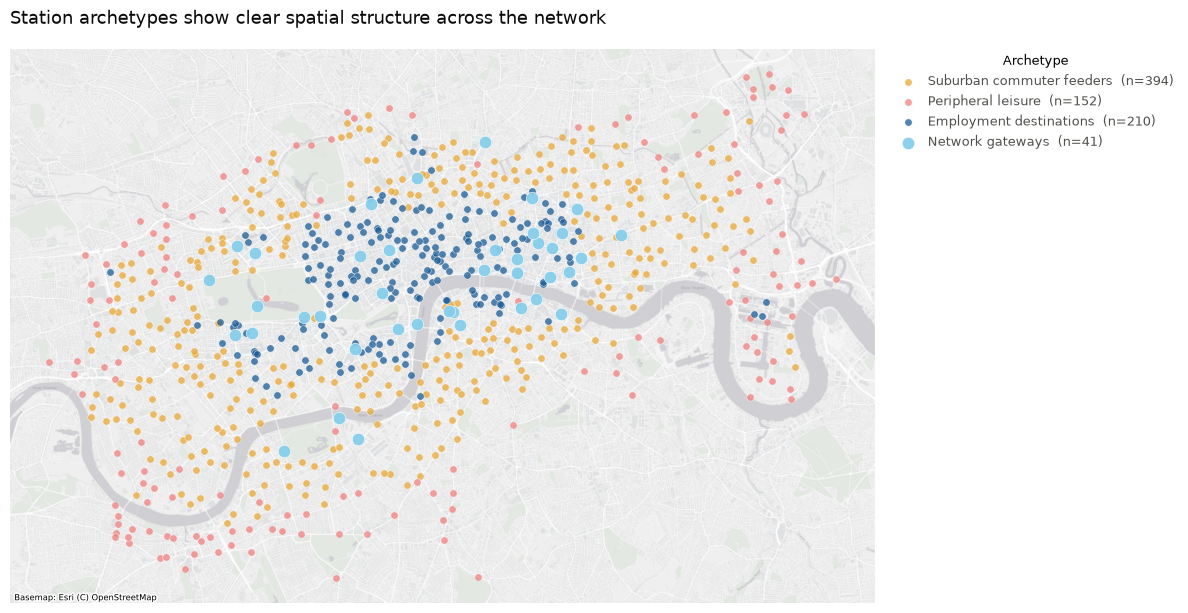

In [100]:
# Figure 22: Spatial cluster map
# Map the four archetypes geographically to show whether cluster membership
# follows spatial structure or cuts across it.

cluster_geo = feat[["cluster_name"]].join(
    key_coords[["ref_lat", "ref_lon"]], how="inner"
)

gdf_cl = gpd.GeoDataFrame(
    cluster_geo,
    geometry=gpd.points_from_xy(cluster_geo["ref_lon"], cluster_geo["ref_lat"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

DRAW_ORDER = [
    "Suburban commuter feeders",
    "Peripheral leisure",
    "Employment destinations",
    "Network gateways",
]

fig, ax = plt.subplots(figsize=(12, 10), facecolor=SURFACE)

for name in DRAW_ORDER:
    sub = gdf_cl[gdf_cl["cluster_name"] == name]
    size  = 80  if name == "Network gateways" else 28
    alpha = 0.95 if name == "Network gateways" else 0.75
    sub.plot(ax=ax, color=CLUSTER_COLOURS[name], markersize=size,
             alpha=alpha, edgecolor="white", linewidth=0.4,
             label=f"{name}  (n={len(sub)})", zorder=4)

pad = 0.05
xs = gdf_cl.geometry.x; ys = gdf_cl.geometry.y
dx = xs.max() - xs.min(); dy = ys.max() - ys.min()
ax.set_xlim(xs.min() - dx * pad, xs.max() + dx * pad)
ax.set_ylim(ys.min() - dy * pad, ys.max() + dy * pad)

try:
    cx.add_basemap(ax, crs=gdf_cl.crs, source=str(BASEMAP_WIDE),
                   attribution=BASEMAP_ATTRIBUTION,
                   attribution_size=6, zorder=1)
except Exception as exc:
    print(f"Basemap unavailable ({exc})")

leg = ax.legend(frameon=False, fontsize=9, labelcolor=INK_SOFT,
                loc="upper left", bbox_to_anchor=(1.02, 1.0),
                borderaxespad=0, handlelength=1.6,
                title="Archetype", title_fontsize=9)

ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)

ax.set_title("Station archetypes show clear spatial structure across the network",
             loc="left", fontsize=13, color=INK, pad=18)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig22_cluster_map.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

Spatial structure is strong: employment destinations (n=210, dark blue) concentrate in central London and the City; network gateways (n=41, sky blue) are distributed across the inner ring along major transport corridors; suburban commuter feeders (n=394, amber) dominate the mid-ring; peripheral leisure stations (n=152, light coral) ring the outer edge. Cluster membership is primarily determined by distance from the network centre.


Centroid values (unscaled, imbalance_rate as absolute):
                           total_starts  weekend_frac  dist_from_centre  km_gap  ebike_share  betweenness  imbalance_rate  commuter_frac
cluster                                                                                                                                 
Suburban commuter feeders    14258.9140        0.2480            4.1980  1.1090       0.1690       0.0020          0.0300         0.4270
Network gateways             41396.4150        0.2130            2.6640  0.6380       0.1880       0.0460          0.0330         0.4350
Employment destinations      16675.7570        0.1920            2.0600  0.6940       0.2040       0.0020          0.0290         0.4150
Peripheral leisure           10389.6640        0.2900            6.3570  1.5470       0.2050       0.0010          0.0050         0.4000


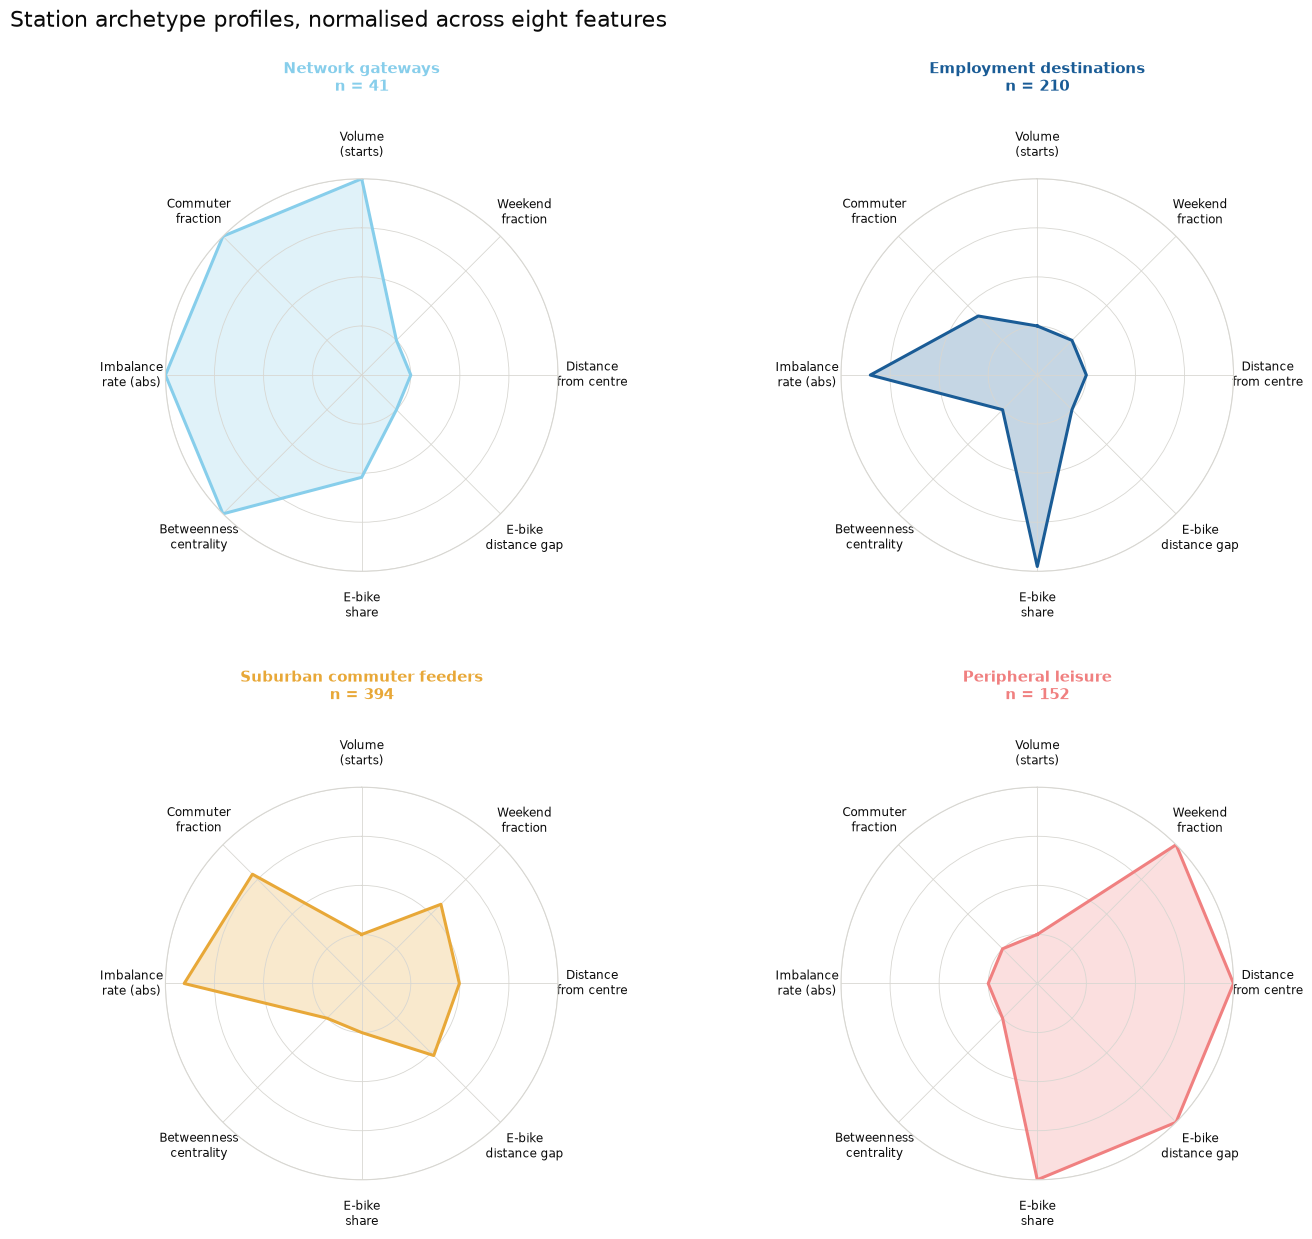

In [101]:
# Cluster profile radar chart
# Figure 23: 4-panel radar, one per archetype

RADAR_FEATURES = {
    "Volume\n(starts)" : "total_starts",
    "Weekend\nfraction" : "weekend_frac",
    "Distance\nfrom centre" : "dist_from_centre",
    "E-bike\ndistance gap" : "km_gap",
    "E-bike\nshare" : "ebike_share",
    "Betweenness\ncentrality" : "betweenness",
    "Imbalance\nrate (abs)" : "imbalance_rate",
    "Commuter\nfraction" : "commuter_frac",
}

labels = list(RADAR_FEATURES.keys())
cols = list(RADAR_FEATURES.values())
N = len(labels)

radar_vals = centres[cols].copy()
radar_vals["imbalance_rate"] = radar_vals["imbalance_rate"].abs()
radar_norm = (radar_vals - radar_vals.min()) / (radar_vals.max() - radar_vals.min())
radar_norm.index = [CLUSTER_NAMES[i] for i in radar_norm.index]
radar_plot = radar_norm.clip(lower=0.10)

print("\nCentroid values (unscaled, imbalance_rate as absolute):")
print(radar_vals.rename(index=CLUSTER_NAMES).round(3).to_string())

FLOOR = 0.25
radar_plot = radar_norm.clip(lower=FLOOR)

angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 13),
                         subplot_kw=dict(polar=True),
                         facecolor=SURFACE)
fig.subplots_adjust(hspace=0.55, wspace=0.65)

axes_flat = axes.flatten()

for ax, (name, colour) in zip(axes_flat, CLUSTER_COLOURS.items()):
    ax.set_facecolor(SURFACE)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    vals = radar_plot.loc[name, cols].tolist()
    vals += vals[:1]

    ax.plot(angles, vals, color=colour, lw=2.2)
    ax.fill(angles, vals, color=colour, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8.5, color=INK)
    ax.tick_params(axis="x", pad=14)

    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.grid(color=GRID, linewidth=0.6)
    ax.spines["polar"].set_color(GRID)

    n = int((feat["cluster_name"] == name).sum())
    ax.set_title(f"{name}\nn = {n}", fontsize=10.5, color=colour,
                 pad=28, fontweight="bold")

fig.suptitle("Station archetype profiles, normalised across eight features",
             fontsize=16, color=INK, x=0.02, ha="left", y=1.01)

plt.savefig(FIG_DIR / "fig23_radar_profiles.png", dpi=200,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()

Network gateways peak on volume (41k starts) and betweenness (0.046). Peripheral leisure stations peak on weekend fraction (0.29), distance from centre (6.4 km), and e-bike distance gap (1.55 km). Employment destinations sit innermost (2.1 km) with the lowest weekend fraction (0.19). Suburban commuter feeders occupy the middle ground across most axes.

## Conclusions

Five questions produced one consistent picture: 
1. A scheme whose behaviour is more orderly than its operational reputation suggests. The weekly rhythm has settled into a three-day commuting core, and the shortfall at either end of the week held steady rather than closing over the period observed. 
2. Most stations empty and refill within a single working day, leaving a rebalancing task confined to a handful of busy central sites, and no reading of fleet mix or gradient accounted for those exceptions. 
3. Importance and traffic proved to be separate properties. 
4. Electric cycles earned their place through reach at the margins rather than pace. 
5. Partitioning the stations without any locational input still reproduced the geography of the city.

## References

- GOV.UK, 2026, Bank holidays in England and Wales. Available at: https://www.gov.uk/bank-holidays.json (Accessed: 15 August 2026)
- Liu, J., Sun, L., Chen, W., Xiong, H., 2016, Rebalancing Bike Sharing Systems: A Multi-source Data Smart Optimization, in Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, pp. 1005-1014. https://doi.org/10.1145/2939672.2939776 
Open-Meteo, 2026, Elevation API. Available at: https://api.open-meteo.com/v1/elevation (Accessed: 15 August 2026)
- Transport for London (TfL), 2026a, Santander Cycles journey data. Available at: https://cycling.data.tfl.gov.uk (Accessed: 15 August 2026)
- Transport for London (TfL), 2026b, Unified API: BikePoint. Available at: https://api.tfl.gov.uk/BikePoint (Accessed: 15 August 2026)
- Waldner, F., Balke, G., Rech, F., Lellep, M., 2025, Data-driven insights into (E-)bike-sharing: mining a large-scale dataset on usage and urban characteristics: descriptive analysis and performance modelling, Transportation, 52 (6), 2433-2473. https://doi.org/10.1007/s11116-025-10661-2 
- Wood, J., Slingsby, A., Dykes, J., 2011, Visualizing the Dynamics of London’s Bicycle-Hire Scheme. Cartographica, 46 (4), 239-251. https://doi.org/10.3138/carto.46.4.239 
- Zhang, Y., Li, H., Ren, G., 2024, Lessons from thirteen years of the London cycle hire scheme: A review of evidence. Multimodal Transportation, 3(3), 100156. https://doi.org/10.1016/j.multra.2024.100156 


## Appendices

In [102]:
# pip freeze > requirements.txt

## Word Count

In [103]:
%%js

// Run this cell to update your word count.

function wordcount() {
    let wordCount = 0
    let extraCount = 0
    let mainBody = true

    let cells = Jupyter.notebook.get_cells()
    cells.forEach((cell) => {
        if (cell.cell_type == 'markdown') {
            let text = cell.get_text()
            // Stop counting as main body when get to References or Appendices.
            if (text.startsWith('## References') ||
                text.startsWith('## Appendices')) {
                mainBody = false
            }
            if (text.startsWith('## Word Count')) {
                text = ''
            }
            if (text) {
                let words = text.toLowerCase().match(/\b[a-z\d]+\b/g)
                if (words) {
                    let cellCount = words.length
                    if (mainBody) {
                        wordCount += cellCount
                    } else {
                        extraCount += cellCount
                    }
                }
            }
        }
    })
    return [wordCount, extraCount]
}

let wc = wordcount()
element.append(`Main word count: ${wc[0]} (References and appendices word count: ${wc[1]})`)

<IPython.core.display.Javascript object>